# Orbital Data Center: Levelized Cost of Compute (LCOC) Model — v3

**Project:** Feasibility study of whether passive radiative cooling and falling launch costs can make an Orbital Data Center (ODC) cost-competitive with a Terrestrial Data Center (TDC) for AI training workloads.

**Method:** First-principles sizing of PV array and radiator → mass and cost budget → LCOC via Nøland et al. (2024) Eq. 1.

**Model structure (v3, locked initial values):**
- **One** baseline ODC scenario in 2026 — all initial parameter values are now fixed at the spreadsheet values (no high/low scenarios on starting values).
- **One** terrestrial DC scenario for comparison (Nøland et al. baseline).
- **Uncertainty enters only through the learning rate** — three scenarios (Optimistic / Baseline / Pessimistic) that govern how fast each cost component declines (or how fast efficiencies grow). This produces the shaded uncertainty bands on time-series plots.

**Notebook outline:**
1. Constants and locked architectural assumptions
2. Baseline parameter tables (with sources)
3. Learning rate scenarios (lower bound / baseline / upper bound)
4. Physical sizing (PV, radiator, mass)
5. LCOC calculation at year 0 (2026)
6. Terrestrial DC baseline
7. Time projection 2026–2045 across learning rate scenarios
8. Visualizations (LCOC vs time, tornado, LCOC vs launch cost)
9. Summary

## 1. Constants and locked architectural assumptions

**Locked architecture (no variation across scenarios):**
- 100 MW compute payload, training workload, 100% utilization
- LEO at 2,000 km altitude — dawn-dusk, eclipse-free band; capacity factor CF = 0.9987 (residual ~11 h/yr lunar eclipse)
- 15-year ODC lifespan, 5-year IT refresh interval (refreshes at year 5 and year 10)
- PV and radiator are one-time launches at year 0 (no refresh)
- Single horizontal radiator beam, double-sided emission, co-located with vertical PV array at mid-height
- Triple-junction GaAs PV cells
- One fixed OPEX line = on-Earth operations labor ($3.75M/yr, identical for ODC and TDC); no structural mass overhead
- Cooling only the compute module (PV thermally isolated from radiator network)
- **Radiator operating temperature fixed at 70 °C (sensitivity 60–80 °C).** We treat `T_rad` as a *bounded design variable* rather than resolving the full junction-to-radiator thermal-resistance network (chip → TIM → cold plate → coolant → heat-pipe → panel → radiating surface). This follows Turyshev (2026), who operates the radiator at 350 K ≈ 77 °C and explicitly notes that `T_rad` is upper-bounded by the allowable junction temperature minus a thermal-resistance budget. A data-center accelerator junction of ~60–100 °C (Li 2024) carried through a realistic ~20 °C conduction+convection path drop places the radiating surface near 70 °C. The original 5 °C drop captured only the near-isothermal two-phase heat-pipe fluid ΔT, not the conduction/convection chain; fixing `T_rad` avoids introducing many poorly-constrained resistances for a subsystem worth ~0.1% of LCOC.
- **Thermally optimistic attitude:** the ODC orientation is chosen so the radiator panel is **edge-on to the Sun** (radiator surface normal ⟂ solar vector), giving direct solar projection onto the radiator ≈ 0 (Σcosθ ≈ 0). This is a best-case thermal assumption that maximizes net heat rejection per unit area.
- **PV cell temperature `T_PV` derived, not assumed:** a steady-state radiative energy balance on the cell (absorbed solar − extracted electrical power = two-face IR emission) gives `T_PV ≈ 31.1 °C` (see Section 2a). This replaces the legacy 80 °C placeholder.
- PV view factor `F_PV` computed self-consistently from geometry; both radiator faces see equal `F_PV` (mid-height symmetry)
- No radiator coating degradation (no UV / AO / dust accounting)
- No disposal / decommissioning costs
- No temperature gradient across the radiator (single `T_rad` everywhere)
- Data drop cost itself negligible

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
from dataclasses import dataclass, replace
from typing import Dict, List
from scipy.optimize import brentq
import warnings
warnings.filterwarnings('ignore')

# ----- Physical constants ----------------------------------------------------
# Basic scientific constants cited to the same primary sources as Turyshev (2026).
SIGMA        = 5.67e-8            # Stefan-Boltzmann [W m^-2 K^-4] (CODATA)
I_SUN        = 1361              # Solar constant / TSI [W m^-2] -- Kopp & Lean (2011),
                                 #   Geophys. Res. Lett. 38, L01706 (Turyshev 2026 ref [15])
T_EARTH_EFF  = 254.15           # Earth effective radiating temp [K] (-19 C) -- NASA Earth Fact Sheet
EARTH_ALBEDO = 0.306            # Earth Bond albedo -- NASA Earth Fact Sheet

# ----- Architecture constants ------------------------------------------------
Q_COMPUTE          = 100e6                       # 100 MW compute heat load [W]
LIFETIME_YR        = 15
REFRESH_INTERVAL   = 5                           # IT refresh every 5 yrs
HOURS_PER_YEAR     = 8760
SECONDS_PER_YEAR   = HOURS_PER_YEAR * 3600
ORBITAL_ALT_KM     = 2_000                       # LEO upper edge [km] -- Starship-class LEO; sits just above
                                                 #   the dawn-dusk eclipse-free floor (~1,600 km). (Claudio's orbit/CF work)
CAPACITY_FACTOR    = 0.9987                       # eclipse-free dawn-dusk orbit; residual ~11 h/yr lunar-eclipse loss
ANNUAL_LABOR_COST  = 3.75e6                       # on-Earth ops workforce [$/yr]: ~25 FTE x $150k loaded.
                                                 #   Headcount per Uptime Institute 2024 Global Data Center Survey &
                                                 #   Staffing Forecast (~20 FTE/12 MW, ~45/40 MW; FEWER per-MW for a
                                                 #   highly-automated >100 MW hyperscale campus). $150k = loaded comp
                                                 #   (salary+benefits+overhead) for skilled DC technicians/engineers.
                                                 #   Applied IDENTICALLY to ODC and TDC (both run from a ground NOC).

## 2. Baseline ODC parameters (with sources)

All initial values are locked at the 2026 spreadsheet values. The "Learning" column indicates whether the parameter evolves over time under a learning rate (see Section 3) or stays constant for the full 15-year mission. **Source filenames refer to the `Literature 2/` folder.**

### 2a. Learning parameters (evolve year-over-year)

Only four parameters carry a learning rate. Radiator areal cost and IT cost are now held **constant** (no learning) — see Section 3 for the rationale (commodity-aluminum radiator; AI hardware $/MW is flat-to-rising and the compute-cost improvement is captured through γ, not through $/MW).

| Parameter | Symbol | Value (2026) | Units | Learning | Source (file) |
|---|---|---|---|---|---|
| Compute Efficiency | γ | **6.0** | PFLOPS/kW | ✓ | `Noland2024_AIBaseloadPowerDemand_IEEEAccess.pdf` |
| Launch Cost | — | **1,500** | $/kg | ✓ | `Roberts2022_SpaceLaunchCostToLEO_CSIS.pdf` (Falcon Heavy / Starship class) |
| PV BOL Efficiency | η_BOL | **0.32** | — | ✓ | `NASA2025_SmallSpacecraftPower_TripleJunctionPV.pdf`; `Spectrolab_TripleJunctionGaAs_Datasheet.pdf` |
| PV Areal Cost | — | **33,000** | $/m² | ✓ | `Alibaba_GaInPGaAsGe_TripleJunctionCell_Pricing.pdf` (50% wholesale discount applied) |
| Radiator Areal Cost | — | **~230** | $/m² | ✗ (none) | Mass-grounded build-up (item 2): 5.0 kg/m² Al × ~$40/kg fab + ~$30/m² BaSO₄ coat. Sources: `ISNPS_AdvancedLightweightHeatRejectionRadiators.pdf`, `ACT_ThermallyEnhancedHoneycombPanels_Spacecraft.pdf`, `NASA_HoneycombPanelHeatPipe_Radiators.pdf`, `SpaceRadiator_SinglePhasePumpedLoop_ThermalPerformance.pdf`; LME Al ~$3.6/kg. Commodity Al → no Wright's-law tailwind. |
| IT Cost Density | — | **23,000,000** | $/MW | ✗ (none) | `NVIDIA_DGX_GB200_RackScaleSystems_UserGuide.pdf`; `Patel2025_H100vsGB200_TCO_SemiAnalysis.pdf` |

### 2b. Fixed parameters (constant over the mission)

| Parameter | Symbol | Value | Units | Source (file) |
|---|---|---|---|---|
| PV Derating | — | 0.85 | — | NREL PVWatts technical reference |
| PV Areal Density | — | 1.76 | kg/m² | `Spectrolab_TripleJunctionGaAs_Datasheet.pdf` |
| Radiator Areal Density | — | 5.5 | kg/m² | Item 2: 5.0 Al structure + 0.5 BaSO₄ coat. Areal-mass basis: `ISNPS_AdvancedLightweightHeatRejectionRadiators.pdf` (SOA ≤3 / conv. ~10 kg/m²), `ACT_ThermallyEnhancedHoneycombPanels_Spacecraft.pdf`, `NASA_HoneycombPanelHeatPipe_Radiators.pdf`, `SpaceRadiator_SinglePhasePumpedLoop_ThermalPerformance.pdf`, `Semenov2020_AxialGroovedHeatPipes_NASA.pdf` |
| IT Mass Density | — | 55,000 | kg/MW | `Kleyman2026_DataCenterDensityDilemma_AFCOM.pdf`; `Patrizio2025_HeavyCompute_AIWeightProblem_DCK.pdf` |
| Radiator spine length | L | √A_PV ≈ 520 | m | Item 3: square PV array → side = √A_PV; recomputed each year in `size_radiator`. H = A_PV/(2L) = L/2 |
| **PV Cell Temperature** | **T_PV** | **31.1 (derived)** | °C | **Radiative energy balance:** (α_PV − η_BOL)·I_⊙ = (ε_front + ε_back)·σ·T_PV⁴, with α_PV = 0.92, ε_front = ε_back = 0.84 (`Spectrolab_TripleJunctionGaAs_Datasheet.pdf`) |
| Radiator Solar Absorptance | α_solar | 0.05 | — | `Fan2025_RadiativeCoolingOuterSpace_AdvMater.pdf`; `LiRuan2021_UltrawhiteBaSO4Paints_RadiativeCooling.pdf` (BaSO₄ coating) |
| Radiator IR Emissivity / Absorptance | α_IR | 0.95 | — | `Fan2025_RadiativeCoolingOuterSpace_AdvMater.pdf`; `LiRuan2021_UltrawhiteBaSO4Paints_RadiativeCooling.pdf` |
| Discount Rate | r | 0.10 | — | `Noland2024_AIBaseloadPowerDemand_IEEEAccess.pdf` baseline |
| Earth View Factor (radiator → Earth) | F_⊕ | 0.1757 | — | Item 4: geometric VF at 2,000 km, F = 0.5·(1−√(1−(R_⊕/(R_⊕+h))²)) |
| **Radiator Temperature** | **T_rad** | **70** | °C | `Prior ODC Papers/turyshev2026.pdf` (350 K ≈ 77 °C); `Li2024_ChipScaleThermalManagement_ApplThermEng.pdf` (junction 60–100 °C). Sensitivity 60–80 °C. |
| PV IR Emissivity (front/back) | ε_PV | 0.84 | — | `Spectrolab_TripleJunctionGaAs_Datasheet.pdf` |
| Data Drop Mass | — | 1,000 | kg/drop | locked architecture |
| Data Drop Rate | — | 2 | drops/yr | locked architecture |
| ODC Lifespan | n | 15 | yrs | locked architecture |
| IT Compute Refresh Interval | — | 5 | yrs | locked architecture (refreshes at yr 5, 10) |
| ODC Compute Rating | — | 100 | MW | locked architecture |
| Solar Constant | I_⊙ | 1,361 | W/m² | Kopp & Lean (2011), GRL 38 L01706 — same TSI source as Turyshev (2026) |
| Orbital Altitude | — | 2,000 | km | Item 4: Starship-class LEO; just above the dawn-dusk eclipse-free floor (~1,600 km) |
| Capacity Factor | CF | 0.9987 | — | Item 4: eclipse-free dawn-dusk orbit; residual ~11 h/yr lunar-eclipse loss |
| Annual Labor (on-Earth ops) | — | 3.75 | $M/yr | ~25 FTE × $150k loaded. Headcount per **Uptime Institute 2024 Global Data Center Survey & Staffing Forecast** (~20 FTE/12 MW, ~45/40 MW; fewer per-MW at >100 MW hyperscale). Applied identically to ODC and TDC |
| Earth Albedo | α_⊕ | 0.306 | — | NASA Earth Fact Sheet (Bond albedo) |
| Earth Effective Rad Temperature | T_⊕ | −19 | °C (254.15 K) | NASA Earth Fact Sheet (blackbody temp 254 K) |

> **Context (not a model driver):** chip junction temperature `T_chip ≈ 85 °C` is retained only to motivate the radiator-temperature discussion for the manuscript. With `T_rad` fixed directly (above), `T_chip` no longer enters any calculation.

> **Note:** PV view factor `F_PV` is not a fixed input — it is computed self-consistently as F₁₂(h, w) by the `size_radiator` solver (Section 4), which sets the radiator width by minimizing area subject to the heat balance. Both radiator faces see equal `F_PV` because the beam sits at mid-height of the array.

### 2c. Other assumptions (qualitative)

- One OPEX line: on-Earth operations labor $3.75M/yr (item 5), applied identically to ODC and TDC
- No structural mass overhead
- Eclipse-free dawn-dusk LEO at 2,000 km; CF = 0.9987 (item 4)
- 100% power conditioning efficiency
- Double-sided radiator emission
- Triple-junction GaAs PV cells (NASA Space PV)
- No PV or radiator refresh — only IT refreshes
- Radiator operating temperature fixed at 70 °C as a bounded design variable (junction-to-radiator resistance network not resolved); sensitivity 60–80 °C
- Thermally optimistic attitude: radiator edge-on to the Sun (solar projection ≈ 0 at design point; Σcosθ ≈ 0)
- PV cell temperature derived from a radiative energy balance (31.1 °C), not assumed
- Cooling only compute module (PV thermally isolated)
- 100% utilization, no downtime
- Single TDC scenario (no optimistic / pessimistic TDC variants)
- No radiator coating degradation (no UV exposure, AO erosion, or space-dust accounting)
- No disposal / decommissioning of ODC or launch vehicles
- No temperature gradient across the radiator (single T_rad)
- Data drop cost negligible (only the launch cost of the return mass counts)

In [2]:
@dataclass
class Scenario:
    name: str
    # Compute
    gamma_PFLOPS_per_kW: float
    # Radiator
    eps_IR: float; alpha_solar_rad: float
    F_earth: float
    T_rad_C: float; T_chip_C: float
    rad_areal_mass: float; rad_areal_cost: float
    L_rad: float          # radiator/PV spine length [m]
    # PV
    pv_eff_BOL: float; pv_derating: float
    T_PV_C: float; eps_PV_back: float
    pv_areal_mass: float; pv_areal_cost: float
    # Compute payload
    it_mass_density: float; it_cost_per_MW: float
    # Launch & data
    launch_cost_per_kg: float
    data_mass_per_drop: float; data_drops_per_year: float; data_fixed_cost: float
    # Financial
    discount_rate: float


# -----------------------------------------------------------------------------
# PV cell steady-state temperature from a radiative energy balance
# -----------------------------------------------------------------------------
# In space the cell reaches equilibrium when absorbed solar power MINUS the
# electrical power carried away by the array equals the infrared power radiated
# from BOTH faces:
#     (alpha_PV - eta_BOL) * I_sun  =  (eps_front + eps_back) * SIGMA * T_PV^4
# Spectrolab triple-junction datasheet: solar absorptance <= 0.92, emittance >= 0.84
# (front and back). Solving for T_PV gives ~31.1 C at BOL efficiency.
ALPHA_SOLAR_PV = 0.92      # solar absorptance  (Spectrolab TJ datasheet)
EPS_PV_FRONT   = 0.84      # front-face IR emittance (datasheet)
EPS_PV_BACK    = 0.84      # back-face  IR emittance (datasheet)
_PV_ETA_BOL_0  = 0.32      # BOL efficiency used in the balance
T_PV_EQUIL_C = (((ALPHA_SOLAR_PV - _PV_ETA_BOL_0) * I_SUN
                 / ((EPS_PV_FRONT + EPS_PV_BACK) * SIGMA)) ** 0.25) - 273.15
print(f'Derived PV cell temperature (radiative balance): T_PV = {T_PV_EQUIL_C:.1f} C')

# -----------------------------------------------------------------------------
# Radiator physical cost/mass build-up (item 2: thickness-grounded, not a flat $/m^2)
# -----------------------------------------------------------------------------
# Thin ALUMINUM panel (facesheets + honeycomb core + embedded axially-grooved Al
# heat pipes) + thin BaSO4 radiative-cooling coating. Thermal sizing stays 2-D
# (isothermal thin sheet); MASS and COST are built from areal mass x $/kg.
# Areal-mass basis (Literature 2/): ISNPS_AdvancedLightweightHeatRejectionRadiators
#   (SOA <=3, conventional ~10 kg/m^2), ACT_ThermallyEnhancedHoneycombPanels_Spacecraft,
#   NASA_HoneycombPanelHeatPipe_Radiators, SpaceRadiator_SinglePhasePumpedLoop_ThermalPerformance,
#   Semenov2020_AxialGroovedHeatPipes_NASA -> midpoint ~5.0 kg/m^2.
# Coating: LiRuan2021_UltrawhiteBaSO4Paints (eps~0.95, ~0.2 mm), Fan2025_RadiativeCoolingOuterSpace.
# Al $/kg: LME ~$3.6/kg x ~10 (rolling/extrusion/honeycomb bonding/heat-pipe fab/qual).
RAD_AL_AREAL_MASS   = 5.0    # kg/m^2  Al structure (facesheets+honeycomb+heat pipes)
RAD_COAT_AREAL_MASS = 0.5    # kg/m^2  BaSO4 paint coat (~0.2 mm applied)
RAD_AREAL_MASS      = RAD_AL_AREAL_MASS + RAD_COAT_AREAL_MASS          # 5.5 kg/m^2
C_AL_FAB_PER_KG     = 40.0   # $/kg    fabricated/qualified Al panel (LME ~$3.6/kg x ~10 fab/qual)
COATING_COST_PER_M2 = 30.0   # $/m^2   high-performance radiative-cooling paint, applied
RAD_AREAL_COST      = RAD_AL_AREAL_MASS * C_AL_FAB_PER_KG + COATING_COST_PER_M2   # ~$230/m^2

# -----------------------------------------------------------------------------
# BASELINE (2026 initial values, locked per spreadsheet)
# -----------------------------------------------------------------------------
BASELINE = Scenario(
    name                = 'Baseline 2026',
    # ---- Learning parameters --------------------------------------------------
    gamma_PFLOPS_per_kW = 6.0,            # PFLOPS/kW   (Noland 2024)
    launch_cost_per_kg  = 1_500.0,        # $/kg        (Roberts 2022 / CSIS)
    pv_eff_BOL          = 0.32,           # -           (NASA Space PV / Spectrolab)
    pv_areal_cost       = 33_000.0,       # $/m^2       (Alibaba @ 50% wholesale)
    # ---- No-learning cost parameters (held constant; see Section 3) -----------
    rad_areal_cost      = RAD_AREAL_COST, # $/m^2       (item 2: ~$230, commodity Al)
    it_cost_per_MW      = 23e6,           # $/MW        (NVIDIA GB200 + SemiAnalysis TCO)
    # ---- Fixed parameters -----------------------------------------------------
    pv_derating         = 0.85,           # NREL PVWatts
    pv_areal_mass       = 1.76,           # kg/m^2      (Spectrolab TJ datasheet)
    rad_areal_mass      = RAD_AREAL_MASS, # kg/m^2      (item 2: 5.0 Al + 0.5 coat = 5.5)
    it_mass_density     = 55_000.0,       # kg/MW       (AFCOM density + Patrizio weight)
    T_PV_C              = T_PV_EQUIL_C,   # C  DERIVED from radiative balance (~31.1)
    alpha_solar_rad     = 0.05,           # Fan et al. 2025
    eps_IR              = 0.95,           # Fan et al. 2025
    discount_rate       = 0.10,           # Noland 2024
    F_earth             = 0.1757,         # item 4: geometric VF at 2,000 km
    T_rad_C             = 70.0,           # C  bounded design variable (Turyshev 350 K; Li 2024)
    T_chip_C            = 85.0,           # C  CONTEXT ONLY (motivates T_rad; not a model driver)
    eps_PV_back         = EPS_PV_BACK,    # 0.84  (Spectrolab TJ datasheet)
    L_rad               = float(np.sqrt(Q_COMPUTE/(0.32*0.85*I_SUN))),  # item 3: = sqrt(A_PV) ~520 m; recomputed in size_radiator
    data_mass_per_drop  = 1_000.0,        # kg/drop
    data_drops_per_year = 2.0,            # drops/yr
    data_fixed_cost     = 0.0,            # "data drop cost negligible"
)

print(f'Baseline: gamma = {BASELINE.gamma_PFLOPS_per_kW} PFLOPS/kW,'
      f' launch = ${BASELINE.launch_cost_per_kg:,.0f}/kg,'
      f' T_PV = {BASELINE.T_PV_C:.1f} C,'
      f' T_rad = {BASELINE.T_rad_C:.0f} C,'
      f' L_rad = {BASELINE.L_rad:.0f} m')

Derived PV cell temperature (radiative balance): T_PV = 31.1 C
Baseline: gamma = 6.0 PFLOPS/kW, launch = $1,500/kg, T_PV = 31.1 C, T_rad = 70 C, L_rad = 520 m


## 3. Learning rate scenarios

Future-state uncertainty enters through learning rates applied to the four learning parameters in Section 2a. The shaded band on time-series plots spans **Pessimistic ↔ Optimistic**; the central line uses **Baseline**.

### Time-based rates rooted in experience curves

We project **in calendar time (%/yr)** because the model marches year-by-year, but every cost rate is **rooted in a Wright's-law experience curve (% cost reduction per doubling of cumulative capacity)** combined with a **stated doubling cadence** `τ` (years per doubling). The conversion is:

$$ r_{\text{yr}} = 1 - (1 - \mathrm{LR}_{\text{doubling}})^{1/\tau} $$

This keeps the time-series transparent while grounding each number in the production-driven mechanism the literature reports. (Section 8d uses the Wright's-law form directly to tie ODC cost to market-share-driven cumulative deployment.)

### Learning-rate table

| Parameter | Optimistic | **Baseline** | Pessimistic | Experience-curve root & source |
|---|---|---|---|---|
| Launch cost ($/kg) | **−20%/yr** | **−12%/yr** | **−4%/yr** | LR ≈ 15%/doubling (conservative 85% aerospace progress ratio; HBR satellite-launch ≈20%/doubling). Baseline −12%/yr ⇔ ~1.3 yr/doubling (rapid Starship ramp); pessimistic ⇔ ~4 yr/doubling. Anchored on CSIS `Roberts2022…` for the $/kg level. *(The "35–50%/doubling" seen on forums is the Li-ion battery rate, not launch — not used.)* |
| PV areal cost ($/m²) | −10%/yr | −6%/yr | −2%/yr | LR = 20%/doubling — **Swanson's law** (Our World in Data, 4 decades). Baseline −6%/yr ⇔ ~3.6 yr/doubling for the smaller, less-mature space-grade III-V market. |
| Compute efficiency γ | **+22%/yr** | **+15%/yr** | **+7%/yr** | Epoch AI: leading ML-hardware **energy efficiency +40%/yr** (doubling ≈2 yr). We deliberately scale **below** the historical rate — baseline +15%/yr (doubling ≈5 yr) — assuming the trend decelerates toward transistor/thermodynamic limits over a 15-yr horizon. Applies to **both** ODC and TDC (same chips). |
| PV efficiency (abs. pp) | +0.5 pp/yr | +0.3 pp/yr | +0.1 pp/yr | Commercial space 3J ≈30–32% AM0; lab record 34.2% AM0 (Joule 2022). **Capped at 35% AM0** (practical 3J ceiling), not the terrestrial/theoretical ~40%. |
| **Radiator areal cost** | **0%** | **0%** | **0%** | **No learning.** The panel is fabricated **aluminum** (a mature commodity tracking the LME, not an experience curve) plus commodity BaSO₄ paint. Immaterial anyway (~0.1% of LCOC). |
| **IT cost ($/MW)** | **0%** | **0%** | **0%** | **No learning.** AI-hardware capex **per MW of capacity** has been flat-to-**rising** (denser racks, mandatory liquid cooling, NVIDIA pricing power; AI rack ≈$3.9M in 2025). The cost-per-FLOP improvement is delivered through **γ**, so giving γ *and* $/MW separate declines would double-count. Holding $/MW flat is the strong, defensible choice. |
| **IT mass density (kg/MW)** | fixed | fixed | fixed | **No learning.** Chip/IT R&D targets **compute efficiency, not mass**. (Conversely, were ODCs to scale rapidly, a launch-mass incentive could push kg/MW down — noted as upside not modeled.) |
| Terrestrial DC CAPEX ($/kW) | −4%/yr | −2%/yr | −0.5%/yr | Mature tech, slow incremental gains. |
| Electricity price ($/MWh) | 0% real | 0% real | 0% real | Flat in real terms. |

**Key insight:** γ improvement applies to **both** ODC and TDC (same chips, same efficiency curve), shifting both curves down in parallel. The **gap** between ODC and TDC is driven primarily by **launch-cost decline** (helping ODC) vs **terrestrial-CAPEX decline** (helping TDC). With IT $/MW held flat, the ODC's cost advantage over time rests squarely on launch and PV learning.

In [3]:
@dataclass
class LearningRates:
    name: str
    launch:       float   # annual decline (fractional, e.g. 0.12 = -12%/yr)
    pv_cost:      float
    rad_cost:     float   # held at 0.0 -- radiator areal cost has NO learning
    it_cost:      float   # held at 0.0 -- IT $/MW has NO learning (see Section 3)
    gamma_growth: float   # annual growth (fractional)
    pv_eff_pp:    float   # additive percentage points / yr
    terr_capex:   float
    elec_price:   float = 0.0


# rad_cost and it_cost are 0.0 in every scenario: radiator areal cost (commodity
# aluminum) and IT $/MW (flat-to-rising AI hardware capex) carry no learning.
LR_OPTIMISTIC = LearningRates(
    name='Optimistic',
    launch=0.20, pv_cost=0.10, rad_cost=0.0, it_cost=0.0,
    gamma_growth=0.22, pv_eff_pp=0.005, terr_capex=0.04,
)
LR_BASELINE = LearningRates(
    name='Baseline',
    launch=0.12, pv_cost=0.06, rad_cost=0.0, it_cost=0.0,
    gamma_growth=0.15, pv_eff_pp=0.003, terr_capex=0.02,
)
LR_PESSIMISTIC = LearningRates(
    name='Pessimistic',
    launch=0.04, pv_cost=0.02, rad_cost=0.0, it_cost=0.0,
    gamma_growth=0.07, pv_eff_pp=0.001, terr_capex=0.005,
)
LR_SCENARIOS = [LR_OPTIMISTIC, LR_BASELINE, LR_PESSIMISTIC]

## 4. Physical sizing

PV area sized to deliver `Q_COMPUTE` after BOL efficiency and derating losses (single-sided, normal incidence assumed):

$$A_{\mathrm{PV}} = \frac{Q_{\mathrm{compute}}}{\eta_{\mathrm{BOL}} \cdot \eta_{\mathrm{derate}} \cdot I_{\odot}}$$

**Radiator** is a single horizontal $W \times L$ beam (double-sided emission), co-located with the vertical PV array at mid-height. The beam sits at the midpoint of the array, so both faces see the **same** PV view factor — the top face sees the upper half of the array and the bottom face sees the lower half:

$$F_{\mathrm{PV}} = F_{12}(h,\,w), \quad h = H/L,\quad w = W/L, \quad H = \frac{A_{\mathrm{PV}}}{2L}$$

Net heat rejection per unit one-face area, summed over both faces (edge-on sun design point, $\Sigma\cos\theta \approx 0$):

$$q_{\mathrm{net}}(w) = 2\varepsilon_r \sigma T_r^4 \;-\; 2\varepsilon_r\varepsilon_{\mathrm{PV}}\,F_{12}(h,w)\,\sigma T_{\mathrm{PV}}^4 \;-\; \varepsilon_r \sigma T_\oplus^4 F_\oplus \;-\; \alpha_s\,a_\oplus\,I_\odot F_\oplus$$

Because $F_{12}$ depends on $w$ and $A = wL^2$, the area is **implicit**. The spine length is set by the PV footprint — a *square* PV array of area $A_{\mathrm{PV}}$ has side $L=\sqrt{A_{\mathrm{PV}}}$ (item 3), giving $h=H/L=0.5$; `brentq` solves for $w^*$:

$$f(w) = q_{\mathrm{net}}(w)\cdot w L^2 - Q_{\mathrm{chip}} = 0 \implies A_{\mathrm{rad}} = w^* L^2$$

The residual is monotone increasing in $w$ (larger radiator sees less PV, more deep space), guaranteeing a unique root. $F_{12}$ is the Howell/Siegel adjacent perpendicular-rectangle view factor (touching at a shared edge $L$).

(Notation: $\varepsilon_r = \alpha_{\mathrm{IR}}$ is the radiator IR emissivity/absorptance per Kirchhoff's law; used consistently with Fan et al. 2025.)

In [4]:
def F_perp_adjacent(h, w):
    """View factor: horizontal W×L plate → perpendicular L×H plate sharing edge L.
    h = H/L, w = W/L. Howell/Siegel adjacent perpendicular rectangles.
    Verified: F_perp_adjacent(1, 1) ≈ 0.20004."""
    H2W2 = h**2 + w**2
    a = ((1 + h**2) * (1 + w**2)) / (1 + H2W2)
    b = (w**2 * (1 + H2W2)) / ((1 + w**2) * H2W2)
    c = (h**2 * (1 + H2W2)) / ((1 + h**2) * H2W2)
    term = (h * np.arctan(1/h) + w * np.arctan(1/w)
            - np.sqrt(H2W2) * np.arctan(1/np.sqrt(H2W2))
            + 0.25 * np.log(a * b**(w**2) * c**(h**2)))
    return term / (np.pi * w)


def size_pv_array(s: Scenario) -> float:
    return Q_COMPUTE / (s.pv_eff_BOL * s.pv_derating * I_SUN)


def size_radiator(s: Scenario, verbose: bool = False) -> float:
    """Self-consistent radiator area for single horizontal beam (double-sided emission).
    Beam sits at mid-height of vertical PV array; both faces see equal F_PV = F_12(h, w).
    L = s.L_rad is fixed; brentq solves for width ratio w = W/L."""
    T_r  = s.T_rad_C + 273.15
    T_PV = s.T_PV_C  + 273.15
    A_PV = size_pv_array(s)
    L    = np.sqrt(A_PV)          # item 3: square PV array -> spine = side length = sqrt(A_PV)
    H    = A_PV / (2 * L)          # PV half-height (array extends H above and below spine) = L/2
    h    = H / L                   # dimensionless aspect ratio (= 0.5 for a square array)

    def q_net(w):
        """Net heat rejected per m² of one-face area, both faces summed (W/m²)."""
        F_pv = F_perp_adjacent(h, w)
        # gross 2-sided emission − PV re-absorbed on both faces − Earth IR − Earth albedo
        q_ir = (2*s.eps_IR*SIGMA*T_r**4
                - 2*s.eps_IR*s.eps_PV_back*F_pv*SIGMA*T_PV**4
                - s.eps_IR*SIGMA*T_EARTH_EFF**4*s.F_earth)
        q_alb = s.alpha_solar_rad * EARTH_ALBEDO * I_SUN * s.F_earth
        return q_ir - q_alb

    resid = lambda w: q_net(w) * (w * L**2) - Q_COMPUTE
    w_star = brentq(resid, 1e-4, 1e4)
    A_rad  = w_star * L**2

    if verbose:
        q    = q_net(w_star)
        F_pv = F_perp_adjacent(h, w_star)
        P_emit   = 2*s.eps_IR*SIGMA*T_r**4
        P_PV_abs = 2*s.eps_IR*s.eps_PV_back*F_pv*SIGMA*T_PV**4
        P_earth  = s.eps_IR*SIGMA*T_EARTH_EFF**4*s.F_earth
        P_alb    = s.alpha_solar_rad * EARTH_ALBEDO * I_SUN * s.F_earth
        print(f'  Geometry: L={L:.0f} m, H={H:.1f} m, h={h:.3f}, W={w_star*L:.1f} m (w={w_star:.4f})')
        print(f'  F_PV (per face, both equal): {F_pv:.4f}')
        print(f'  Heat balance (W/m² of one-face area):')
        print(f'    Gross emission (2-sided): +{P_emit:>7.1f}')
        print(f'    PV re-absorbed (2 faces): -{P_PV_abs:>7.1f}')
        print(f'    Earth IR:                 -{P_earth:>7.1f}')
        print(f'    Earth albedo:             -{P_alb:>7.2f}')
        print(f'    Net cooling:              +{q:>7.1f}')
    return A_rad


def mass_budget(s: Scenario) -> Dict[str, float]:
    A_PV  = size_pv_array(s)
    A_rad = size_radiator(s)
    m_PV  = A_PV  * s.pv_areal_mass
    m_rad = A_rad * s.rad_areal_mass
    m_IT  = (Q_COMPUTE / 1e6) * s.it_mass_density
    return {
        'A_PV':     A_PV,
        'A_rad':    A_rad,
        'PV':       m_PV,
        'Radiator': m_rad,
        'IT':       m_IT,
        'Total':    m_PV + m_rad + m_IT,
    }

print(f'Verification: F_perp_adjacent(1, 1) = {F_perp_adjacent(1, 1):.5f}  (expect 0.20004)')
print()
print('Physical sizing (2026 baseline):')
A_PV = size_pv_array(BASELINE)
print(f'  PV array:  {A_PV:>10,.0f} m^2  ({A_PV/5350:.2f} football fields)')
A_rad = size_radiator(BASELINE, verbose=True)
print(f'  Radiator:  {A_rad:>10,.0f} m^2  ({A_rad/5350:.2f} football fields)')

mb = mass_budget(BASELINE)
print('\nMass budget (tonnes):')
for k in ['PV', 'Radiator', 'IT', 'Total']:
    print(f'  {k:10s} {mb[k]/1000:>9,.1f} t')

Verification: F_perp_adjacent(1, 1) = 0.20004  (expect 0.20004)

Physical sizing (2026 baseline):
  PV array:     270,130 m^2  (50.49 football fields)
  Geometry: L=520 m, H=259.9 m, h=0.500, W=158.9 m (w=0.3057)
  F_PV (per face, both equal): 0.3088
  Heat balance (W/m² of one-face area):
    Gross emission (2-sided): + 1493.7
    PV re-absorbed (2 faces): -  239.5
    Earth IR:                 -   39.5
    Earth albedo:             -   3.66
    Net cooling:              + 1211.0
  Radiator:      82,573 m^2  (15.43 football fields)

Mass budget (tonnes):
  PV             475.4 t
  Radiator       454.2 t
  IT           5,500.0 t
  Total        6,429.6 t


## 5. LCOC calculation

Following Nøland et al. (2024) Eq. 1. Electricity on-orbit is free ($\alpha p k t = 0$); OPEX is reduced to a single fixed labor line (item 5). Annual compute is scaled by the orbital capacity factor CF = 0.9987 (item 4):

$$ \text{LCOC} = \frac{\sum_i \text{cost}_i / (1+r)^i}{\sum_i \gamma k t / (1+r)^i} $$

Cost streams:
- **Hardware**: PV + radiator + IT at year 0; IT refreshes at years 5 and 10.
- **Launch**: full system mass at year 0; IT-only mass at refresh years.
- **Data**: per-drop return-mass launch cost only (drop fixed cost is taken as negligible per the spreadsheet assumption).
- **Labor**: fixed on-Earth operations workforce ($3.75M/yr; item 5), applied identically to the ODC and the terrestrial baseline so the comparison is apples-to-apples.

In [5]:
def annual_eflop(s: Scenario, k_load: float = 1.0) -> float:
    """Annual compute output [EFLOP/year]."""
    return (Q_COMPUTE / 1000) * s.gamma_PFLOPS_per_kW / 1000 * SECONDS_PER_YEAR * k_load

def build_cash_flows(s: Scenario) -> Dict[str, np.ndarray]:
    mb = mass_budget(s)
    cost_PV  = mb['A_PV']  * s.pv_areal_cost
    cost_rad = mb['A_rad'] * s.rad_areal_cost
    cost_IT  = (Q_COMPUTE / 1e6) * s.it_cost_per_MW
    launch_year0   = mb['Total'] * s.launch_cost_per_kg
    launch_refresh = mb['IT']    * s.launch_cost_per_kg
    hardware = np.zeros(LIFETIME_YR)
    launch   = np.zeros(LIFETIME_YR)
    data     = np.zeros(LIFETIME_YR)
    hardware[0] = cost_PV + cost_rad + cost_IT
    launch[0]   = launch_year0
    for ry in [5, 10]:
        hardware[ry] += cost_IT
        launch[ry]   += launch_refresh
    cost_per_drop = s.data_fixed_cost + s.data_mass_per_drop * s.launch_cost_per_kg
    data[:] = cost_per_drop * s.data_drops_per_year
    labor = np.full(LIFETIME_YR, ANNUAL_LABOR_COST)   # item 5: fixed on-Earth ops workforce
    return {'hardware': hardware, 'launch': launch, 'data': data, 'labor': labor,
            'total': hardware + launch + data + labor}

def calculate_lcoc(s: Scenario) -> Dict[str, float]:
    cf = build_cash_flows(s)
    years = np.arange(LIFETIME_YR)
    annual_compute = np.full(LIFETIME_YR, annual_eflop(s, k_load=CAPACITY_FACTOR))  # item 4: eclipse CF
    discount = 1.0 / (1 + s.discount_rate)**years
    npv_cost    = (cf['total']     * discount).sum()
    npv_compute = (annual_compute * discount).sum()
    lcoc = npv_cost / npv_compute
    breakdown = {
        'Hardware': (cf['hardware'] * discount).sum() / npv_compute,
        'Launch':   (cf['launch']   * discount).sum() / npv_compute,
        'Data':     (cf['data']     * discount).sum() / npv_compute,
        'Labor':    (cf['labor']    * discount).sum() / npv_compute,
    }
    return {'lcoc': lcoc, 'breakdown': breakdown, 'npv_cost': npv_cost}

baseline_result = calculate_lcoc(BASELINE)
print(f'2026 baseline ODC LCOC:  ${baseline_result["lcoc"]:.4f}/EFLOP')
print(f'NPV of total cost:       ${baseline_result["npv_cost"]/1e9:.2f}B')
print(f'\nCost breakdown:')
for k, v in baseline_result['breakdown'].items():
    print(f'  {k:10s} ${v:.4f}/EFLOP   ({v/baseline_result["lcoc"]*100:5.1f}%)')

2026 baseline ODC LCOC:  $0.1996/EFLOP
NPV of total cost:       $31.55B

Cost breakdown:
  Hardware   $0.0857/EFLOP   ( 42.9%)
  Launch     $0.1135/EFLOP   ( 56.9%)
  Data       $0.0002/EFLOP   (  0.1%)
  Labor      $0.0002/EFLOP   (  0.1%)


## 6. Terrestrial DC baseline (Nøland et al. methodology)

Using their Table 5 baseline: $c = \$10{,}000$/kW, $d = 10\%$ (annual OPEX as fraction of CAPEX), $\alpha = 1.12$ (PUE), $p = \$150$/MWh, $r = 10\%$, $n = 15$ years, $k = 1$.

Computed at the **same γ as the ODC baseline** for apples-to-apples comparison. The same fixed on-Earth labor cost (item 5, $37.5/kW/yr = $3.75M/yr) is now added on top of the paper's 10% O&M; the labor-free verification case is retained to reproduce the paper's $1.16 baseline.

In [6]:
def terrestrial_lcoc(gamma_PFLOPS_per_kW: float,
                     c_per_kW: float  = 10_000,
                     d_frac: float    = 0.10,
                     alpha_PUE: float = 1.12,
                     p_per_MWh: float = 150,
                     r_wacc: float    = 0.10,
                     n_years: int     = 15,
                     k_load: float    = 1.0,
                     labor_per_kW_yr: float = ANNUAL_LABOR_COST / (Q_COMPUTE / 1e3)) -> float:
    """Noland et al. 2024 Eq. 1 - terrestrial LCOC in $/EFLOP.
    item 5: adds the SAME fixed labor cost used for the ODC, on a per-kW basis
    ($37.5/kW/yr = $3.75M/yr over a 100 MW facility). Pass labor_per_kW_yr=0 to
    reproduce the paper's labor-free baseline."""
    annual_elec    = alpha_PUE * (p_per_MWh / 1000) * k_load * HOURS_PER_YEAR
    annual_opex    = d_frac * c_per_kW
    annual_labor   = labor_per_kW_yr                      # fixed, not load-scaled
    annual_compute = gamma_PFLOPS_per_kW * k_load * SECONDS_PER_YEAR
    df = np.array([1/(1+r_wacc)**i for i in range(n_years)])
    npv_costs    = c_per_kW + ((annual_elec + annual_opex + annual_labor) * df).sum()
    npv_compute  = (annual_compute * df).sum()
    return (npv_costs / npv_compute) * 1000   # $/PFLOP -> $/EFLOP

# Sanity check vs. paper-reported value at gamma=0.1 (labor-free, to match the paper)
verify = terrestrial_lcoc(0.1, labor_per_kW_yr=0)
print(f'Verification @ gamma=0.1 (no labor): ${verify:.3f}/EFLOP   (Noland 2024 paper baseline: $1.16)')

tdc_baseline = terrestrial_lcoc(BASELINE.gamma_PFLOPS_per_kW)
print(f'\nTDC @ gamma={BASELINE.gamma_PFLOPS_per_kW} PFLOPS/kW: ${tdc_baseline:.4f}/EFLOP')
print(f'ODC / TDC ratio (2026): {baseline_result["lcoc"]/tdc_baseline:.2f}x')

Verification @ gamma=0.1 (no labor): $1.163/EFLOP   (Noland 2024 paper baseline: $1.16)

TDC @ gamma=6.0 PFLOPS/kW: $0.0196/EFLOP
ODC / TDC ratio (2026): 10.19x


## 7. Time projection 2026–2045

Apply each learning rate scenario to the baseline year over year. Generates three trajectories (Optimistic / Baseline / Pessimistic learning rates) for both ODC and TDC.

In [7]:
def evolve_scenario(s_base: Scenario, year_offset: int, lr: LearningRates) -> Scenario:
    """Return s_base evolved year_offset years into the future under learning rates lr.
    NOTE: radiator areal cost and IT $/MW carry NO learning (held constant); IT mass
    density is fixed. PV BOL efficiency is capped at 35% AM0 (practical 3J ceiling)."""
    return replace(s_base,
        gamma_PFLOPS_per_kW = s_base.gamma_PFLOPS_per_kW * (1 + lr.gamma_growth)**year_offset,
        launch_cost_per_kg  = s_base.launch_cost_per_kg  * (1 - lr.launch)**year_offset,
        pv_areal_cost       = s_base.pv_areal_cost       * (1 - lr.pv_cost)**year_offset,
        pv_eff_BOL          = min(0.35, s_base.pv_eff_BOL + lr.pv_eff_pp * year_offset),
        # rad_areal_cost, it_cost_per_MW, it_mass_density: intentionally unchanged
    )

def terrestrial_evolved(gamma_baseline: float, year_offset: int, lr: LearningRates) -> float:
    gamma_t = gamma_baseline * (1 + lr.gamma_growth)**year_offset
    capex_t = 10_000 * (1 - lr.terr_capex)**year_offset
    return terrestrial_lcoc(gamma_t, c_per_kW=capex_t)

# Project each LR scenario forward
START_YEAR, END_YEAR = 2026, 2045
years_calendar = np.arange(START_YEAR, END_YEAR + 1)
year_offsets   = years_calendar - START_YEAR

odc_by_lr: Dict[str, np.ndarray] = {}
tdc_by_lr: Dict[str, np.ndarray] = {}

for lr in LR_SCENARIOS:
    odc_vals, tdc_vals = [], []
    for yo in year_offsets:
        ev = evolve_scenario(BASELINE, yo, lr)
        odc_vals.append(calculate_lcoc(ev)['lcoc'])
        tdc_vals.append(terrestrial_evolved(BASELINE.gamma_PFLOPS_per_kW, yo, lr))
    odc_by_lr[lr.name] = np.array(odc_vals)
    tdc_by_lr[lr.name] = np.array(tdc_vals)

# Convenience aliases
odc_nom = odc_by_lr['Baseline']
odc_hi  = odc_by_lr['Optimistic']     # lower LCOC = cheaper
odc_lo  = odc_by_lr['Pessimistic']    # higher LCOC = more expensive
tdc_nom = tdc_by_lr['Baseline']
tdc_hi  = tdc_by_lr['Optimistic']
tdc_lo  = tdc_by_lr['Pessimistic']

print(f'{"Year":>6s}  {"ODC Base":>10s}  {"ODC Opt":>10s}  {"ODC Pes":>10s}  '
      f'{"TDC Base":>10s}  {"ratio":>8s}')
for label, idx in [('2026', 0), ('2030', 4), ('2035', 9), ('2040', 14), ('2045', 19)]:
    print(f'{label:>6s}  ${odc_nom[idx]:>9.4f}  ${odc_hi[idx]:>9.4f}  '
          f'${odc_lo[idx]:>9.4f}  ${tdc_nom[idx]:>9.4f}  '
          f'{odc_nom[idx]/tdc_nom[idx]:>7.2f}x')

  Year    ODC Base     ODC Opt     ODC Pes    TDC Base     ratio
  2026  $   0.1996  $   0.1996  $   0.1996  $   0.0196    10.19x
  2030  $   0.0800  $   0.0500  $   0.1353  $   0.0107     7.50x
  2035  $   0.0270  $   0.0108  $   0.0837  $   0.0050     5.39x
  2040  $   0.0099  $   0.0029  $   0.0521  $   0.0024     4.19x
  2045  $   0.0039  $   0.0009  $   0.0326  $   0.0011     3.49x


## 8. Visualizations

All plots share a dark-space aesthetic for the project presentation:
- Pure-black background
- Vivid green for ODC, off-white for TDC
- All-white labels and tick marks for readability
- Poppins font where available

In [8]:
import matplotlib as mpl
import matplotlib.ticker as mticker

# ---- Academic journal styling (shared by all figures) -----------------------
mpl.rcParams.update({
    'figure.dpi'      : 150,
    'savefig.dpi'     : 300,
    'savefig.bbox'    : 'tight',
    'font.family'     : 'serif',
    'font.serif'      : ['Times New Roman', 'DejaVu Serif', 'serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth'  : 0.8,
    'pdf.fonttype'    : 42,
    'ps.fonttype'     : 42,
})

# Tone + color constants (names kept for back-compat with later cells)
BG        = '#ffffff'   # paper white
INK       = '#1a1a1a'   # near-black foreground
WHITE     = INK         # legacy alias: 'WHITE' now means foreground ink
ODC_COLOR = '#0072B2'   # blue       (Okabe-Ito, colorblind-safe)
TDC_COLOR = '#D55E00'   # vermillion (Okabe-Ito, colorblind-safe)
ACCENT_R  = '#D55E00'   # tornado 'worse' direction
GRID      = '#cfcfcf'   # light grid
FONT      = 'serif'     # generic family -> no missing-font warnings


def _fmt_dollar(x, _):
    if x <= 0:   return ''
    if x >= 1:   return f'${x:,.0f}'
    s = f'{x:.4f}'.rstrip('0').rstrip('.')   # strip trailing zeros: 0.10 -> $0.1
    return f'${s}'


def _log_axis(axis):
    """Decade majors + within-decade minor tick marks (no minor labels)."""
    axis.set_major_locator(mticker.LogLocator(base=10.0))
    axis.set_minor_locator(
        mticker.LogLocator(base=10.0, subs=tuple(np.arange(2, 10)), numticks=100))
    axis.set_minor_formatter(mticker.NullFormatter())


def style_axes(ax, fig, title, subtitle=None, xlabel=None, ylabel=None,
               y_log=True, x_log=False, ylim=None, xlim=None,
               y_dollar=True, x_dollar=False, despine=True):
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)

    if y_log:
        ax.set_yscale('log'); _log_axis(ax.yaxis)
    if x_log:
        ax.set_xscale('log'); _log_axis(ax.xaxis)
    if ylim: ax.set_ylim(ylim)
    if xlim: ax.set_xlim(xlim)

    # gridlines at decades only; subdivisions are tick marks, not lines
    ax.grid(True,  which='major', color=GRID, alpha=0.8, linewidth=0.5)
    ax.grid(False, which='minor')
    ax.set_axisbelow(True)

    for side, sp in ax.spines.items():
        if despine and side in ('top', 'right'):
            sp.set_visible(False)
        else:
            sp.set_color(INK); sp.set_linewidth(0.8)

    if y_dollar: ax.yaxis.set_major_formatter(FuncFormatter(_fmt_dollar))
    if x_dollar: ax.xaxis.set_major_formatter(FuncFormatter(_fmt_dollar))

    ax.tick_params(which='major', length=5,   width=0.8, colors=INK, labelsize=9)
    ax.tick_params(which='minor', length=2.5, width=0.6, colors=INK)
    plt.setp(ax.get_yticklabels(), fontfamily=FONT, color=INK)
    plt.setp(ax.get_xticklabels(), fontfamily=FONT, color=INK)

    if xlabel:
        ax.set_xlabel(xlabel, fontsize=10, color=INK, fontfamily=FONT, labelpad=6)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=10, color=INK, fontfamily=FONT, labelpad=6)

    if title:
        ax.set_title(title, fontsize=11, fontfamily=FONT, color=INK,
                     pad=8, loc='left')
    if subtitle:
        ax.text(0.0, 1.01, subtitle, transform=ax.transAxes,
                fontsize=8.5, color=INK, fontfamily=FONT, alpha=0.8,
                va='bottom', ha='left')

### 8a. LCOC over time (2026 → 2045)

Uncertainty bands span the Pessimistic ↔ Optimistic learning-rate trajectories; the heavy central line is the Baseline learning-rate trajectory.

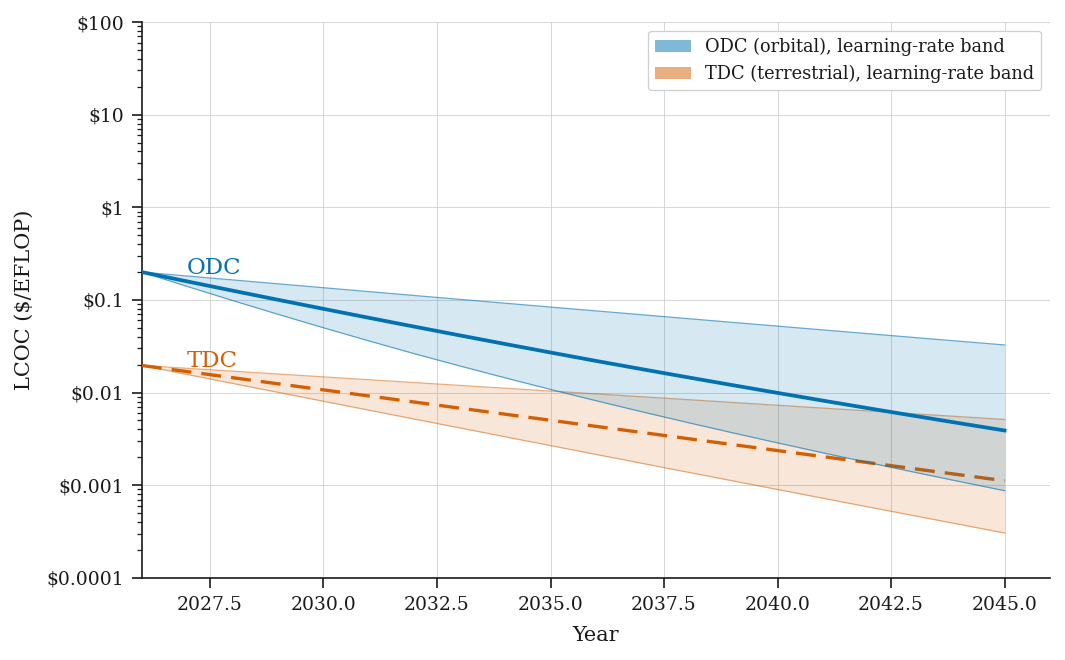

In [9]:
fig, ax = plt.subplots(figsize=(7.2, 4.5))

# TDC band
ax.fill_between(years_calendar, tdc_lo, tdc_hi, color=TDC_COLOR, alpha=0.15,
                zorder=2, linewidth=0)
ax.plot(years_calendar, tdc_hi, color=TDC_COLOR, linewidth=0.6, alpha=0.5, zorder=3)
ax.plot(years_calendar, tdc_lo, color=TDC_COLOR, linewidth=0.6, alpha=0.5, zorder=3)
ax.plot(years_calendar, tdc_nom, color=TDC_COLOR, linewidth=1.6,
        linestyle=(0, (6, 3)), zorder=4)

# ODC band
ax.fill_between(years_calendar, odc_lo, odc_hi, color=ODC_COLOR, alpha=0.16,
                zorder=5, linewidth=0)
ax.plot(years_calendar, odc_hi, color=ODC_COLOR, linewidth=0.6, alpha=0.6, zorder=6)
ax.plot(years_calendar, odc_lo, color=ODC_COLOR, linewidth=0.6, alpha=0.6, zorder=6)
ax.plot(years_calendar, odc_nom, color=ODC_COLOR, linewidth=1.8, zorder=7)

# Crossover annotation (only renders if the baseline curves actually cross)
diff = odc_nom - tdc_nom
crosses = np.where(np.diff(np.sign(diff)))[0]
for cx in crosses:
    cy = (odc_nom[cx] + tdc_nom[cx]) / 2
    ax.axvline(years_calendar[cx], color=INK, linewidth=0.6,
               linestyle=':', alpha=0.5, zorder=2)
    ax.annotate(f'Breakeven\n{years_calendar[cx]}',
                xy=(years_calendar[cx], cy),
                xytext=(years_calendar[cx] + 1.5, cy * 4.0),
                fontsize=9, color=INK, fontfamily=FONT,
                arrowprops=dict(arrowstyle='->', color=INK, alpha=0.6, lw=0.8))

# End-of-line labels
ax.text(2027, odc_nom[0] * 1.12, 'ODC', color=ODC_COLOR, fontfamily=FONT,
        fontsize=11, va='center')
ax.text(2027, tdc_nom[0] * 1.12, 'TDC', color=TDC_COLOR, fontfamily=FONT,
        fontsize=11, va='center')

handles = [
    mpatches.Patch(facecolor=ODC_COLOR, alpha=0.5,
                   label='ODC (orbital), learning-rate band'),
    mpatches.Patch(facecolor=TDC_COLOR, alpha=0.5,
                   label='TDC (terrestrial), learning-rate band'),
]
leg = ax.legend(handles=handles, loc='upper right', frameon=True,
                framealpha=1.0, edgecolor=GRID, facecolor='white',
                fontsize=8.5, prop={'family': FONT, 'size': 8.5})
leg.get_frame().set_linewidth(0.6)
for t in leg.get_texts():
    t.set_color(INK)

style_axes(ax, fig,
    title='',  # caption carries the title in the manuscript
    xlabel='Year',
    ylabel='LCOC ($/EFLOP)',
    xlim=(2026, 2046),
    ylim=(0.0001, 100),
)

plt.tight_layout()
# fig.savefig('lcoc_over_time.pdf')   # vector, for submission
# fig.savefig('lcoc_over_time.png')   # raster preview (300 dpi from rcParams)
plt.show()

### 8b. Tornado sensitivity chart

Each row swings one variable up and down independently around the 2026 baseline and records the resulting LCOC. Rows are sorted by total swing magnitude — variables at the top dominate cost uncertainty. Green = cheaper-LCOC direction; red = more-expensive direction.

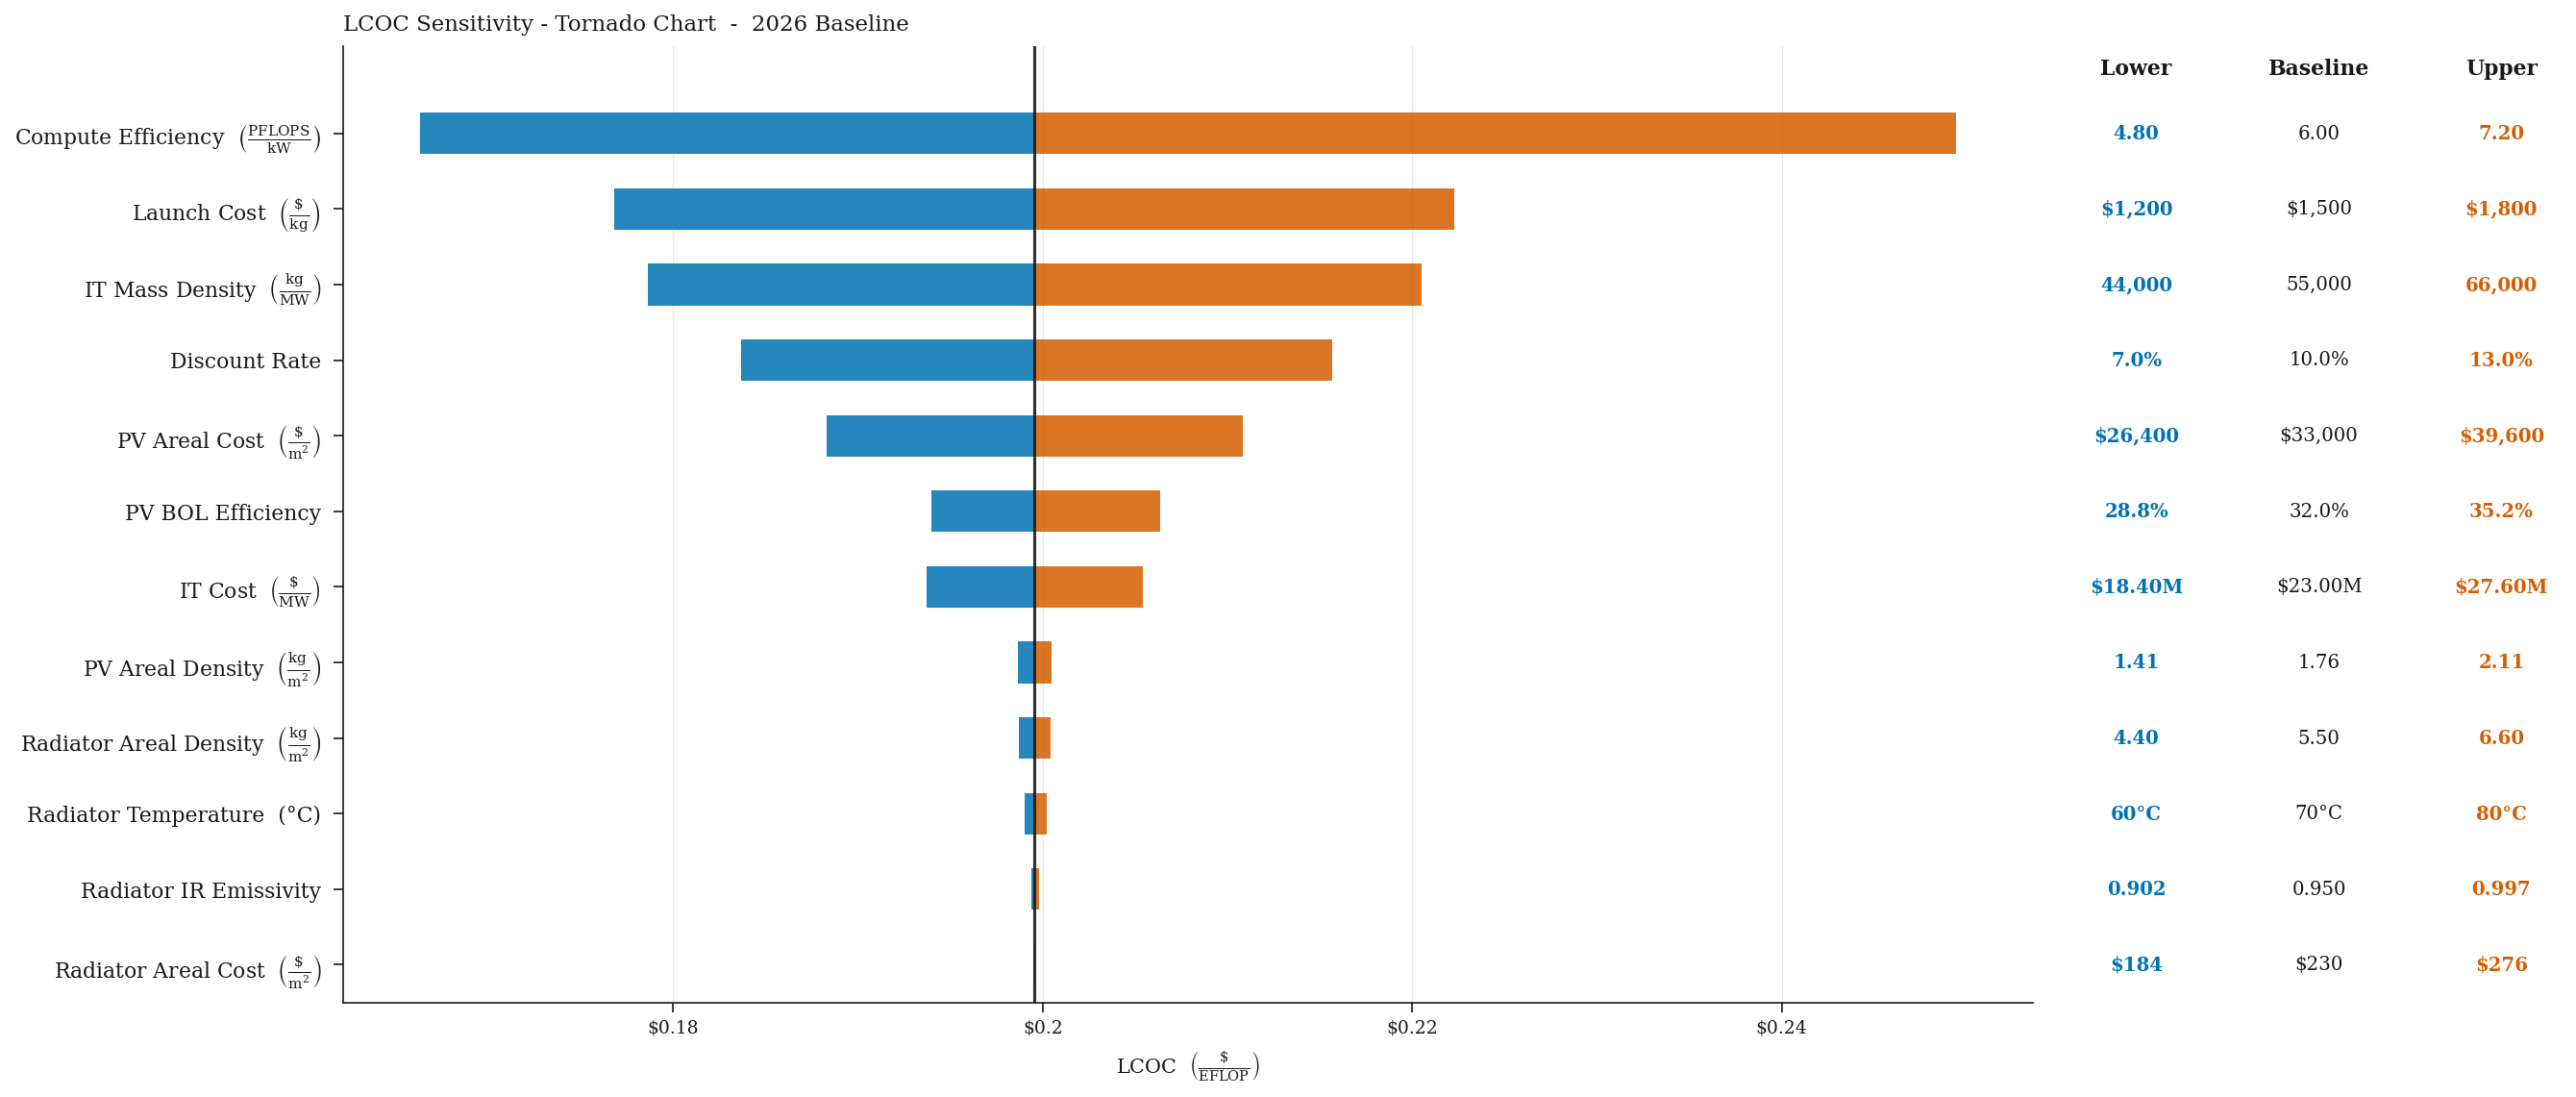

In [10]:
# Parameters to vary, with +/- range
PARAMS_TO_VARY = [
    ('Launch Cost  ' + r'$\left(\frac{\$}{\mathrm{kg}}\right)$',
     'launch_cost_per_kg', 0.20),
    ('Compute Efficiency  ' + r'$\left(\frac{\mathrm{PFLOPS}}{\mathrm{kW}}\right)$',
     'gamma_PFLOPS_per_kW', 0.20),
    ('IT Cost  ' + r'$\left(\frac{\$}{\mathrm{MW}}\right)$',
     'it_cost_per_MW', 0.20),
    ('PV Areal Cost  ' + r'$\left(\frac{\$}{\mathrm{m}^{2}}\right)$',
     'pv_areal_cost', 0.20),
    ('IT Mass Density  ' + r'$\left(\frac{\mathrm{kg}}{\mathrm{MW}}\right)$',
     'it_mass_density', 0.20),
    ('PV Areal Density  ' + r'$\left(\frac{\mathrm{kg}}{\mathrm{m}^{2}}\right)$',
     'pv_areal_mass', 0.20),
    ('Radiator Areal Cost  ' + r'$\left(\frac{\$}{\mathrm{m}^{2}}\right)$',
     'rad_areal_cost', 0.20),
    ('Radiator Temperature  (\u00b0C)',
     'T_rad_C', None, (60.0, 80.0)),
    ('Discount Rate', 'discount_rate', 0.30),
    ('PV BOL Efficiency', 'pv_eff_BOL', 0.10),
    ('Radiator IR Emissivity', 'eps_IR', 0.05),
    ('Radiator Areal Density  ' + r'$\left(\frac{\mathrm{kg}}{\mathrm{m}^{2}}\right)$',
     'rad_areal_mass', 0.20),
]


def format_param_value(attr, value):
    if attr == 'T_rad_C':
        return f'{value:.0f}\u00b0C'
    """Pretty formatter for the Lower / Baseline / Upper value table."""
    if attr in ['discount_rate', 'pv_eff_BOL']:
        return f'{100 * value:.1f}%'
    if attr in ['eps_IR', 'alpha_solar_rad', 'F_earth']:
        return f'{value:.3f}'
    if attr in ['launch_cost_per_kg', 'rad_areal_cost', 'pv_areal_cost']:
        return f'${value:,.0f}'
    if attr == 'it_cost_per_MW':
        return f'${value / 1e6:.2f}M'
    if attr in ['it_mass_density']:
        return f'{value:,.0f}'
    if attr in ['pv_areal_mass', 'rad_areal_mass']:
        return f'{value:.2f}'
    if attr == 'gamma_PFLOPS_per_kW':
        return f'{value:.2f}'
    if attr == 'L_rad':
        return f'{value:.0f}'
    return f'{value:,.3g}'


base_lcoc = calculate_lcoc(BASELINE)['lcoc']

bars = []
for _entry in PARAMS_TO_VARY:
    label, attr, delta = _entry[0], _entry[1], _entry[2]
    _abs_range = _entry[3] if len(_entry) > 3 else None
    base_val = getattr(BASELINE, attr)
    if _abs_range is not None:
        low_param_val, high_param_val = _abs_range
    else:
        low_param_val  = base_val * (1 - delta)
        high_param_val = base_val * (1 + delta)
    lcoc_hi = calculate_lcoc(replace(BASELINE, **{attr: high_param_val}))['lcoc']
    lcoc_lo = calculate_lcoc(replace(BASELINE, **{attr: low_param_val}))['lcoc']
    left   = min(lcoc_lo, lcoc_hi)
    right  = max(lcoc_lo, lcoc_hi)
    swing  = right - left
    bars.append((label, attr, left, right, swing,
                 low_param_val, base_val, high_param_val))

bars.sort(key=lambda x: x[4], reverse=True)

# -----------------------------------------------------------------------------
# Figure layout: main chart on left, value table on right
# -----------------------------------------------------------------------------
fig = plt.figure(figsize=(19, 8.5))
gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[7.0, 2.1],
                     left=0.17, right=0.98, top=0.88, bottom=0.10, wspace=0.02)
ax     = fig.add_subplot(gs[0, 0])
ax_tbl = fig.add_subplot(gs[0, 1])

bar_h = 0.55
for i, (label, attr, left_v, right_v, swing, low_val, mid_val, high_val) in enumerate(bars):
    ax.barh(i, left_v  - base_lcoc, left=base_lcoc, height=bar_h,
            color=ODC_COLOR, alpha=0.85, zorder=3)
    ax.barh(i, right_v - base_lcoc, left=base_lcoc, height=bar_h,
            color=ACCENT_R, alpha=0.85, zorder=3)

ax.axvline(base_lcoc, color=WHITE, linewidth=1.5, alpha=0.9, zorder=5)

style_axes(ax, fig,
    title='LCOC Sensitivity - Tornado Chart  -  2026 Baseline',
    xlabel=r'LCOC  $\left(\frac{\$}{\mathrm{EFLOP}}\right)$',
    y_log=False, y_dollar=False, x_dollar=True,
)
ax.set_yticks(range(len(bars)))
ax.set_yticklabels([b[0] for b in bars], fontfamily=FONT,
                   color=WHITE, fontsize=10.5)
ax.tick_params(axis='y', pad=6)
ax.grid(axis='y', alpha=0)
ax.grid(axis='x', color=GRID, alpha=0.45, linewidth=0.6)
ax.set_ylim(len(bars) - 0.5, -1.15)

# Right-side value table
ax_tbl.set_xlim(0, 1)
ax_tbl.set_ylim(len(bars) - 0.5, -1.15)
ax_tbl.axis('off')

table_x_low, table_x_base, table_x_high = 0.16, 0.52, 0.88
header_y = -0.85

for x, label in [(table_x_low, 'Lower'),
                 (table_x_base, 'Baseline'),
                 (table_x_high, 'Upper')]:
    ax_tbl.text(x, header_y, label, ha='center', va='center',
                fontsize=10.5, color=WHITE, fontfamily=FONT, fontweight='bold')

for i, (label, attr, left_v, right_v, swing, low_val, mid_val, high_val) in enumerate(bars):
    ax_tbl.text(table_x_low,  i, format_param_value(attr, low_val),
                ha='center', va='center', fontsize=9.5,
                color=ODC_COLOR, fontfamily=FONT, fontweight='bold')
    ax_tbl.text(table_x_base, i, format_param_value(attr, mid_val),
                ha='center', va='center', fontsize=9.5,
                color=WHITE, fontfamily=FONT)
    ax_tbl.text(table_x_high, i, format_param_value(attr, high_val),
                ha='center', va='center', fontsize=9.5,
                color=ACCENT_R, fontfamily=FONT, fontweight='bold')

plt.show()

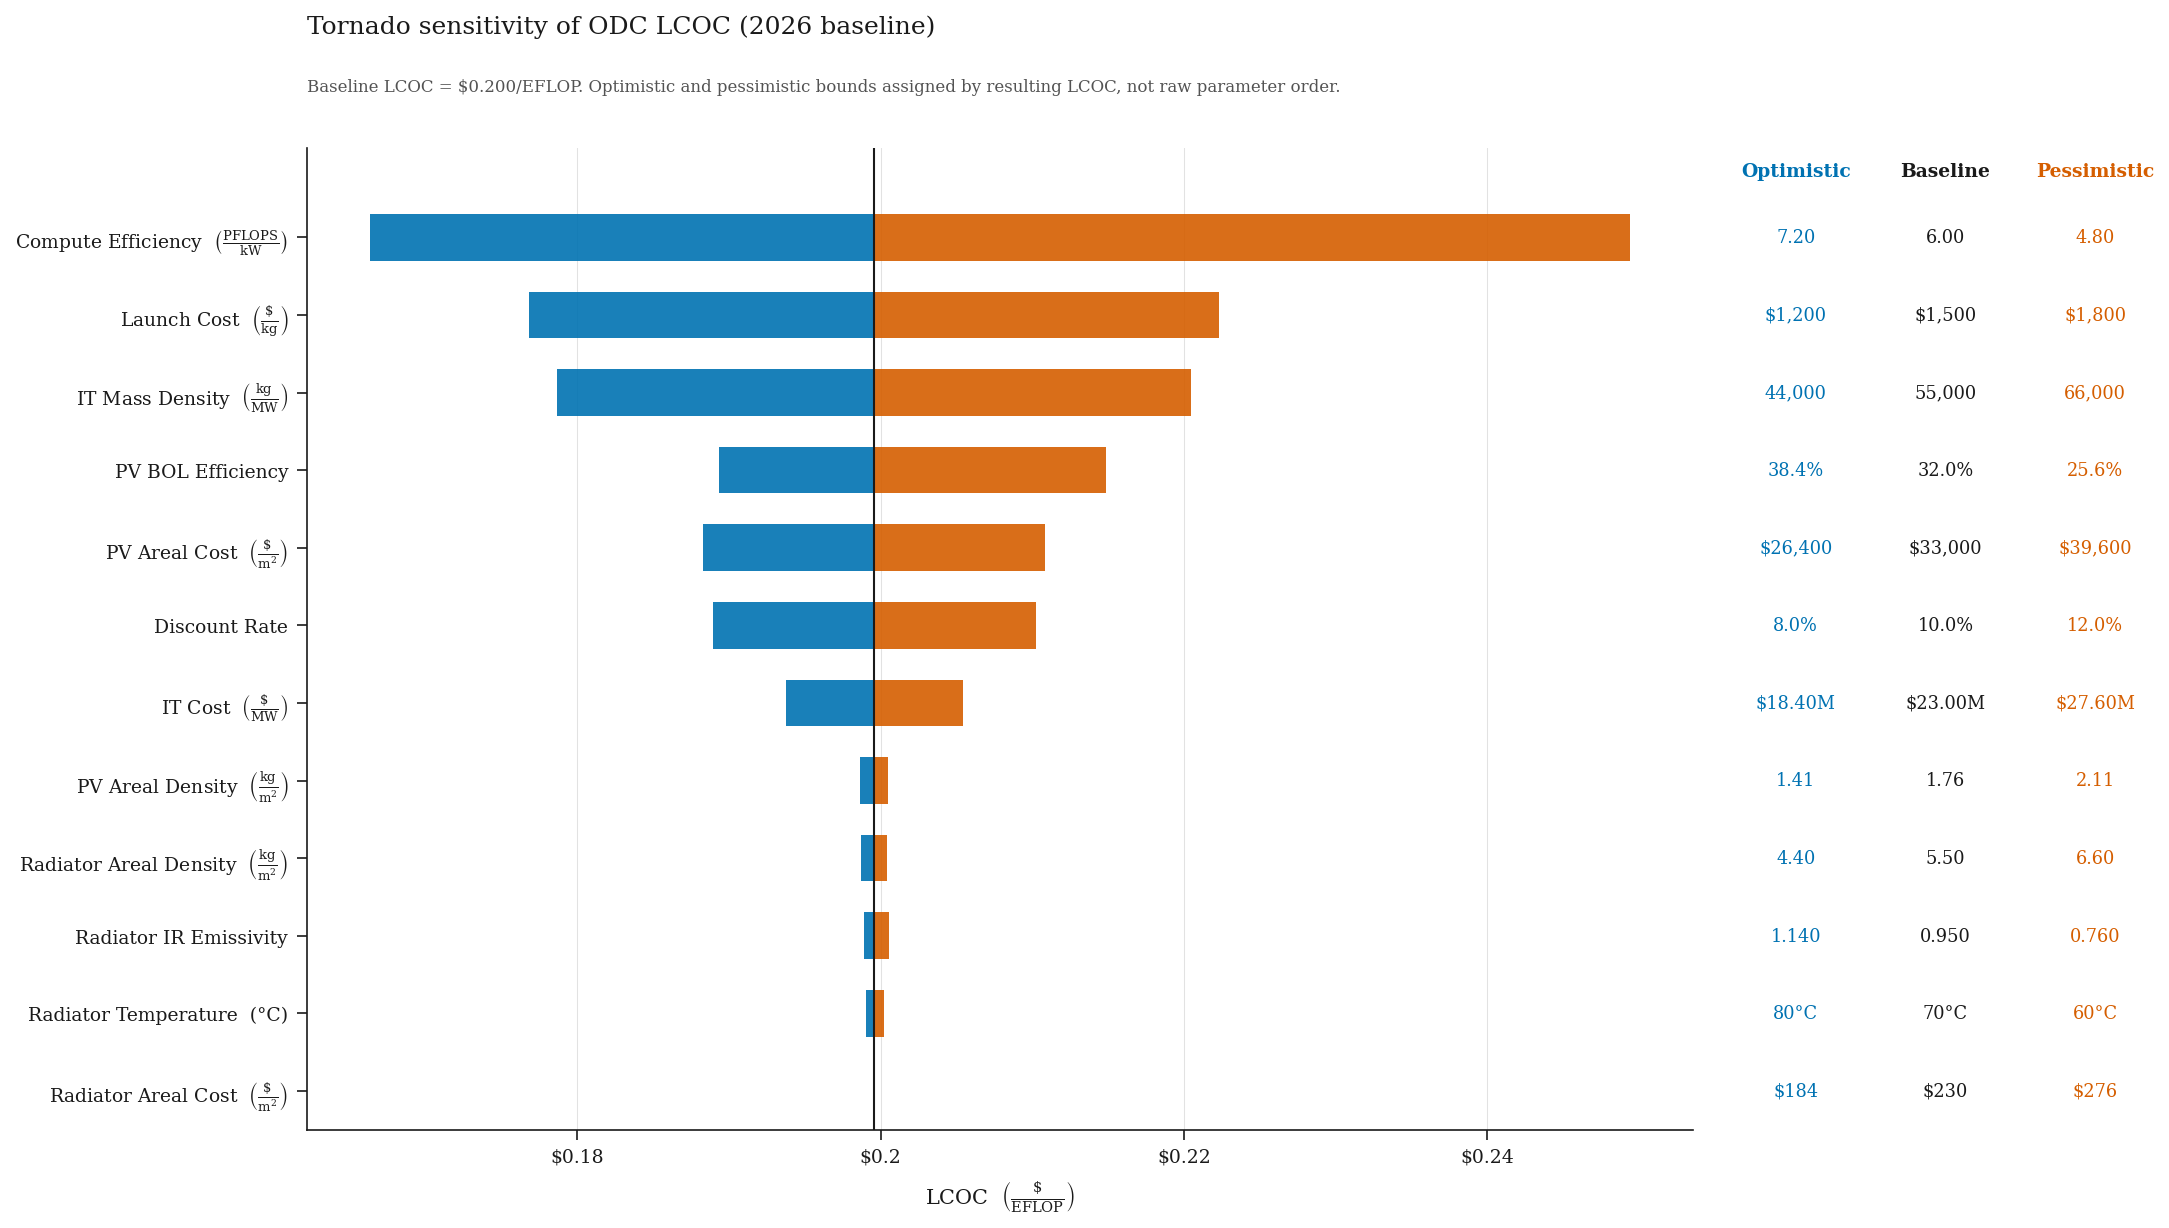

In [11]:
# Parameters to vary, with +/- range
PARAMS_TO_VARY = [
    ('Launch Cost  ' + r'$\left(\frac{\$}{\mathrm{kg}}\right)$',
     'launch_cost_per_kg', 0.20),
    ('Compute Efficiency  ' + r'$\left(\frac{\mathrm{PFLOPS}}{\mathrm{kW}}\right)$',
     'gamma_PFLOPS_per_kW', 0.20),
    ('IT Cost  ' + r'$\left(\frac{\$}{\mathrm{MW}}\right)$',
     'it_cost_per_MW', 0.20),
    ('PV Areal Cost  ' + r'$\left(\frac{\$}{\mathrm{m}^{2}}\right)$',
     'pv_areal_cost', 0.20),
    ('IT Mass Density  ' + r'$\left(\frac{\mathrm{kg}}{\mathrm{MW}}\right)$',
     'it_mass_density', 0.20),
    ('PV Areal Density  ' + r'$\left(\frac{\mathrm{kg}}{\mathrm{m}^{2}}\right)$',
     'pv_areal_mass', 0.20),
    ('Radiator Areal Cost  ' + r'$\left(\frac{\$}{\mathrm{m}^{2}}\right)$',
     'rad_areal_cost', 0.20),
    ('Radiator Temperature  (\u00b0C)',
     'T_rad_C', None, (60.0, 80.0)),
    ('Discount Rate', 'discount_rate', 0.2),
    ('PV BOL Efficiency', 'pv_eff_BOL', 0.20),
    ('Radiator IR Emissivity', 'eps_IR', 0.2),
    ('Radiator Areal Density  ' + r'$\left(\frac{\mathrm{kg}}{\mathrm{m}^{2}}\right)$',
     'rad_areal_mass', 0.20),
]


def format_param_value(attr, value):
    if attr == 'T_rad_C':
        return f'{value:.0f}\u00b0C'
    """Pretty formatter for the Optimistic / Baseline / Pessimistic value table."""
    if attr in ['discount_rate', 'pv_eff_BOL']:
        return f'{100 * value:.1f}%'
    if attr in ['eps_IR', 'alpha_solar_rad', 'F_earth']:
        return f'{value:.3f}'
    if attr in ['launch_cost_per_kg', 'rad_areal_cost', 'pv_areal_cost']:
        return f'${value:,.0f}'
    if attr == 'it_cost_per_MW':
        return f'${value / 1e6:.2f}M'
    if attr in ['it_mass_density']:
        return f'{value:,.0f}'
    if attr in ['pv_areal_mass', 'rad_areal_mass']:
        return f'{value:.2f}'
    if attr == 'gamma_PFLOPS_per_kW':
        return f'{value:.2f}'
    if attr == 'L_rad':
        return f'{value:.0f}'
    return f'{value:,.3g}'


base_lcoc = calculate_lcoc(BASELINE)['lcoc']

bars = []
for _entry in PARAMS_TO_VARY:
    label, attr, delta = _entry[0], _entry[1], _entry[2]
    _abs_range = _entry[3] if len(_entry) > 3 else None
    base_val = getattr(BASELINE, attr)
    if _abs_range is not None:
        low_param_val, high_param_val = _abs_range
    else:
        low_param_val  = base_val * (1 - delta)
        high_param_val = base_val * (1 + delta)

    lcoc_low  = calculate_lcoc(replace(BASELINE, **{attr: low_param_val}))['lcoc']
    lcoc_high = calculate_lcoc(replace(BASELINE, **{attr: high_param_val}))['lcoc']

    cases = [
        {'param_value': low_param_val,  'lcoc': lcoc_low},
        {'param_value': high_param_val, 'lcoc': lcoc_high},
    ]
    cases_sorted = sorted(cases, key=lambda d: d['lcoc'])
    optimistic_case, pessimistic_case = cases_sorted[0], cases_sorted[-1]

    swing = pessimistic_case['lcoc'] - optimistic_case['lcoc']
    bars.append((
        label, attr,
        optimistic_case['lcoc'], base_lcoc, pessimistic_case['lcoc'], swing,
        optimistic_case['param_value'], base_val, pessimistic_case['param_value'],
    ))

# Largest swing at the top
bars.sort(key=lambda x: x[5], reverse=True)


# -----------------------------------------------------------------------------
# Figure: tornado on the left, value table on the right
# -----------------------------------------------------------------------------
LEFT = 0.34
fig = plt.figure(figsize=(19, 8.5))
gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[7.0, 2.1],
                      left=LEFT, right=0.985, top=0.86, bottom=0.09, wspace=0.04)
ax     = fig.add_subplot(gs[0, 0])
ax_tbl = fig.add_subplot(gs[0, 1])

bar_h = 0.6
for i, (label, attr, opt_lcoc, base_lcoc_, pes_lcoc, swing,
        opt_val, base_val, pes_val) in enumerate(bars):
    ax.barh(i, opt_lcoc - base_lcoc, left=base_lcoc, height=bar_h,
            color=ODC_COLOR, alpha=0.9, zorder=3)      # better (lower LCOC)
    ax.barh(i, pes_lcoc - base_lcoc, left=base_lcoc, height=bar_h,
            color=ACCENT_R, alpha=0.9, zorder=3)        # worse  (higher LCOC)

# Baseline reference line
ax.axvline(base_lcoc, color=INK, linewidth=1.0, zorder=5)

# Axis styling (categorical y, so no log / no y-grid)
style_axes(ax, fig, title='',
           xlabel=r'LCOC  $\left(\frac{\$}{\mathrm{EFLOP}}\right)$',
           y_log=False, y_dollar=False, x_dollar=True)

ax.set_yticks(range(len(bars)))
ax.set_yticklabels([b[0] for b in bars], fontfamily=FONT, color=INK, fontsize=9)
ax.tick_params(axis='y', pad=4)
ax.grid(axis='y', alpha=0)                              # no horizontal grid
ax.grid(axis='x', color=GRID, alpha=0.6, linewidth=0.5)
ax.set_ylim(len(bars) - 0.5, -1.15)

# Title + subtitle (caption usually carries these in the manuscript)
fig.text(LEFT, 0.965, 'Tornado sensitivity of ODC LCOC (2026 baseline)',
         ha='left', va='top', fontsize=12, color=INK, fontfamily=FONT)
fig.text(LEFT, 0.915,
         fr'Baseline LCOC = ${base_lcoc:.3f}/EFLOP. Optimistic and pessimistic '
         'bounds assigned by resulting LCOC, not raw parameter order.',
         ha='left', va='top', fontsize=8, color=INK, alpha=0.75, fontfamily=FONT)

# -----------------------------------------------------------------------------
# Right-side value table
# -----------------------------------------------------------------------------
ax_tbl.set_xlim(0, 1)
ax_tbl.set_ylim(len(bars) - 0.5, -1.15)
ax_tbl.axis('off')

col_x = {'opt': 0.16, 'base': 0.52, 'pes': 0.88}
for x, header, col in [(col_x['opt'], 'Optimistic',  ODC_COLOR),
                       (col_x['base'], 'Baseline',   INK),
                       (col_x['pes'], 'Pessimistic', ACCENT_R)]:
    ax_tbl.text(x, -0.85, header, ha='center', va='center', fontsize=9,
                color=col, fontfamily=FONT, fontweight='bold')

for i, (label, attr, opt_lcoc, base_lcoc_, pes_lcoc, swing,
        opt_val, base_val, pes_val) in enumerate(bars):
    ax_tbl.text(col_x['opt'],  i, format_param_value(attr, opt_val),
                ha='center', va='center', fontsize=8.5, color=ODC_COLOR, fontfamily=FONT)
    ax_tbl.text(col_x['base'], i, format_param_value(attr, base_val),
                ha='center', va='center', fontsize=8.5, color=INK, fontfamily=FONT)
    ax_tbl.text(col_x['pes'],  i, format_param_value(attr, pes_val),
                ha='center', va='center', fontsize=8.5, color=ACCENT_R, fontfamily=FONT)

# fig.savefig('tornado_2026.pdf')
# fig.savefig('tornado_2026.png')
plt.show()

### 8c. LCOC vs launch cost sweep

How sensitive is LCOC to launch cost? Three solid/dashed curves at 2026, 2035, 2045 (under baseline learning rates) — each curve sweeps launch cost from \$50 to \$5000/kg while holding everything else at that year's evolved values. Markers show where the baseline launch-cost trajectory lands each year. Horizontal lines = TDC reference at the same year.

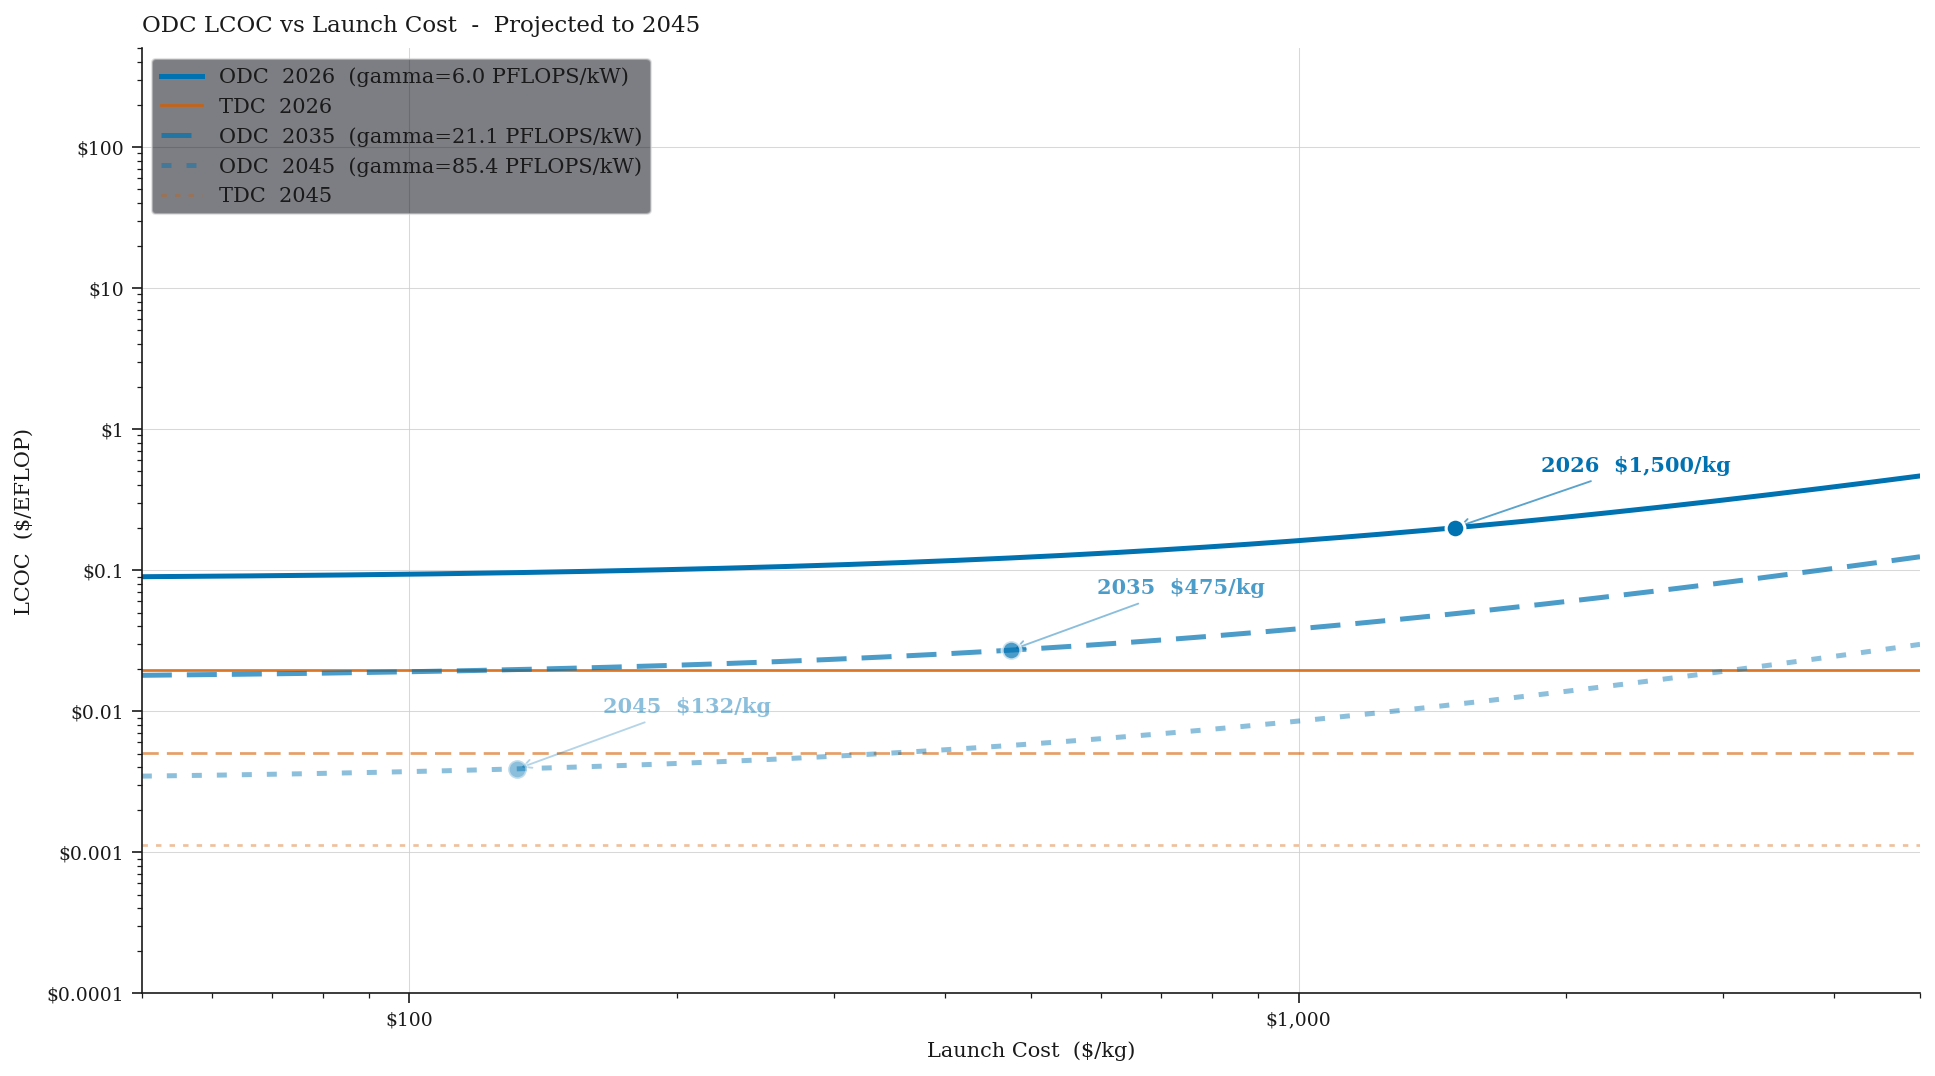

In [12]:
launch_costs  = np.logspace(np.log10(50), np.log10(5000), 200)
years_to_show = {'2026': 0, '2035': 9, '2045': 19}
line_alphas   = {'2026': 1.00, '2035': 0.70, '2045': 0.45}
line_styles   = {'2026': 'solid', '2035': (0,(6,3)), '2045': (0,(2,3))}

fig, ax = plt.subplots(figsize=(13, 7.5))

for yr_label, yo in years_to_show.items():
    ev_base = evolve_scenario(BASELINE, yo, LR_BASELINE)
    tdc_yr  = terrestrial_evolved(BASELINE.gamma_PFLOPS_per_kW, yo, LR_BASELINE)
    lcocs = np.array([
        calculate_lcoc(replace(ev_base, launch_cost_per_kg=lc))['lcoc']
        for lc in launch_costs
    ])
    a  = line_alphas[yr_label]
    ls = line_styles[yr_label]

    ax.plot(launch_costs, lcocs, color=ODC_COLOR, linewidth=2.4,
            linestyle=ls, alpha=a,
            label=f'ODC  {yr_label}  (gamma={ev_base.gamma_PFLOPS_per_kW:.1f} PFLOPS/kW)')

    nom_lc   = BASELINE.launch_cost_per_kg * (1 - LR_BASELINE.launch)**yo
    nom_lcoc = calculate_lcoc(replace(ev_base, launch_cost_per_kg=nom_lc))['lcoc']
    ax.plot(nom_lc, nom_lcoc, 'o', color=ODC_COLOR, markersize=9,
            alpha=a, zorder=10, markeredgecolor=BG, markeredgewidth=1.5)
    ax.annotate(f'{yr_label}  ${nom_lc:,.0f}/kg',
                xy=(nom_lc, nom_lcoc),
                xytext=(nom_lc * 1.25, nom_lcoc * 2.5),
                fontsize=10, color=ODC_COLOR, fontfamily=FONT,
                alpha=a, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=ODC_COLOR,
                                alpha=a*0.65, lw=0.9))

    ax.axhline(tdc_yr, color=TDC_COLOR, linewidth=1.3,
               linestyle=ls, alpha=a*0.85,
               label=f'TDC  {yr_label}' if yr_label in ('2026', '2045') else None)

leg = ax.legend(loc='upper left', frameon=True, framealpha=0.55,
                edgecolor=GRID, facecolor='#12141e',
                prop={'family': FONT, 'size': 10})
for t in leg.get_texts(): t.set_color(WHITE)

style_axes(ax, fig,
    title='ODC LCOC vs Launch Cost  -  Projected to 2045',
    # subtitle='Dashed = 2035 & 2045 projection at baseline learning rates  -  Circles = baseline launch cost that year  -  TDC reference lines',
    xlabel='Launch Cost  ($/kg)',
    ylabel='LCOC  ($/EFLOP)',
    x_log=True, y_log=True,
    xlim=(50, 5000), ylim=(0.0001, 500),
    x_dollar=True, y_dollar=True,
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### 8d. Data-center demand growth and ODC market-share scenarios

Global data-center demand is projected to grow sharply, and **adoption drives learning**: the more of that demand an ODC fleet serves, the larger its cumulative deployed capacity, and the faster its production-driven costs (launch, PV) fall along a Wright's-law experience curve. This section makes that feedback explicit.

**Demand envelope (sources).** Anchored to: **Goldman Sachs** (global DC power +50% by 2027, +165% by 2030 vs 2023), **IEA** *Energy and AI* (DC electricity ≈ doubles to ~945 TWh by 2030, ~15%/yr), and **McKinsey** *AI Power* (171–219 GW global DC capacity by 2030, 19–22%/yr CAGR, ~70% AI). We take a central capacity path of ~120 GW (2026) → ~195 GW (2030), then a decelerating CAGR to ~430 GW by 2045, with a ±15% band spanning the McKinsey low/high range.

**Panel A** — total DC demand (left axis, band = source spread) with the ODC-*served* capacity (right axis) for four scenarios in which ODCs capture **0.5 / 2 / 5 / 10 % of the *incremental* demand** added after 2026.

**Panel B** — the payoff: 2045 ODC LCOC as a function of ODC market share. Here launch and PV costs are driven **purely by Wright's law on cumulative ODC capacity** (LR = 15 %/doubling launch, 20 %/doubling PV), anchored at C₀ = 0.1 GW with 2026 baseline costs — consistent with the first commercial ODC fleets implied by Starcloud's deployment roadmap (first H100 in orbit Nov 2025; Blackwell commercial module 2026; ~40 MW-class ODCs early 2030s). Compute efficiency γ follows its industry-wide 2045 calendar value (it is not ODC-specific); IT $/MW and radiator cost carry no learning. The dashed line is the 2045 TDC reference: ODC LCOC falls steadily with share as deployment-driven learning compounds, **narrowing the gap to the TDC** (the curve and the reference line meet only if ODC captures enough share to drive launch/PV far enough down the experience curve).

*Caveat:* attributing all launch/PV learning to ODC deployment isolates the adoption→cost feedback; in reality launch also benefits from non-ODC demand, so the share needed for parity is an upper bound.

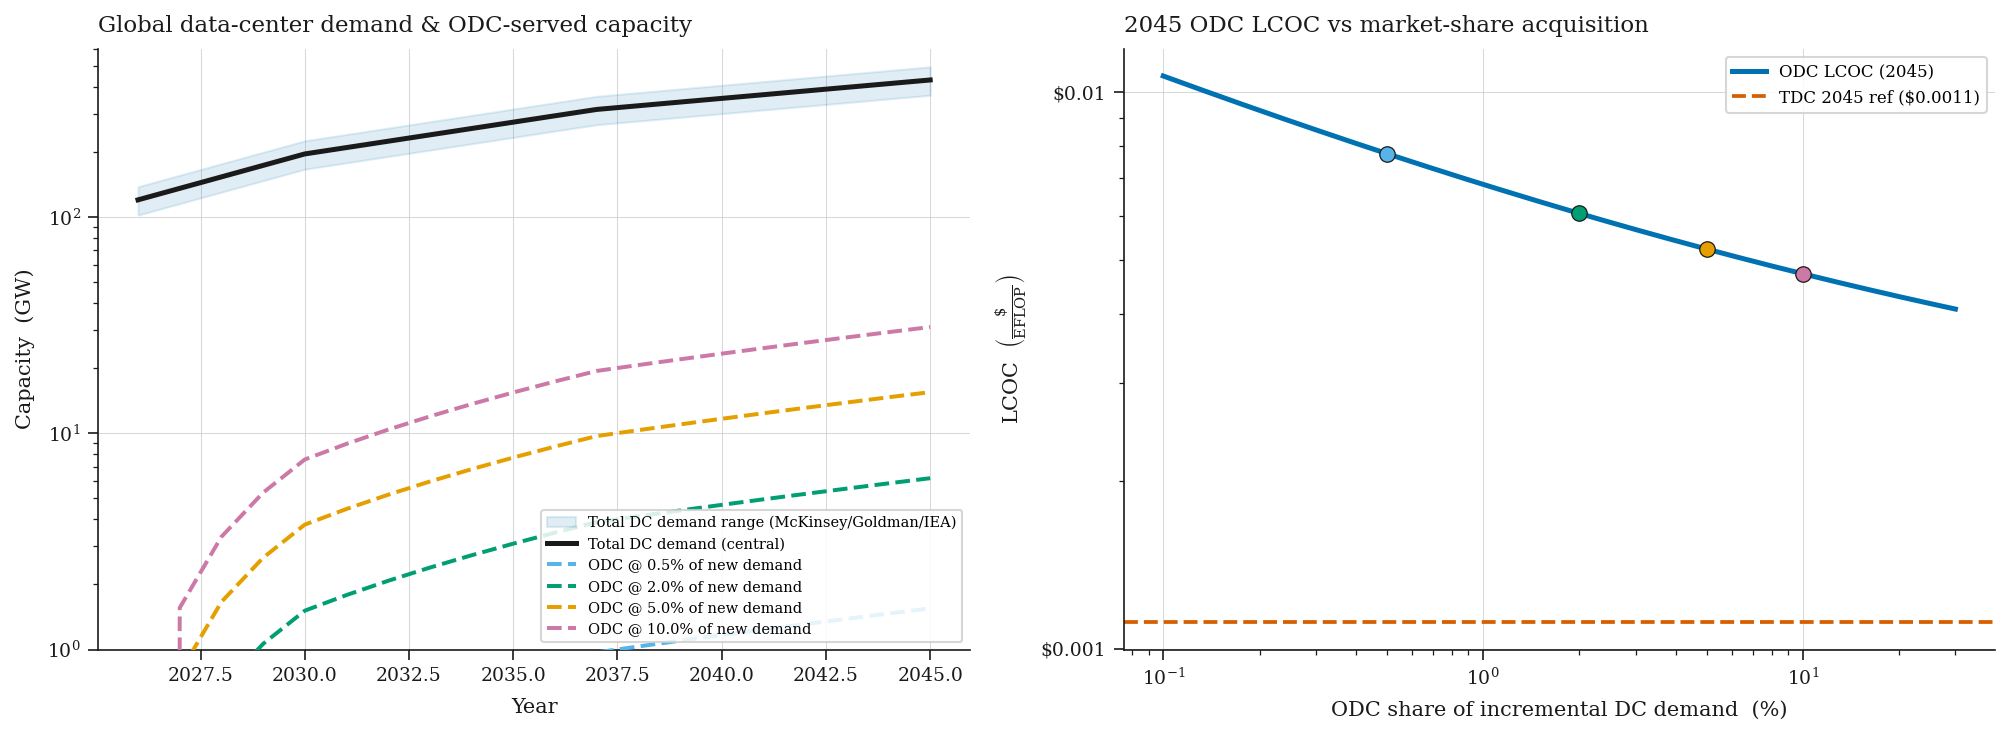

2045 demand: 430 GW  (incremental since 2026: 310 GW)
2045 TDC reference LCOC: $0.0011/EFLOP
  ODC @  0.5% share -> cumulative   1.5 GW, 2045 LCOC $0.0078/EFLOP
  ODC @  2.0% share -> cumulative   6.2 GW, 2045 LCOC $0.0061/EFLOP
  ODC @  5.0% share -> cumulative  15.5 GW, 2045 LCOC $0.0052/EFLOP
  ODC @ 10.0% share -> cumulative  31.0 GW, 2045 LCOC $0.0047/EFLOP
No parity within plotted share range


In [13]:
# =============================================================================
# 8d. DC demand growth + ODC market-share -> learning -> LCOC
# =============================================================================

# ---- Total DC demand path (GW of IT capacity), source-anchored ----------------
def dc_demand_GW(year):
    """Central global DC capacity [GW]. Anchors: ~120 GW (2026) -> ~195 GW (2030,
    McKinsey midpoint) -> decelerating CAGR to ~430 GW (2045)."""
    y = np.asarray(year, dtype=float)
    D0 = 120.0  # 2026
    out = np.empty_like(y)
    # piecewise compound growth
    for k, yr in np.ndenumerate(y):
        if yr <= 2030:
            out[k] = D0 * 1.13 ** (yr - 2026)            # ~13%/yr 2026-2030
        elif yr <= 2037:
            d2030 = D0 * 1.13 ** 4
            out[k] = d2030 * 1.07 ** (yr - 2030)         # ~7%/yr 2030-2037
        else:
            d2037 = D0 * 1.13 ** 4 * 1.07 ** 7
            out[k] = d2037 * 1.04 ** (yr - 2037)         # ~4%/yr 2037-2045
    return out

yrs = np.arange(2026, 2046)
D_base = dc_demand_GW(yrs)
D_low, D_high = 0.85 * D_base, 1.15 * D_base              # +/-15% source spread
D_2026 = dc_demand_GW(2026).item()
incremental = D_base - D_2026                              # demand added after 2026

SHARES = [0.005, 0.02, 0.05, 0.10]                        # ODC share of incremental demand
SHARE_COLORS = ['#56B4E9', '#009E73', '#E69F00', '#CC79A7']  # Okabe-Ito

# ---- Wright's-law learning on cumulative ODC capacity (Panel B) ---------------
C0_GW       = 0.10        # anchor cumulative ODC capacity [GW] (~first commercial fleet)
LR_LAUNCH   = 0.15        # 15% / doubling
LR_PV       = 0.20        # 20% / doubling (Swanson)
YR_OFFSET   = 19          # 2045 calendar offset for industry-wide gamma / TDC
gamma_2045  = BASELINE.gamma_PFLOPS_per_kW * (1 + LR_BASELINE.gamma_growth) ** YR_OFFSET
pv_eff_2045 = min(0.35, BASELINE.pv_eff_BOL + LR_BASELINE.pv_eff_pp * YR_OFFSET)
tdc_2045    = terrestrial_evolved(BASELINE.gamma_PFLOPS_per_kW, YR_OFFSET, LR_BASELINE)
inc_2045    = incremental[-1]                              # GW added by 2045

def odc_lcoc_vs_share(share):
    """2045 ODC LCOC when ODCs serve `share` of incremental demand.
    Launch & PV fall via Wright's law on cumulative ODC capacity; gamma is the
    industry-wide 2045 value; IT $/MW and radiator carry no learning."""
    C = np.maximum(share * inc_2045, C0_GW)
    doublings = np.log2(C / C0_GW)
    launch = BASELINE.launch_cost_per_kg * (1 - LR_LAUNCH) ** doublings
    pv     = BASELINE.pv_areal_cost      * (1 - LR_PV)     ** doublings
    s = replace(BASELINE, launch_cost_per_kg=float(launch), pv_areal_cost=float(pv),
                gamma_PFLOPS_per_kW=gamma_2045, pv_eff_BOL=pv_eff_2045)
    return calculate_lcoc(s)['lcoc']

share_grid = np.logspace(np.log10(0.001), np.log10(0.30), 240)
lcoc_grid  = np.array([odc_lcoc_vs_share(s) for s in share_grid])

# parity share (where ODC LCOC crosses TDC 2045)
parity_share = None
below = lcoc_grid <= tdc_2045
if below.any():
    j = np.argmax(below)
    if j > 0:
        x0, x1 = share_grid[j-1], share_grid[j]
        y0, y1 = lcoc_grid[j-1], lcoc_grid[j]
        parity_share = x0 + (tdc_2045 - y0) * (x1 - x0) / (y1 - y0)

# =============================================================================
# Figure
# =============================================================================
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13.5, 5.0))
fig.patch.set_facecolor(BG)

# ---- Panel A: demand forecast + ODC-served capacity (single GW axis, log) -----
# One y-axis (GW) for BOTH the total-demand band and the ODC-served capacity, so
# the share of demand the ODC fleet meets is read directly off the same scale.
axA.fill_between(yrs, D_low, D_high, color=ODC_COLOR, alpha=0.12, zorder=1,
                 label='Total DC demand range (McKinsey/Goldman/IEA)')
axA.plot(yrs, D_base, color=INK, lw=2.4, zorder=4, label='Total DC demand (central)')
for s, col in zip(SHARES, SHARE_COLORS):
    axA.plot(yrs, s * incremental, color=col, lw=1.9, ls='--', zorder=3,
             label=f'ODC @ {s*100:.1f}% of new demand')
style_axes(axA, fig, title='Global data-center demand & ODC-served capacity',
           xlabel='Year', ylabel='Capacity  (GW)',
           y_log=True, y_dollar=False)
axA.set_ylim(1, 600)
axA.legend(fontsize=7.0, loc='lower right', framealpha=0.85,
           facecolor=BG, edgecolor=GRID)

# ---- Panel B: 2045 ODC LCOC vs market share ----------------------------------
axB.plot(share_grid * 100, lcoc_grid, color=ODC_COLOR, lw=2.4, zorder=3,
         label='ODC LCOC (2045)')
for s, col in zip(SHARES, SHARE_COLORS):
    axB.scatter(s * 100, odc_lcoc_vs_share(s), color=col, s=55, zorder=5,
                edgecolor=INK, linewidth=0.6)
axB.axhline(tdc_2045, color=TDC_COLOR, ls='--', lw=1.8, zorder=2,
            label=f'TDC 2045 ref (${tdc_2045:.4f})')
if parity_share is not None:
    axB.axvline(parity_share * 100, color=INK, ls=':', lw=1.2, alpha=0.7)
    axB.annotate(f'parity @ {parity_share*100:.1f}% share',
                 xy=(parity_share * 100, tdc_2045), xytext=(parity_share * 100 * 1.15, tdc_2045 * 2.2),
                 fontsize=8.5, color=INK, fontfamily=FONT,
                 arrowprops=dict(arrowstyle='->', color=INK, lw=0.8))
style_axes(axB, fig, title='2045 ODC LCOC vs market-share acquisition',
           xlabel='ODC share of incremental DC demand  (%)',
           ylabel=r'LCOC  $\left(\frac{\$}{\mathrm{EFLOP}}\right)$',
           y_log=True)
axB.set_xscale('log')
axB.legend(fontsize=8, loc='upper right', framealpha=0.85, facecolor=BG, edgecolor=GRID)

plt.tight_layout()
# fig.savefig('demand_marketshare.pdf'); fig.savefig('demand_marketshare.png', dpi=200)
plt.show()

print(f'2045 demand: {D_base[-1]:.0f} GW  (incremental since 2026: {inc_2045:.0f} GW)')
print(f'2045 TDC reference LCOC: ${tdc_2045:.4f}/EFLOP')
for s in SHARES:
    print(f'  ODC @ {s*100:4.1f}% share -> cumulative {s*inc_2045:5.1f} GW, '
          f'2045 LCOC ${odc_lcoc_vs_share(s):.4f}/EFLOP')
if parity_share is not None:
    print(f'ODC<->TDC parity at ~{parity_share*100:.2f}% share of incremental demand')
else:
    print('No parity within plotted share range')


## 9. Summary

In [14]:
print('=' * 96)
print('SUMMARY: Orbital vs Terrestrial DC LCOC (2026-2045)')
print('=' * 96)
print(f'\nBaseline ODC parameters (locked initial values, 2026):')
print(f'  gamma           = {BASELINE.gamma_PFLOPS_per_kW} PFLOPS/kW')
print(f'  Launch          = ${BASELINE.launch_cost_per_kg:,.0f}/kg')
print(f'  PV eta_BOL      = {BASELINE.pv_eff_BOL}')
print(f'  PV areal cost   = ${BASELINE.pv_areal_cost:,.0f}/m^2')
print(f'  Rad areal cost  = ${BASELINE.rad_areal_cost:,.0f}/m^2')
print(f'  IT cost         = ${BASELINE.it_cost_per_MW/1e6:.1f}M/MW')
print(f'  alpha_solar     = {BASELINE.alpha_solar_rad}')
print(f'  alpha_IR        = {BASELINE.eps_IR}')
print(f'\nLearning-rate scenarios drive the uncertainty band on plots.')
print()

print(f'{"Year":>6s}  |   {"ODC range $/EFLOP":>32s}     {"TDC range $/EFLOP":>32s}  |  ratio')
print(f'{"":>6s}  |   {"(pes / base / opt)":>32s}     {"(pes / base / opt)":>32s}  |  (base)')
print('-' * 96)
for label, idx in [('2026', 0), ('2030', 4), ('2035', 9), ('2040', 14), ('2045', 19)]:
    odc_range = f'${odc_lo[idx]:.4f} / ${odc_nom[idx]:.4f} / ${odc_hi[idx]:.4f}'
    tdc_range = f'${tdc_lo[idx]:.4f} / ${tdc_nom[idx]:.4f} / ${tdc_hi[idx]:.4f}'
    print(f'{label:>6s}  |   {odc_range:>32s}     {tdc_range:>32s}  |  {odc_nom[idx]/tdc_nom[idx]:.2f}x')

print()
print('Cost breakdown for 2026 baseline ODC:')
for k, v in baseline_result['breakdown'].items():
    print(f'  {k:10s} ${v:.4f}/EFLOP   ({v/baseline_result["lcoc"]*100:5.1f}%)')

print()
print('Key takeaways:')
print('  - Initial parameter values are locked; only the learning rate varies.')
print('  - Launch cost decline drives the ODC trajectory; under baseline LR, launch falls')
print('    below ~$200/kg by 2045, narrowing the gap to TDC substantially.')
print('  - gamma improvement applies to both ODC and TDC equally and shifts both curves')
print('    down in parallel - it does not by itself close the ODC/TDC gap.')
print('  - PV areal cost ($33,000/m^2) and IT cost ($23M/MW) are now the second-tier')
print('    sensitivities behind launch.  See the tornado chart for confirmation.')

SUMMARY: Orbital vs Terrestrial DC LCOC (2026-2045)

Baseline ODC parameters (locked initial values, 2026):
  gamma           = 6.0 PFLOPS/kW
  Launch          = $1,500/kg
  PV eta_BOL      = 0.32
  PV areal cost   = $33,000/m^2
  Rad areal cost  = $230/m^2
  IT cost         = $23.0M/MW
  alpha_solar     = 0.05
  alpha_IR        = 0.95

Learning-rate scenarios drive the uncertainty band on plots.

  Year  |                  ODC range $/EFLOP                    TDC range $/EFLOP  |  ratio
        |                 (pes / base / opt)                   (pes / base / opt)  |  (base)
------------------------------------------------------------------------------------------------
  2026  |        $0.1996 / $0.1996 / $0.1996          $0.0196 / $0.0196 / $0.0196  |  10.19x
  2030  |        $0.1353 / $0.0800 / $0.0500          $0.0148 / $0.0107 / $0.0080  |  7.50x
  2035  |        $0.0837 / $0.0270 / $0.0108          $0.0104 / $0.0050 / $0.0027  |  5.39x
  2040  |        $0.0521 / $0.0099 / $0.

# Carbon Impact

Verification: F_perp_adjacent(1,1) = 0.20004 (expect 0.20004)

CARBON MODEL  -  100 MW IT, 15 yr mission, grid 0.40 tCO2e/MWh

PHYSICAL SIZING
  PV array :      270,130 m^2  (50.5 football fields)
  Geometry: L=300 m, H=450.2 m, h=1.501, W=229.6 m (w=0.7652)
  F_PV (per face): 0.2567   Net cooling: 1452.1 W/m^2
  Radiator :       68,866 m^2  (12.9 football fields)
  Mass budget (t): PV 475, Radiator 634, IT 5,500, Total 6,609

TDC CARBON (tCO2e)
  IT (all gens)   :      103,096
  Core & shell    :       32,500
  MEP             :       20,000
  Embodied total  :      155,596
  Operational     :    5,886,720
  TOTAL           :    6,042,316  (6.04 Mt)

ODC CARBON (tCO2e)
  Launches: 177  @ 16,222 t/launch
  Launch initial  :    1,086,895
  Launch refresh  :    1,784,454
  IT (all gens)   :      103,096
  PV array        :      378,182
  Radiator        :        5,923
  TOTAL           :    3,358,549  (3.36 Mt)

  ODC/TDC ratio @ grid 0.40: 0.56x



Figures written to carbon_figs/: tdc_carbon, odc_carbon, comparison, tdc_timeline, odc_timeline (.png)

  Exact grid crossover: 0.218 tCO2e/MWh


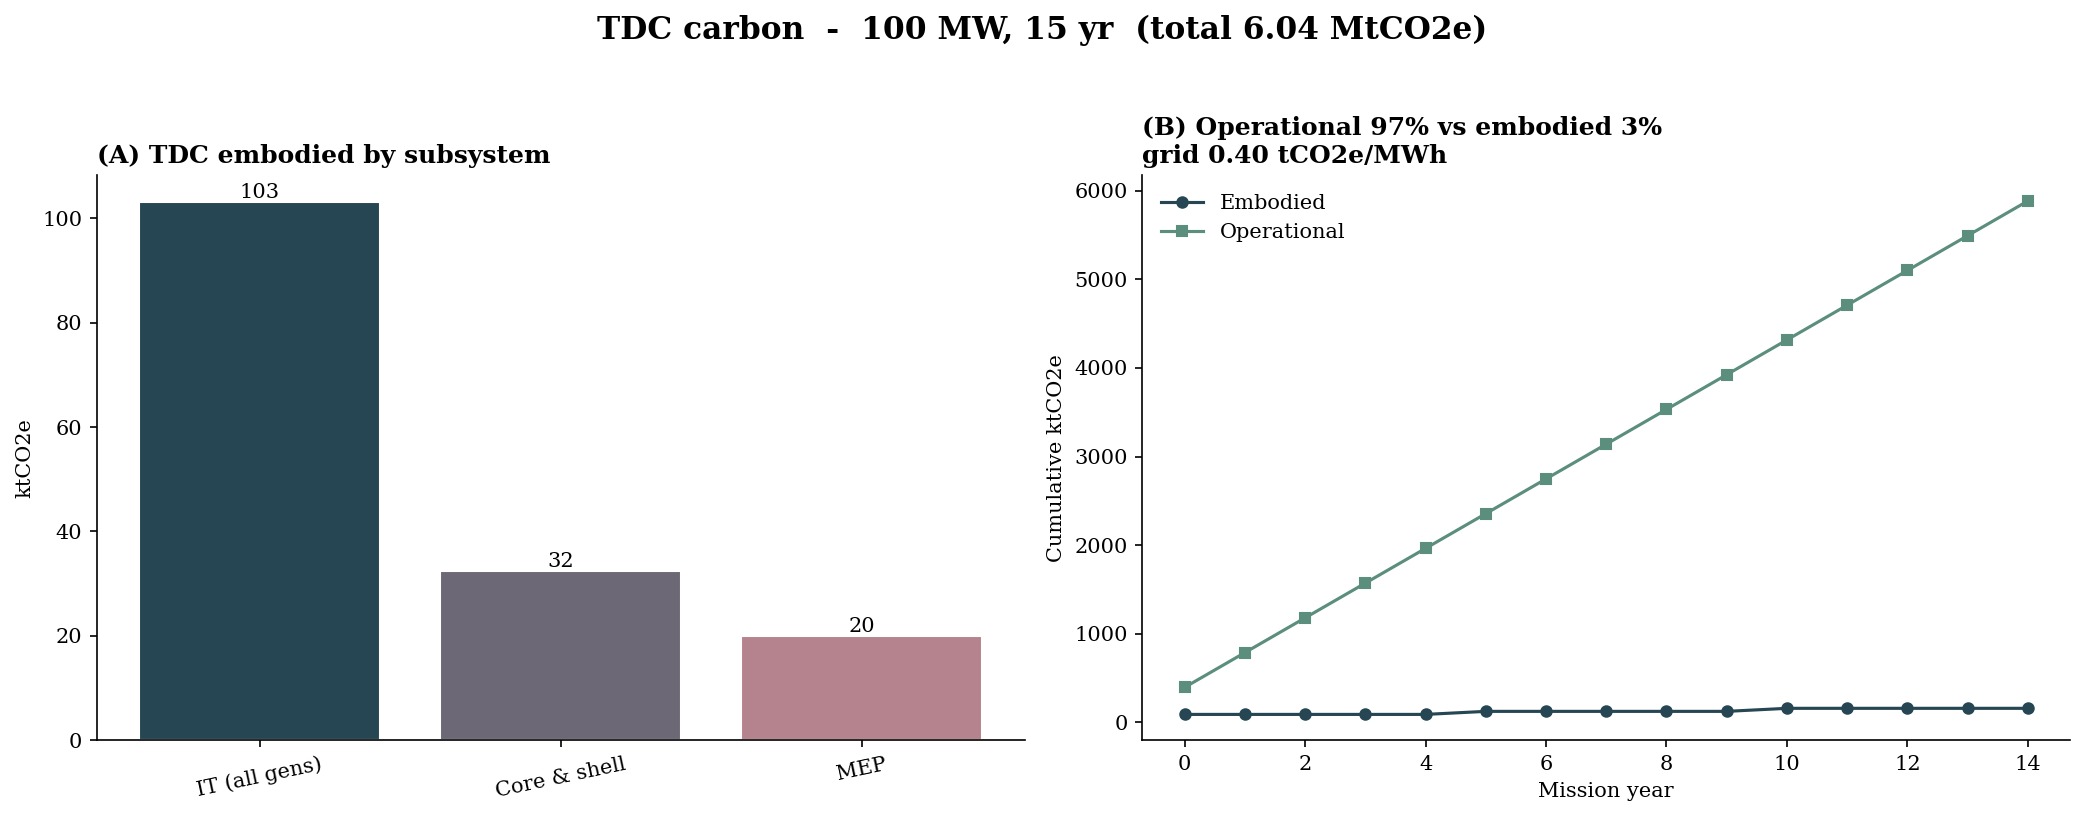

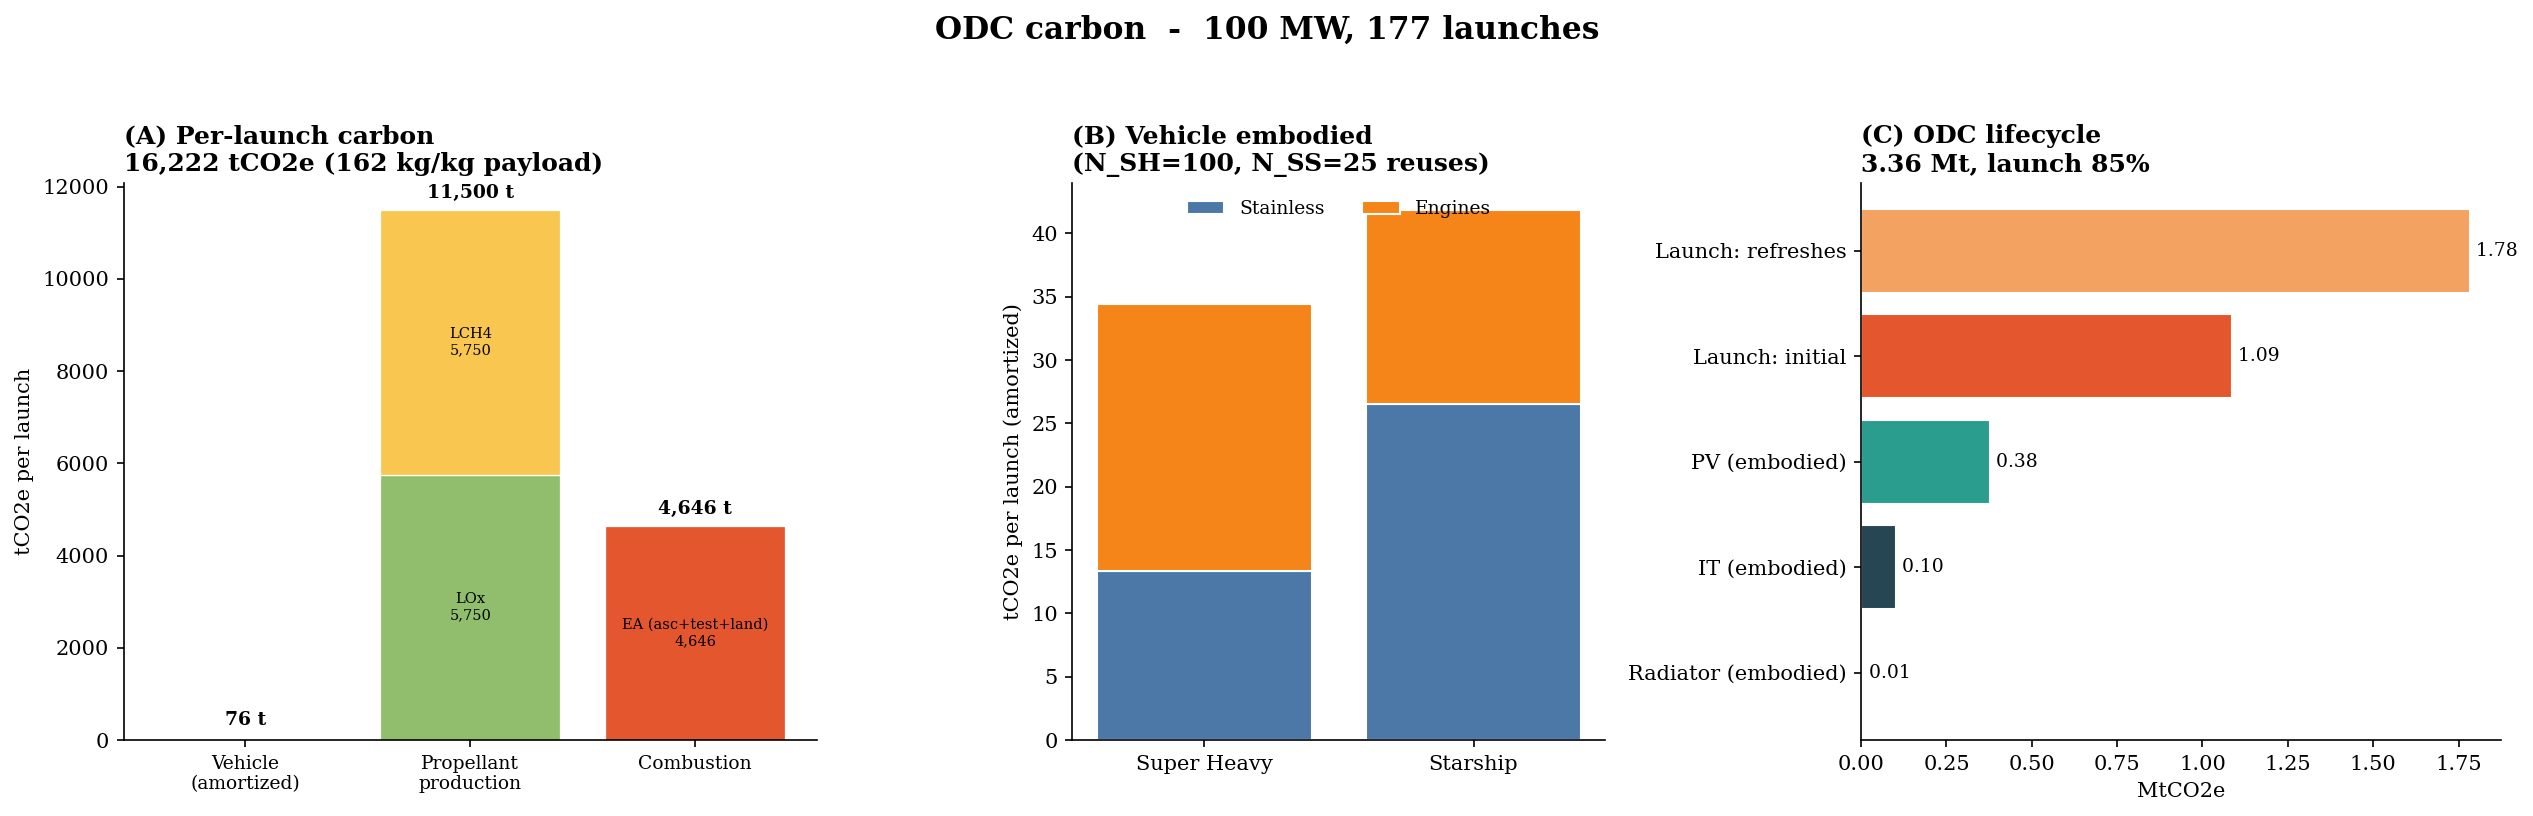

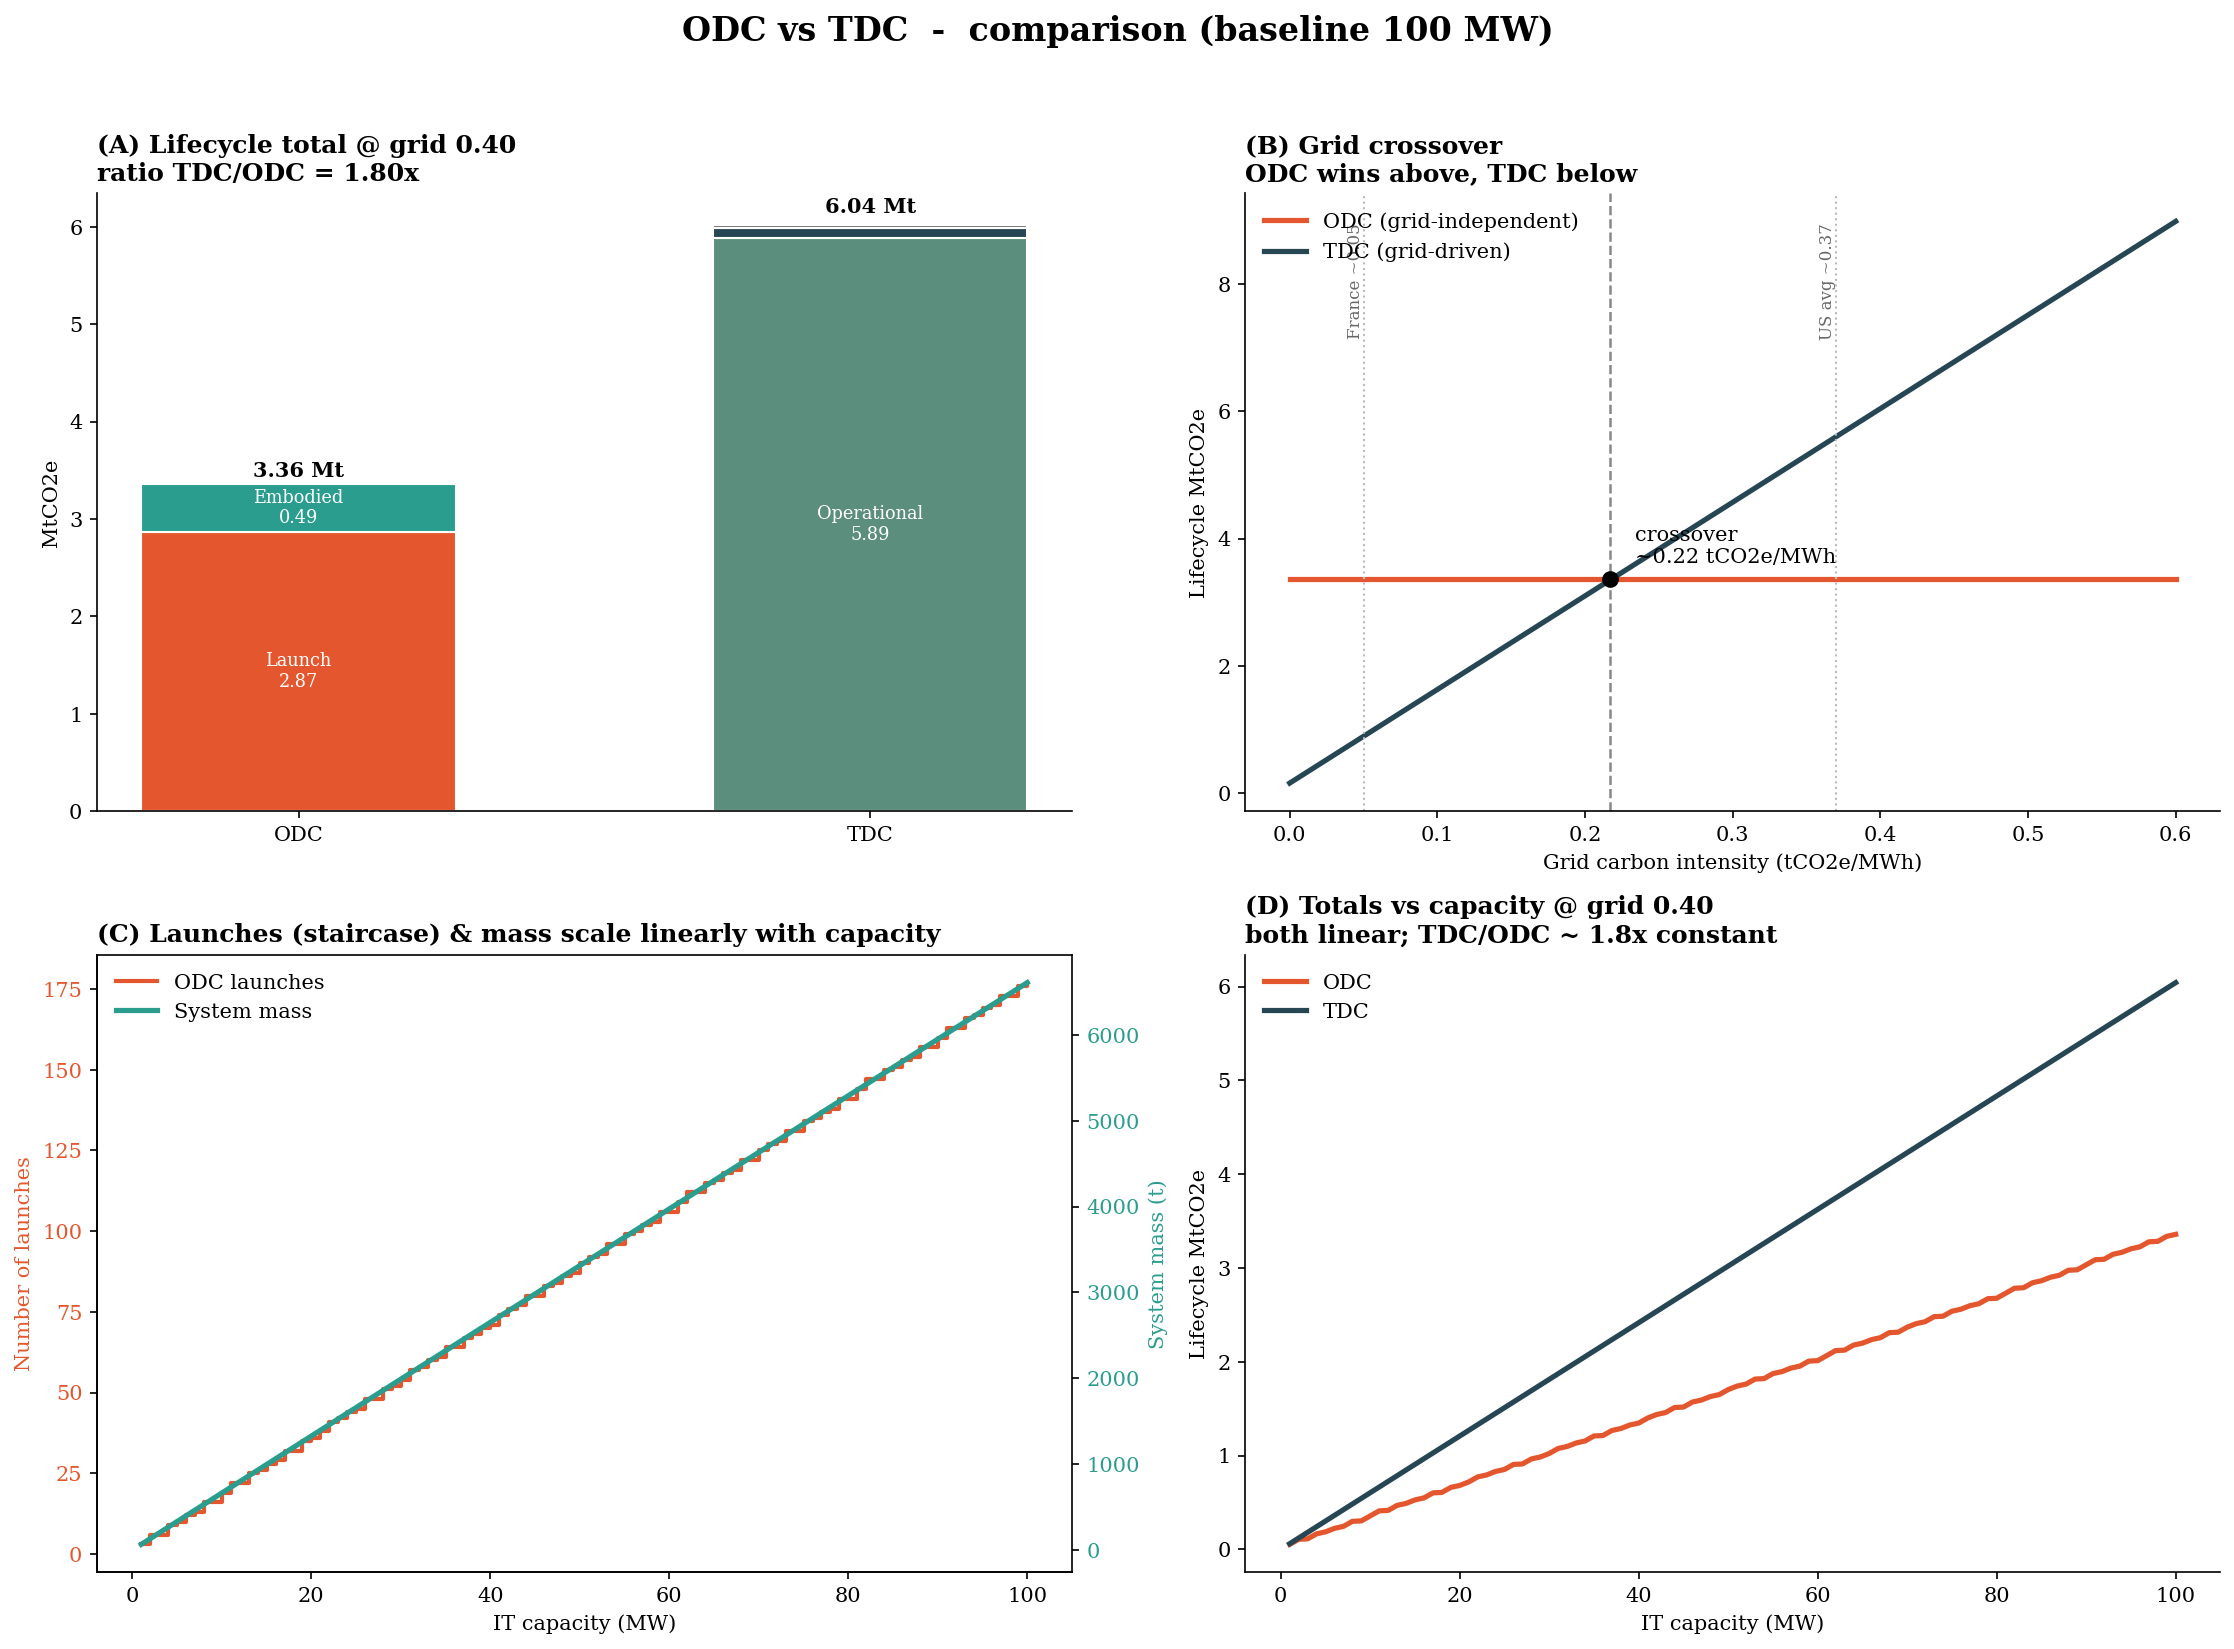

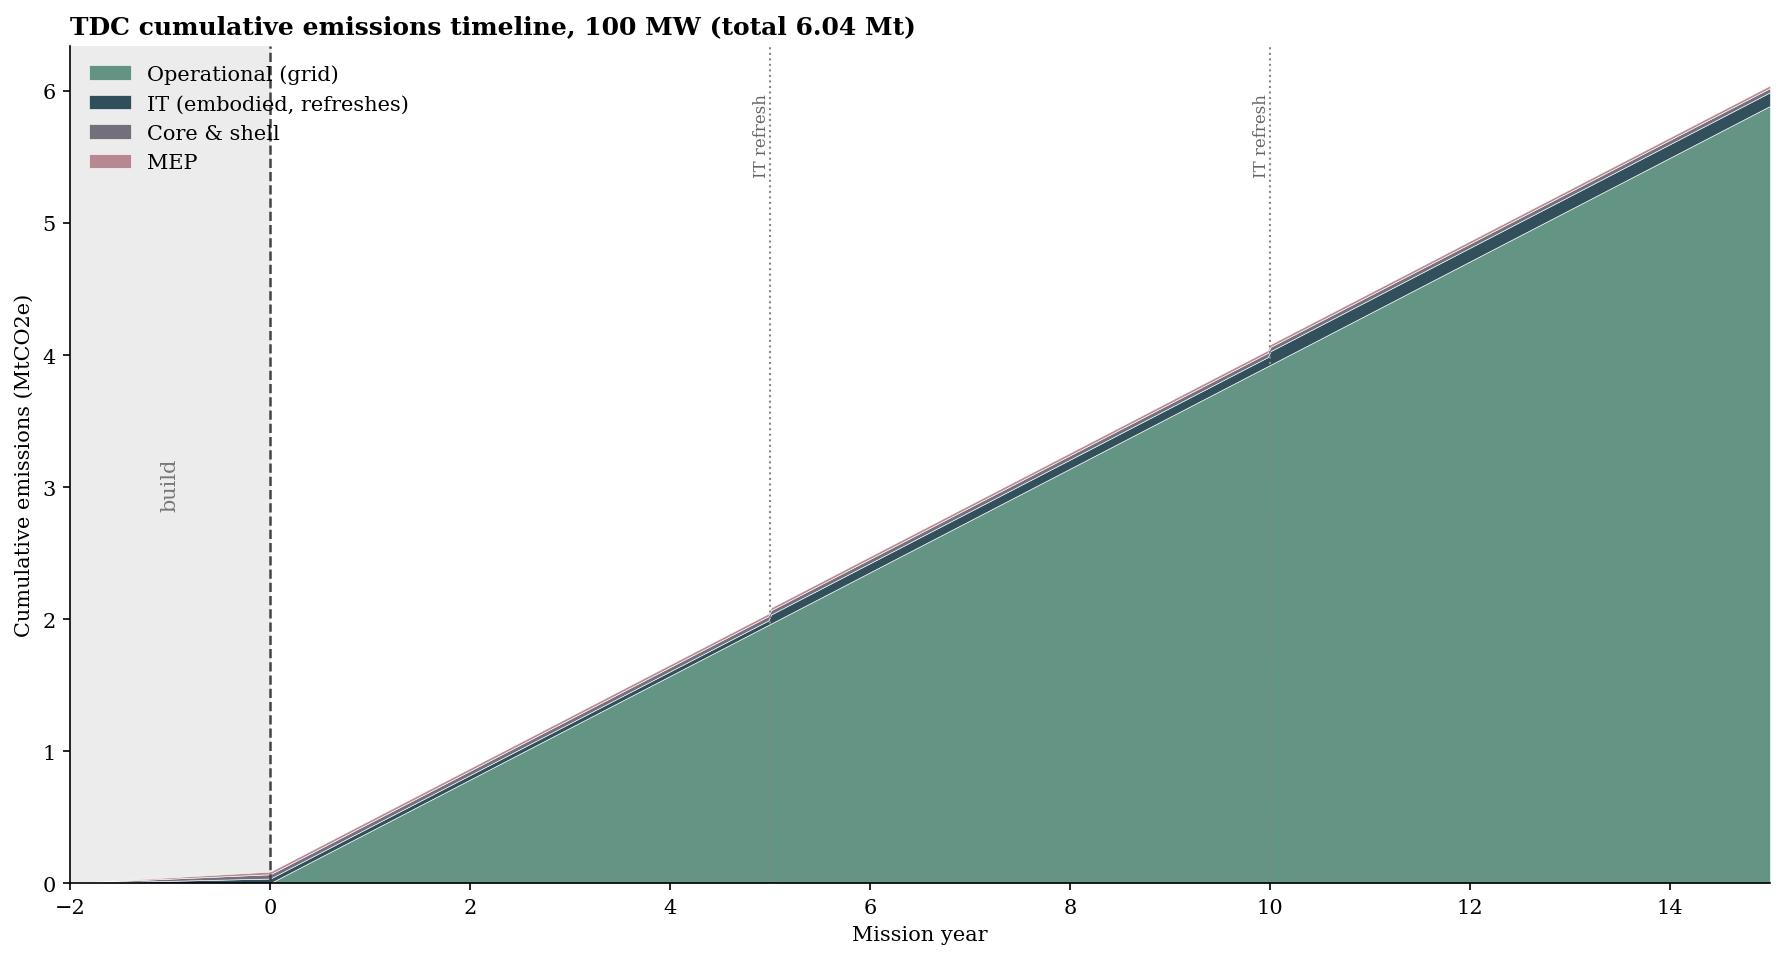

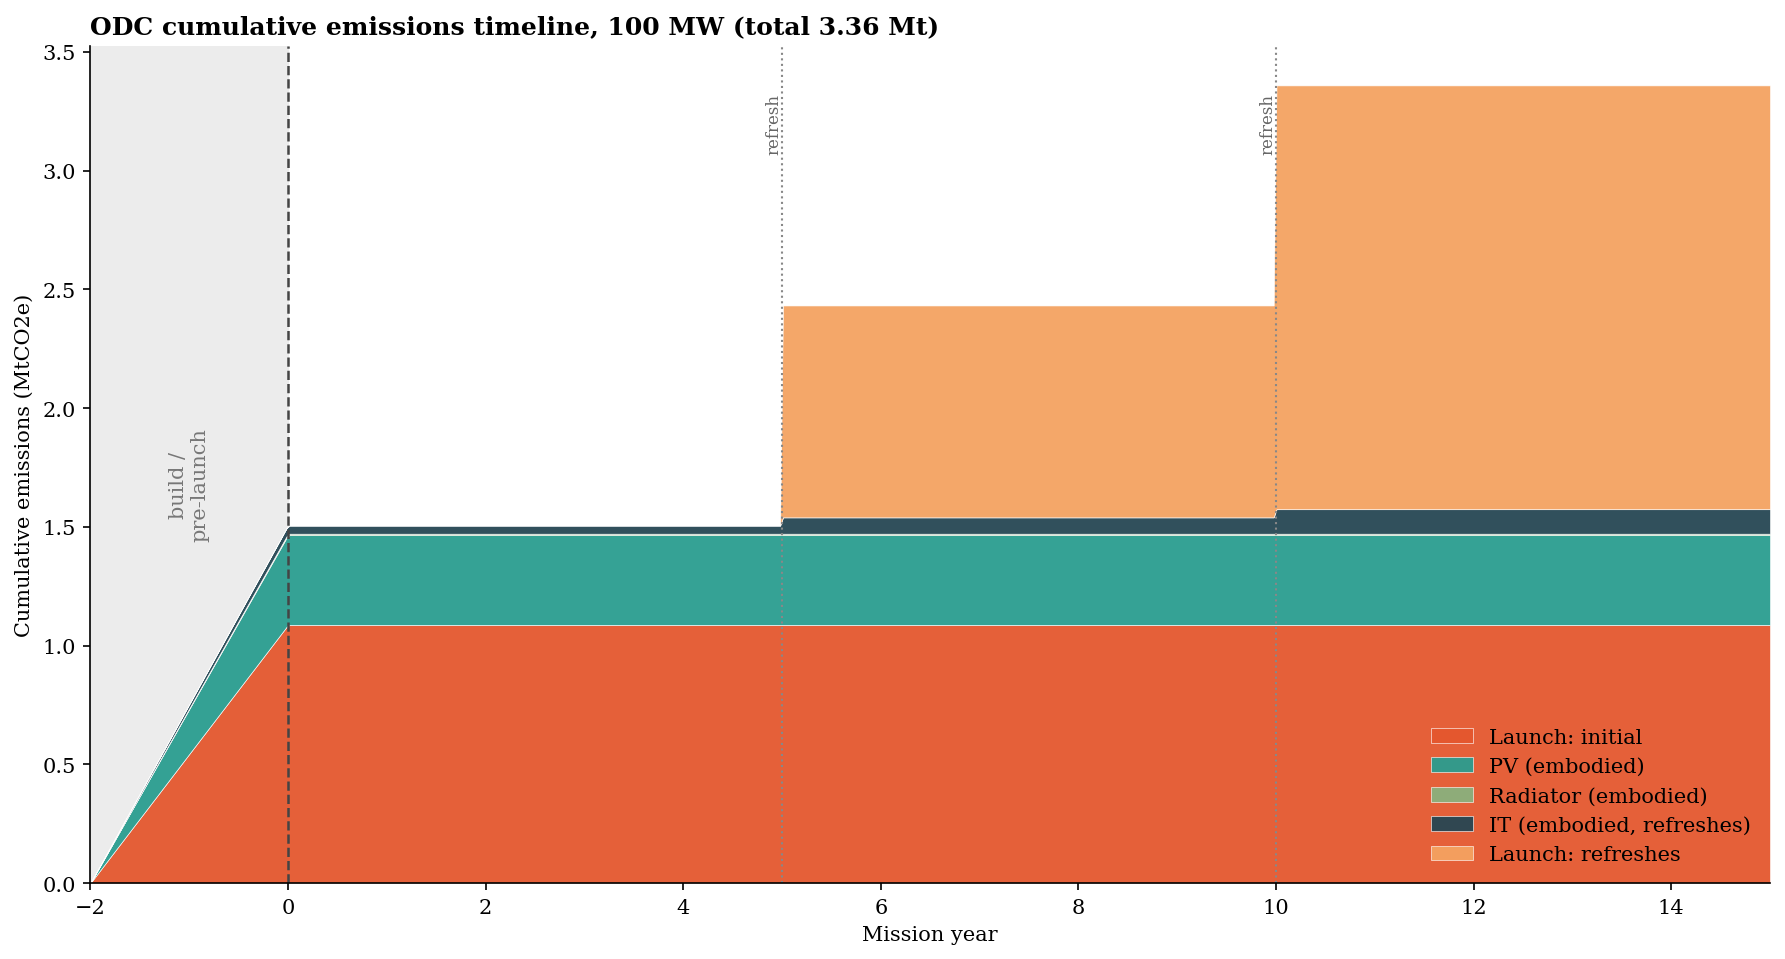

In [15]:
import os
import math
from dataclasses import dataclass, replace

import numpy as np
from scipy.optimize import brentq
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ================================================================================
# ODC vs TDC -- end-to-end life-cycle carbon model (GWP100)
# Set CAPACITY_MW below; everything else sizes off it.
#
# NOTE: dataclass + sizing functions are namespaced (CarbonScenario, c_size_*,
# c_mass_budget) so they do NOT clobber the financial-model Scenario / size_* /
# mass_budget defined earlier in the notebook. Both models stay live together.
#
# Sources: Alissa et al. 2025 Nature 641:331 (facility LCA); Falk et al. 2025
# arXiv:2509.00093 + NVIDIA HGX B200 PCF (IT embodied); Miraux 2022 (Starship
# vehicle/propellant); IAI 2023 (aluminium); Swart 2011 + Mohr 2007 (PV);
# BaSO4 coating + IAI (radiator). Author sizing model for PV/radiator geometry.
# ================================================================================

CAPACITY_MW = 100.0          # DEFAULT DC IT capacity

# ----------------------------------------------------------------- constants --
I_SUN         = 1361.0       # solar constant [W/m^2]
SIGMA         = 5.670374419e-8
T_EARTH_EFF   = 254.15       # Earth effective radiating temp [K] (NASA)
EARTH_ALBEDO  = 0.306        # (NASA)
FOOTBALL_M2   = 5350.0       # for human-scale prints

os.makedirs("carbon_figs", exist_ok=True)


# ================================================================== scenario ==
@dataclass
class CarbonScenario:
    # capacity / mission
    it_capacity_mw: float = CAPACITY_MW
    mission_years:  int   = 15
    it_refresh_years: int = 5

    # --- PV array ---
    pv_eff_BOL:   float = 0.32      # triple-junction GaAs BOL efficiency
    pv_derating:  float = 0.85      # wiring/mismatch/soiling-equivalent (PVWatts)
    pv_areal_mass: float = 1.76     # kg/m^2 (Spectrolab stack)
    pv_kgco2e_m2: float = 1400.0    # embodied, central (Swart 2011 + Mohr 2007)

    # --- radiator (single horizontal beam, double-sided) ---
    T_rad_C:        float = 80.0
    T_PV_C:         float = 31.1    # PV temp from radiative energy balance (consistent w/ main model)
    L_rad:          float = 300.0   # fixed beam length [m]; width solved for
    eps_IR:         float = 0.95
    eps_PV_back:    float = 0.84
    alpha_solar_rad: float = 0.05
    F_earth:        float = 0.10
    rad_areal_mass: float = 9.2     # kg/m^2 (BaSO4 coat 4.5 + Al 4.7)
    rad_kgco2e_m2:  float = 86.0    # embodied, central

    # --- IT (shared by ODC and TDC for apples-to-apples) ---
    it_mass_density:    float = 55_000.0   # kg/MW
    node_power_kw:      float = 10.4
    gpu_baseboard_kgco2e: float = 2274.0   # HGX B200 PCF
    host_server_kgco2e:   float = 1300.0

    # --- TDC facility / operation ---
    pue:              float = 1.12
    load_factor:      float = 1.0
    grid_intensity:   float = 0.40   # tCO2e/MWh == kgCO2e/kWh
    grid_decarb:      float = 0.0
    power_density_kw_m2: float = 2.0
    shell_kgco2e_m2:  float = 650.0
    mep_kgco2e_m2:    float = 400.0

    # --- ODC launch vehicle (Starship; Miraux 2022) ---
    sh_dry_t:    float = 275.0
    ss_dry_t:    float = 120.0
    n_raptor_sh: int   = 33
    n_raptor_ss: int   = 6
    raptor_mass_t: float = 1.6
    propellant_t: float = 4600.0
    o_f_ratio:   float = 3.6
    payload_cap_t: float = 100.0     # payload to LEO per launch
    n_sh_reuse:  float = 100.0
    n_ss_reuse:  float = 25.0
    ci_steel:    float = 6.0         # kgCO2e/kg stainless
    ci_engine:   float = 40.0        # kgCO2e/kg Ni-superalloy
    ci_prop_prod: float = 2.5        # kgCO2e/kg methalox (LOx+LCH4 production)
    combustion_ea_t: float = 4646.0  # tCO2e/launch (FAA EA; ascent+tests+landing)
    include_reentry: bool = False    # reused vehicle -> ~0 per delivery


def c_q_compute(s: CarbonScenario) -> float:
    """Compute heat / power load [W]."""
    return s.it_capacity_mw * 1e6


# ============================================================ physical sizing ==
def F_perp_adjacent(h: float, w: float) -> float:
    """View factor: horizontal W x L plate -> perpendicular L x H plate sharing edge L.
    h = H/L, w = W/L. Howell/Siegel adjacent perpendicular rectangles.
    Verified: F_perp_adjacent(1, 1) ~ 0.20004."""
    H2W2 = h**2 + w**2
    a = ((1 + h**2) * (1 + w**2)) / (1 + H2W2)
    b = (w**2 * (1 + H2W2)) / ((1 + w**2) * H2W2)
    c = (h**2 * (1 + H2W2)) / ((1 + h**2) * H2W2)
    term = (h * np.arctan(1/h) + w * np.arctan(1/w)
            - np.sqrt(H2W2) * np.arctan(1/np.sqrt(H2W2))
            + 0.25 * np.log(a * b**(w**2) * c**(h**2)))
    return term / (np.pi * w)


def c_size_pv_array(s: CarbonScenario) -> float:
    return c_q_compute(s) / (s.pv_eff_BOL * s.pv_derating * I_SUN)


def c_size_radiator(s: CarbonScenario, verbose: bool = False) -> float:
    """Self-consistent radiator area for a single horizontal beam (double-sided).
    L = s.L_rad fixed; brentq solves width ratio w = W/L."""
    T_r  = s.T_rad_C + 273.15
    T_PV = s.T_PV_C  + 273.15
    A_PV = c_size_pv_array(s)
    H    = A_PV / (2 * s.L_rad)
    h    = H / s.L_rad
    L    = s.L_rad
    Q    = c_q_compute(s)

    def q_net(w):
        F_pv = F_perp_adjacent(h, w)
        q_ir = (2*s.eps_IR*SIGMA*T_r**4
                - 2*s.eps_IR*s.eps_PV_back*F_pv*SIGMA*T_PV**4
                - s.eps_IR*SIGMA*T_EARTH_EFF**4*s.F_earth)
        q_alb = s.alpha_solar_rad * EARTH_ALBEDO * I_SUN * s.F_earth
        return q_ir - q_alb

    resid = lambda w: q_net(w) * (w * L**2) - Q
    w_star = brentq(resid, 1e-4, 1e4)
    A_rad  = w_star * L**2

    if verbose:
        q = q_net(w_star); F_pv = F_perp_adjacent(h, w_star)
        print(f'  Geometry: L={L:.0f} m, H={H:.1f} m, h={h:.3f}, '
              f'W={w_star*L:.1f} m (w={w_star:.4f})')
        print(f'  F_PV (per face): {F_pv:.4f}   Net cooling: {q:.1f} W/m^2')
    return A_rad


def c_mass_budget(s: CarbonScenario) -> dict:
    A_PV  = c_size_pv_array(s)
    A_rad = c_size_radiator(s)
    m_PV  = A_PV  * s.pv_areal_mass
    m_rad = A_rad * s.rad_areal_mass
    m_IT  = s.it_capacity_mw * s.it_mass_density
    return {'A_PV': A_PV, 'A_rad': A_rad,
            'PV': m_PV, 'Radiator': m_rad, 'IT': m_IT,
            'Total': m_PV + m_rad + m_IT}


# ================================================================ IT helpers ==
def it_quantities(s: CarbonScenario) -> dict:
    nodes = s.it_capacity_mw * 1000.0 / s.node_power_kw
    gens  = math.ceil(s.mission_years / s.it_refresh_years)
    per_gen_t = nodes * (s.gpu_baseboard_kgco2e + s.host_server_kgco2e) / 1000.0
    return {'nodes': nodes, 'generations': gens,
            'per_gen_t': per_gen_t, 'all_gens_t': per_gen_t * gens}


# =================================================================== TDC model ==
def tdc_carbon(s: CarbonScenario) -> dict:
    it = it_quantities(s)
    area = s.it_capacity_mw * 1000.0 / s.power_density_kw_m2
    shell = area * s.shell_kgco2e_m2 / 1000.0
    mep   = area * s.mep_kgco2e_m2   / 1000.0

    yrs = list(range(s.mission_years))
    emb = [0.0]*s.mission_years
    op  = [0.0]*s.mission_years
    emb[0] += shell + mep
    for g in range(it['generations']):
        yr = g*s.it_refresh_years
        if yr < s.mission_years:
            emb[yr] += it['per_gen_t']
    annual_mwh = s.it_capacity_mw * s.pue * s.load_factor * 8760.0
    for y in yrs:
        gi = s.grid_intensity * (1 - s.grid_decarb)**y
        op[y] = annual_mwh * gi

    emb_total = sum(emb); op_total = sum(op)
    return {
        'breakdown': {'IT (all gens)': it['all_gens_t'],
                      'Core & shell': shell, 'MEP': mep},
        'embodied_total': emb_total, 'operational_total': op_total,
        'total': emb_total + op_total,
        'floor_area_m2': area,
        'profile': {'years': yrs, 'embodied_spike': emb, 'operational': op,
                    'cum_embodied': np.cumsum(emb).tolist(),
                    'cum_operational': np.cumsum(op).tolist(),
                    'cum_total': np.cumsum(np.array(emb)+np.array(op)).tolist()},
    }


# =================================================================== ODC model ==
def odc_per_launch(s: CarbonScenario) -> dict:
    """Per-launch carbon terms for a reused delivery vehicle [tCO2e]."""
    eng_sh = s.n_raptor_sh * s.raptor_mass_t
    eng_ss = s.n_raptor_ss * s.raptor_mass_t
    emb_sh = (s.sh_dry_t - eng_sh)*s.ci_steel + eng_sh*s.ci_engine
    emb_ss = (s.ss_dry_t - eng_ss)*s.ci_steel + eng_ss*s.ci_engine
    vehicle = emb_sh/s.n_sh_reuse + emb_ss/s.n_ss_reuse
    prop = s.ci_prop_prod * s.propellant_t
    comb = s.combustion_ea_t
    terms = {'Vehicle (amortized)': vehicle,
             'Propellant production': prop,
             'Combustion': comb}
    if s.include_reentry:
        terms['Re-entry'] = 13.2 * s.payload_cap_t  # NOx
    detail = {
        'sh_struct': (s.sh_dry_t-eng_sh)*s.ci_steel/s.n_sh_reuse,
        'sh_eng':    eng_sh*s.ci_engine/s.n_sh_reuse,
        'ss_struct': (s.ss_dry_t-eng_ss)*s.ci_steel/s.n_ss_reuse,
        'ss_eng':    eng_ss*s.ci_engine/s.n_ss_reuse,
        'lox':  prop*0.5, 'methane': prop*0.5,
    }
    return {'terms': terms, 'per_launch_t': sum(terms.values()), 'detail': detail}


def odc_hardware_embodied(s: CarbonScenario) -> dict:
    it = it_quantities(s)
    A_PV  = c_size_pv_array(s)
    A_rad = c_size_radiator(s)
    return {'IT (all gens)': it['all_gens_t'],
            'PV array':      A_PV  * s.pv_kgco2e_m2  / 1000.0,
            'Radiator':      A_rad * s.rad_kgco2e_m2 / 1000.0}


def odc_carbon(s: CarbonScenario) -> dict:
    it = it_quantities(s)
    mb = c_mass_budget(s)
    pl = odc_per_launch(s)
    per_launch = pl['per_launch_t']

    it_mass = mb['IT']/1000.0  # tonnes
    cap = s.payload_cap_t

    n_init    = math.ceil(mb['Total']/1000.0 / cap)
    n_refresh_each = math.ceil(it_mass / cap)
    n_refresh_events = it['generations'] - 1
    n_launches = n_init + n_refresh_each*n_refresh_events

    launch_initial   = n_init * per_launch
    launch_refresh   = n_refresh_each * n_refresh_events * per_launch
    launch_total     = launch_initial + launch_refresh

    emb = odc_hardware_embodied(s)
    emb_total = sum(emb.values())

    yrs = list(range(s.mission_years))
    emb_spike = [0.0]*s.mission_years
    lau_spike = [0.0]*s.mission_years
    emb_spike[0] += emb['PV array'] + emb['Radiator']
    lau_spike[0] += launch_initial
    for g in range(it['generations']):
        yr = g*s.it_refresh_years
        if yr < s.mission_years:
            emb_spike[yr] += it['per_gen_t']
            if g > 0:
                lau_spike[yr] += n_refresh_each*per_launch
    cum_total = np.cumsum(np.array(emb_spike)+np.array(lau_spike)).tolist()

    return {
        'breakdown': emb,
        'launch_initial': launch_initial, 'launch_refresh': launch_refresh,
        'launch_total': launch_total, 'embodied_total': emb_total,
        'total': launch_total + emb_total,
        'n_launches': n_launches, 'n_init': n_init,
        'per_launch_t': per_launch, 'per_launch_detail': pl,
        'mass_budget': mb,
        'profile': {'years': yrs, 'embodied_spike': emb_spike,
                    'launch_spike': lau_spike, 'cum_total': cum_total},
    }


# ============================================================== visualization ==
PAL = {"it": "#264653", "shell": "#6D6875", "mep": "#B5838D", "op": "#5B8E7D",
       "launch": "#E4572E", "launch2": "#F4A261", "pv": "#2A9D8F",
       "rad": "#8AB17D", "odc": "#E4572E", "tdc": "#264653",
       "steel": "#4C78A8", "engine": "#F58518", "lox": "#90BE6D", "ch4": "#F9C74F"}


def _despine(ax): sns.despine(ax=ax)


def plot_tdc(s: CarbonScenario, tdc: dict, fname="carbon_figs/tdc_carbon.png"):
    p = tdc['profile']; yrs = np.array(p['years'])
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
    items = sorted(tdc['breakdown'].items(), key=lambda x: x[1], reverse=True)
    cols = {'IT (all gens)': PAL['it'], 'Core & shell': PAL['shell'], 'MEP': PAL['mep']}
    ax1.bar([k for k,_ in items], [v/1000 for _,v in items],
            color=[cols[k] for k,_ in items], edgecolor="white")
    ax1.set_ylabel("ktCO2e"); ax1.set_title("(A) TDC embodied by subsystem", loc="left", fontweight="bold")
    for i,(k,v) in enumerate(items):
        ax1.text(i, v/1000, f"{v/1000:,.0f}", ha="center", va="bottom", fontsize=10)
    ax1.tick_params(axis='x', rotation=12); _despine(ax1)
    ax2.plot(yrs, np.array(p['cum_embodied'])/1000, "-o", color=PAL['it'], ms=5, label="Embodied")
    ax2.plot(yrs, np.array(p['cum_operational'])/1000, "-s", color=PAL['op'], ms=5, label="Operational")
    ax2.set_xlabel("Mission year"); ax2.set_ylabel("Cumulative ktCO2e")
    es = tdc['embodied_total']/tdc['total']; os_ = tdc['operational_total']/tdc['total']
    ax2.set_title(f"(B) Operational {os_:.0%} vs embodied {es:.0%}\n"
                  f"grid {s.grid_intensity:.2f} tCO2e/MWh", loc="left", fontweight="bold")
    ax2.legend(frameon=False, loc="upper left"); _despine(ax2)
    fig.suptitle(f"TDC carbon  -  {s.it_capacity_mw:g} MW, {s.mission_years} yr  "
                 f"(total {tdc['total']/1e6:.2f} MtCO2e)", fontsize=15, fontweight="bold")
    fig.tight_layout(rect=[0,0,1,0.95]); fig.savefig(fname, dpi=150, bbox_inches="tight")
    return fig


def plot_odc(s: CarbonScenario, odc: dict, fname="carbon_figs/odc_carbon.png"):
    d = odc['per_launch_detail']['detail']; pl = odc['per_launch_t']
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 5.5),
                                        gridspec_kw={"width_ratios":[1.3,1,1.2]})
    stages = {
        "Vehicle\n(amortized)": [("SH struct", d['sh_struct'], PAL['steel']),
                                 ("SH engines", d['sh_eng'], PAL['engine']),
                                 ("SS struct", d['ss_struct'], PAL['steel']),
                                 ("SS engines", d['ss_eng'], PAL['engine'])],
        "Propellant\nproduction": [("LOx", d['lox'], PAL['lox']),
                                   ("LCH4", d['methane'], PAL['ch4'])],
        "Combustion": [("EA (asc+test+land)", s.combustion_ea_t, PAL['launch'])],
    }
    xs = list(range(len(stages))); ymax = pl
    for i,(name, segs) in enumerate(stages.items()):
        bottom=0
        for lab,val,col in segs:
            ax1.bar(i, val, bottom=bottom, color=col, edgecolor="white", linewidth=0.6)
            if val > 0.03*ymax:
                ax1.text(i, bottom+val/2, f"{lab}\n{val:,.0f}", ha="center", va="center", fontsize=7)
            bottom+=val
        ax1.text(i, bottom+0.01*ymax, f"{bottom:,.0f} t", ha="center", va="bottom",
                 fontsize=9, fontweight="bold")
    ax1.set_xticks(xs); ax1.set_xticklabels(list(stages.keys()), fontsize=9)
    ax1.set_ylabel("tCO2e per launch")
    ax1.set_title(f"(A) Per-launch carbon\n{pl:,.0f} tCO2e ({pl/s.payload_cap_t:,.0f} kg/kg payload)",
                  loc="left", fontweight="bold"); _despine(ax1)
    labels=["Super Heavy","Starship"]; struct=[d['sh_struct'],d['ss_struct']]; eng=[d['sh_eng'],d['ss_eng']]
    x=np.arange(2)
    ax2.bar(x, struct, color=PAL['steel'], edgecolor="white", label="Stainless")
    ax2.bar(x, eng, bottom=struct, color=PAL['engine'], edgecolor="white", label="Engines")
    ax2.set_xticks(x); ax2.set_xticklabels(labels)
    ax2.set_ylabel("tCO2e per launch (amortized)")
    ax2.set_title(f"(B) Vehicle embodied\n(N_SH={s.n_sh_reuse:.0f}, N_SS={s.n_ss_reuse:.0f} reuses)",
                  loc="left", fontweight="bold")
    ax2.legend(frameon=False, fontsize=9, loc="upper center", ncol=2); _despine(ax2)
    comp = [("Launch: initial", odc['launch_initial'], PAL['launch']),
            ("Launch: refreshes", odc['launch_refresh'], PAL['launch2']),
            ("PV (embodied)", odc['breakdown']['PV array'], PAL['pv']),
            ("IT (embodied)", odc['breakdown']['IT (all gens)'], PAL['it']),
            ("Radiator (embodied)", odc['breakdown']['Radiator'], PAL['rad'])]
    comp.sort(key=lambda x:x[1], reverse=True)
    ax3.barh([c[0] for c in comp], [c[1]/1e6 for c in comp],
             color=[c[2] for c in comp], edgecolor="white")
    ax3.invert_yaxis(); ax3.set_xlabel("MtCO2e")
    ax3.set_title(f"(C) ODC lifecycle\n{odc['total']/1e6:.2f} Mt, "
                  f"launch {100*odc['launch_total']/odc['total']:.0f}%",
                  loc="left", fontweight="bold")
    for i,c in enumerate(comp):
        ax3.text(c[1]/1e6, i, f" {c[1]/1e6:.2f}", va="center", fontsize=9)
    _despine(ax3)
    fig.suptitle(f"ODC carbon  -  {s.it_capacity_mw:g} MW, {odc['n_launches']:.0f} launches",
                 fontsize=15, fontweight="bold")
    fig.tight_layout(rect=[0,0,1,0.94]); fig.savefig(fname, dpi=150, bbox_inches="tight")
    return fig


def plot_comparison(s: CarbonScenario, fname="carbon_figs/comparison.png"):
    odc = odc_carbon(s); tdc = tdc_carbon(s)
    fig, ((axA, axB), (axC, axD)) = plt.subplots(2, 2, figsize=(15, 11))
    for x, stack in [(0, [("Launch", odc['launch_total'], PAL['launch']),
                          ("Embodied", odc['embodied_total'], PAL['pv'])]),
                     (1, [("Operational", tdc['operational_total'], PAL['op']),
                          ("IT embodied", tdc['breakdown']['IT (all gens)'], PAL['it']),
                          ("Core & shell", tdc['breakdown']['Core & shell'], PAL['shell']),
                          ("MEP", tdc['breakdown']['MEP'], PAL['mep'])])]:
        bottom=0
        for name,val,col in stack:
            axA.bar(x, val/1e6, bottom=bottom/1e6, color=col, edgecolor="white", width=0.55)
            if val/1e6 > 0.04*max(odc['total'],tdc['total'])/1e6:
                axA.text(x,(bottom+val/2)/1e6, f"{name}\n{val/1e6:.2f}", ha="center", va="center",
                         fontsize=8.5, color="white")
            bottom+=val
        axA.text(x, bottom/1e6*1.01, f"{bottom/1e6:.2f} Mt", ha="center", va="bottom", fontweight="bold")
    axA.set_xticks([0,1]); axA.set_xticklabels(["ODC","TDC"]); axA.set_ylabel("MtCO2e")
    axA.set_title(f"(A) Lifecycle total @ grid {s.grid_intensity:.2f}\n"
                  f"ratio TDC/ODC = {tdc['total']/odc['total']:.2f}x", loc="left", fontweight="bold")
    _despine(axA)
    grid = np.linspace(0, 0.6, 120)
    tdc_curve = np.array([tdc_carbon(replace(s, grid_intensity=g))['total']
                          for g in grid]) / 1e6
    odc_flat = np.full_like(grid, odc['total']/1e6)
    axB.plot(grid, odc_flat, color=PAL['odc'], lw=2.5, label="ODC (grid-independent)")
    axB.plot(grid, tdc_curve, color=PAL['tdc'], lw=2.5, label="TDC (grid-driven)")
    ix = int(np.argmin(np.abs(tdc_curve - odc_flat))); gx = grid[ix]
    axB.axvline(gx, color="#888", ls="--", lw=1.2)
    axB.plot(gx, odc['total']/1e6, "o", color="k", ms=7, zorder=5)
    axB.annotate(f"crossover\n~{gx:.2f} tCO2e/MWh", (gx, odc['total']/1e6),
                 textcoords="offset points", xytext=(12,8), fontsize=10)
    for lab,gv in [("France ~0.05",0.05),("US avg ~0.37",0.37)]:
        axB.axvline(gv, color="#bbb", ls=":", lw=1)
        axB.text(gv, axB.get_ylim()[1]*0.95, lab, rotation=90, va="top", ha="right",
                 fontsize=8, color="#666")
    axB.set_xlabel("Grid carbon intensity (tCO2e/MWh)"); axB.set_ylabel("Lifecycle MtCO2e")
    axB.set_title("(B) Grid crossover\nODC wins above, TDC below", loc="left", fontweight="bold")
    axB.legend(frameon=False, loc="upper left"); _despine(axB)
    caps = np.arange(1, 101, dtype=float)
    n_launch=[]; mass_t=[]; odc_tot=[]; tdc_tot=[]
    for c in caps:
        sc = replace(s, it_capacity_mw=c)
        oc = odc_carbon(sc); tc = tdc_carbon(sc)
        n_launch.append(oc['n_launches']); mass_t.append(oc['mass_budget']['Total']/1000.0)
        odc_tot.append(oc['total']/1e6); tdc_tot.append(tc['total']/1e6)
    lC = axC.plot(caps, n_launch, color=PAL['launch'], lw=2, drawstyle="steps-post",
                  label="ODC launches")
    axC.set_xlabel("IT capacity (MW)"); axC.set_ylabel("Number of launches", color=PAL['launch'])
    axC.tick_params(axis='y', labelcolor=PAL['launch'])
    axC2 = axC.twinx()
    lC2 = axC2.plot(caps, mass_t, color=PAL['pv'], lw=2.5, label="System mass")
    axC2.set_ylabel("System mass (t)", color=PAL['pv']); axC2.tick_params(axis='y', labelcolor=PAL['pv'])
    axC2.grid(False)
    axC.set_title("(C) Launches (staircase) & mass scale linearly with capacity",
                  loc="left", fontweight="bold")
    axC.legend(lC + lC2, [l.get_label() for l in lC + lC2], frameon=False,
               loc="upper left", fontsize=10)
    _despine(axC)
    axD.plot(caps, odc_tot, color=PAL['odc'], lw=2.5, label="ODC")
    axD.plot(caps, tdc_tot, color=PAL['tdc'], lw=2.5, label="TDC")
    axD.set_xlabel("IT capacity (MW)"); axD.set_ylabel("Lifecycle MtCO2e")
    axD.set_title(f"(D) Totals vs capacity @ grid {s.grid_intensity:.2f}\n"
                  f"both linear; TDC/ODC ~ {tdc_tot[-1]/odc_tot[-1]:.1f}x constant",
                  loc="left", fontweight="bold")
    axD.legend(frameon=False, loc="upper left"); _despine(axD)
    fig.suptitle(f"ODC vs TDC  -  comparison (baseline {s.it_capacity_mw:g} MW)",
                 fontsize=16, fontweight="bold", y=0.995)
    fig.tight_layout(rect=[0,0,1,0.97]); fig.savefig(fname, dpi=150, bbox_inches="tight")
    return fig


# ----------------------------------------------------- emissions timelines ----
def _ramp(t, value, t0=-2.0, t1=0.0):
    return value * np.clip((t - t0) / (t1 - t0), 0.0, 1.0)


def _step(t, value, t_event):
    return np.where(t >= t_event, value, 0.0)


def plot_timeline_odc(s: CarbonScenario, odc: dict, fname="carbon_figs/odc_timeline.png"):
    t = np.linspace(-2, s.mission_years, 600)
    it = it_quantities(s)
    per_gen = it['per_gen_t']
    n_ref_each = math.ceil((odc['mass_budget']['IT']/1000.0) / s.payload_cap_t)
    ref_launch = n_ref_each * odc['per_launch_t']
    refresh_yrs = [g*s.it_refresh_years for g in range(1, it['generations'])
                   if g*s.it_refresh_years < s.mission_years]
    launch_init = _ramp(t, odc['launch_initial'])
    pv  = _ramp(t, odc['breakdown']['PV array'])
    rad = _ramp(t, odc['breakdown']['Radiator'])
    it_cum = _ramp(t, per_gen) + sum(_step(t, per_gen, ry) for ry in refresh_yrs)
    lref   = sum(_step(t, ref_launch, ry) for ry in refresh_yrs)
    bands = [("Launch: initial", launch_init, PAL['launch']),
             ("PV (embodied)",   pv,  PAL['pv']),
             ("Radiator (embodied)", rad, PAL['rad']),
             ("IT (embodied, refreshes)", it_cum, PAL['it']),
             ("Launch: refreshes", lref, PAL['launch2'])]
    Y = np.vstack([b[1] for b in bands]) / 1e6
    total_top = Y.sum(axis=0)
    fig, ax = plt.subplots(figsize=(12, 6.5))
    ax.stackplot(t, Y, labels=[b[0] for b in bands],
                 colors=[b[2] for b in bands], alpha=0.95, edgecolor="white", lw=0.3)
    ax.axvspan(-2, 0, color="#ECECEC", zorder=0)
    ax.axvline(0, color="#444", lw=1.2, ls="--")
    ymax = total_top.max()
    ax.text(-1.0, ymax*0.5, "build /\npre-launch", ha="center", va="center",
            fontsize=10, color="#777", rotation=90)
    for ry in refresh_yrs:
        ax.axvline(ry, color="#888", ls=":", lw=1)
        ax.text(ry, ymax*0.99, "refresh", rotation=90, fontsize=8,
                color="#666", va="top", ha="right")
    ax.set_xlim(-2, s.mission_years); ax.set_ylim(0, ymax*1.05)
    ax.set_xlabel("Mission year"); ax.set_ylabel("Cumulative emissions (MtCO2e)")
    ax.set_title(f"ODC cumulative emissions timeline, {s.it_capacity_mw:g} MW "
                 f"(total {odc['total']/1e6:.2f} Mt)", fontweight="bold", loc="left")
    ax.legend(loc="lower right", frameon=False, fontsize=10)
    _despine(ax)
    fig.tight_layout(); fig.savefig(fname, dpi=150, bbox_inches="tight")
    return fig


def plot_timeline_tdc(s: CarbonScenario, tdc: dict, fname="carbon_figs/tdc_timeline.png"):
    t = np.linspace(-2, s.mission_years, 600)
    it = it_quantities(s)
    per_gen = it['per_gen_t']
    shell = tdc['breakdown']['Core & shell']; mep = tdc['breakdown']['MEP']
    op_total = tdc['operational_total']
    refresh_yrs = [g*s.it_refresh_years for g in range(1, it['generations'])
                   if g*s.it_refresh_years < s.mission_years]
    op_c    = np.where(t <= 0, 0.0, np.clip(t, 0, None)/s.mission_years * op_total)
    it_cum  = _ramp(t, per_gen) + sum(_step(t, per_gen, ry) for ry in refresh_yrs)
    shell_c = _ramp(t, shell)
    mep_c   = _ramp(t, mep)
    bands = [("Operational (grid)", op_c, PAL['op']),
             ("IT (embodied, refreshes)", it_cum, PAL['it']),
             ("Core & shell", shell_c, PAL['shell']),
             ("MEP", mep_c, PAL['mep'])]
    Y = np.vstack([b[1] for b in bands]) / 1e6
    total_top = Y.sum(axis=0)
    fig, ax = plt.subplots(figsize=(12, 6.5))
    ax.stackplot(t, Y, labels=[b[0] for b in bands],
                 colors=[b[2] for b in bands], alpha=0.95, edgecolor="white", lw=0.3)
    ax.axvspan(-2, 0, color="#ECECEC", zorder=0)
    ax.axvline(0, color="#444", lw=1.2, ls="--")
    ymax = total_top.max()
    ax.text(-1.0, ymax*0.5, "build", ha="center", va="center",
            fontsize=10, color="#777", rotation=90)
    for ry in refresh_yrs:
        ax.axvline(ry, color="#888", ls=":", lw=1)
        ax.text(ry, ymax*0.99, "IT refresh", rotation=90, fontsize=8,
                color="#666", va="top", ha="right")
    ax.set_xlim(-2, s.mission_years); ax.set_ylim(0, ymax*1.05)
    ax.set_xlabel("Mission year"); ax.set_ylabel("Cumulative emissions (MtCO2e)")
    ax.set_title(f"TDC cumulative emissions timeline, {s.it_capacity_mw:g} MW "
                 f"(total {tdc['total']/1e6:.2f} Mt)", fontweight="bold", loc="left")
    ax.legend(loc="upper left", frameon=False, fontsize=10)
    _despine(ax)
    fig.tight_layout(); fig.savefig(fname, dpi=150, bbox_inches="tight")
    return fig


# ===================================================================== driver ==
def run(capacity_mw: float, make_plots: bool = True):
    s = replace(CarbonScenario(), it_capacity_mw=capacity_mw)
    print("="*70)
    print(f"CARBON MODEL  -  {capacity_mw:g} MW IT, {s.mission_years} yr mission, "
          f"grid {s.grid_intensity:.2f} tCO2e/MWh")
    print("="*70)

    print("\nPHYSICAL SIZING")
    A_PV = c_size_pv_array(s)
    print(f"  PV array : {A_PV:>12,.0f} m^2  ({A_PV/FOOTBALL_M2:.1f} football fields)")
    A_rad = c_size_radiator(s, verbose=True)
    print(f"  Radiator : {A_rad:>12,.0f} m^2  ({A_rad/FOOTBALL_M2:.1f} football fields)")
    mb = c_mass_budget(s)
    print("  Mass budget (t): " + ", ".join(f"{k} {mb[k]/1000:,.0f}"
          for k in ['PV','Radiator','IT','Total']))

    tdc = tdc_carbon(s)
    print("\nTDC CARBON (tCO2e)")
    for k,v in tdc['breakdown'].items(): print(f"  {k:<16}: {v:>12,.0f}")
    print(f"  {'Embodied total':<16}: {tdc['embodied_total']:>12,.0f}")
    print(f"  {'Operational':<16}: {tdc['operational_total']:>12,.0f}")
    print(f"  {'TOTAL':<16}: {tdc['total']:>12,.0f}  ({tdc['total']/1e6:.2f} Mt)")

    odc = odc_carbon(s)
    print("\nODC CARBON (tCO2e)")
    print(f"  Launches: {odc['n_launches']:.0f}  @ {odc['per_launch_t']:,.0f} t/launch")
    print(f"  {'Launch initial':<16}: {odc['launch_initial']:>12,.0f}")
    print(f"  {'Launch refresh':<16}: {odc['launch_refresh']:>12,.0f}")
    for k,v in odc['breakdown'].items(): print(f"  {k:<16}: {v:>12,.0f}")
    print(f"  {'TOTAL':<16}: {odc['total']:>12,.0f}  ({odc['total']/1e6:.2f} Mt)")
    print(f"\n  ODC/TDC ratio @ grid {s.grid_intensity:.2f}: {odc['total']/tdc['total']:.2f}x")

    if make_plots:
        plot_tdc(s, tdc); plot_odc(s, odc); plot_comparison(s)
        plot_timeline_tdc(s, tdc); plot_timeline_odc(s, odc)
        print("\nFigures written to carbon_figs/: tdc_carbon, odc_carbon, "
              "comparison, tdc_timeline, odc_timeline (.png)")
    return s, tdc, odc


# -------------------------------------------------- run + expose for later cells
print(f"Verification: F_perp_adjacent(1,1) = {F_perp_adjacent(1,1):.5f} (expect 0.20004)\n")

carbon_scenario, tdc_carbon_result, odc_carbon_result = run(CAPACITY_MW, make_plots=True)

# Scalar results cast to float for the upcoming financial-vs-emissions comparison
odc_total_tco2e       = float(odc_carbon_result['total'])
odc_launch_tco2e      = float(odc_carbon_result['launch_total'])
odc_embodied_tco2e    = float(odc_carbon_result['embodied_total'])
tdc_total_tco2e       = float(tdc_carbon_result['total'])
tdc_embodied_tco2e    = float(tdc_carbon_result['embodied_total'])
tdc_operational_tco2e = float(tdc_carbon_result['operational_total'])
odc_n_launches        = int(odc_carbon_result['n_launches'])
odc_per_launch_tco2e  = float(odc_carbon_result['per_launch_t'])
system_mass_t         = float(odc_carbon_result['mass_budget']['Total'] / 1000.0)

# Exact grid-intensity crossover (operational term is linear in grid at decarb=0)
_op_slope_per_grid    = tdc_operational_tco2e / carbon_scenario.grid_intensity
carbon_crossover_grid = float((odc_total_tco2e - tdc_embodied_tco2e) / _op_slope_per_grid)

carbon_summary = {
    'odc_total_tco2e':       odc_total_tco2e,
    'tdc_total_tco2e':       tdc_total_tco2e,
    'odc_launch_tco2e':      odc_launch_tco2e,
    'odc_embodied_tco2e':    odc_embodied_tco2e,
    'tdc_embodied_tco2e':    tdc_embodied_tco2e,
    'tdc_operational_tco2e': tdc_operational_tco2e,
    'crossover_grid_tco2e_per_mwh': carbon_crossover_grid,
    'n_launches':            odc_n_launches,
    'system_mass_t':         system_mass_t,
}
print(f"\n  Exact grid crossover: {carbon_crossover_grid:.3f} tCO2e/MWh")

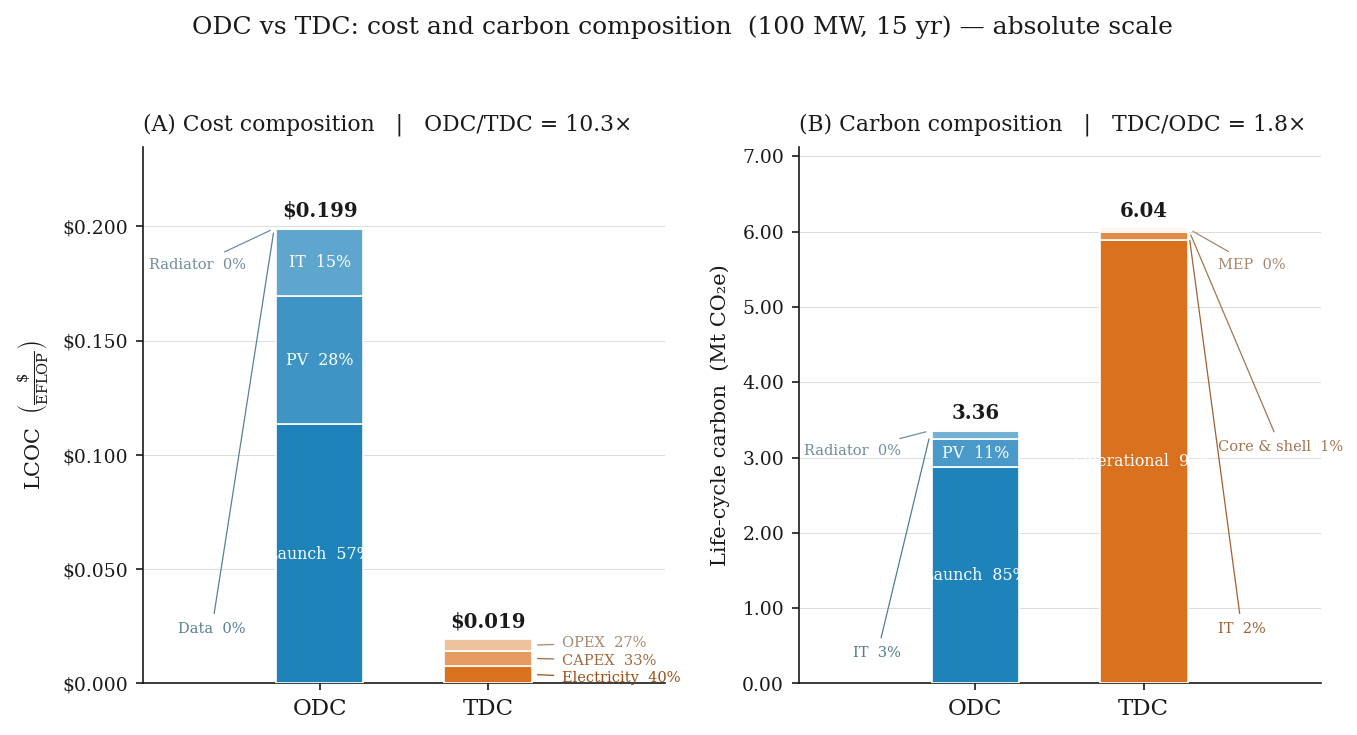

COST breakdown ($/EFLOP)
  ODC total = $0.1991
    Launch       $0.1134  ( 56.9%)
    PV           $0.0563  ( 28.3%)
    IT           $0.0292  ( 14.6%)
    Data         $0.0002  (  0.1%)
    Radiator     $0.0001  (  0.1%)
  TDC total = $0.0194
    Electricity  $0.0078  ( 40.1%)
    CAPEX        $0.0063  ( 32.6%)
    OPEX         $0.0053  ( 27.3%)
  ODC/TDC = 10.3x

CARBON breakdown (MtCO2e)
  ODC total = 3.359 Mt
    Launch           2.871 Mt  ( 85.5%)
    PV               0.378 Mt  ( 11.3%)
    IT               0.103 Mt  (  3.1%)
    Radiator         0.006 Mt  (  0.2%)
  TDC total = 6.042 Mt
    Operational      5.887 Mt  ( 97.4%)
    IT               0.103 Mt  (  1.7%)
    Core & shell     0.033 Mt  (  0.5%)
    MEP              0.020 Mt  (  0.3%)
  TDC/ODC = 1.8x


In [16]:
# =============================================================================
# Side-by-side composition: cost ($/EFLOP) and life-cycle carbon (MtCO2e)
# ABSOLUTE y-axis per panel (cost in $/EFLOP, carbon in MtCO2e -- different units,
# different axes). Each stacked bar shows the real magnitude; the % share of every
# component is printed inside its segment (or beside thin segments). ODC/TDC ratio
# annotated in the panel title.
# =============================================================================
import matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter

def _shades(base, n, lo=0.12, hi=0.62):
    rgb = np.array(mcolors.to_rgb(base))
    return [tuple(rgb * (1 - f) + f) for f in np.linspace(lo, hi, n)]

def _ink_for(rgb):
    lum = 0.299*rgb[0] + 0.587*rgb[1] + 0.114*rgb[2]
    return INK if lum > 0.6 else 'white'


# ---- Cost breakdown ($/EFLOP), financial model ------------------------------
mb_f     = mass_budget(BASELINE)
years_f  = np.arange(LIFETIME_YR)
disc_f   = 1.0 / (1 + BASELINE.discount_rate) ** years_f
npv_comp = (annual_eflop(BASELINE) * disc_f).sum()

cost_PV   = mb_f['A_PV']  * BASELINE.pv_areal_cost
cost_rad  = mb_f['A_rad'] * BASELINE.rad_areal_cost
cost_IT   = (Q_COMPUTE / 1e6) * BASELINE.it_cost_per_MW
launch0   = mb_f['Total'] * BASELINE.launch_cost_per_kg
launch_rf = mb_f['IT']    * BASELINE.launch_cost_per_kg
drop_cost = BASELINE.data_fixed_cost + BASELINE.data_mass_per_drop * BASELINE.launch_cost_per_kg

def _cf(year0, refresh=0.0):
    cf = np.zeros(LIFETIME_YR); cf[0] = year0
    for ry in (5, 10): cf[ry] += refresh
    return cf

odc_cost = {
    'Launch':   (_cf(launch0, launch_rf) * disc_f).sum() / npv_comp,
    'IT':       (_cf(cost_IT, cost_IT)   * disc_f).sum() / npv_comp,
    'PV':       (_cf(cost_PV)            * disc_f).sum() / npv_comp,
    'Radiator': (_cf(cost_rad)           * disc_f).sum() / npv_comp,
    'Data':     (np.full(LIFETIME_YR, drop_cost * BASELINE.data_drops_per_year)
                 * disc_f).sum() / npv_comp,
}

def _tdc_cost_breakdown(gamma, c=10_000, d=0.10, pue=1.12, p=150, r=0.10, n=15, k=1.0):
    annual_elec = pue * (p / 1000) * k * HOURS_PER_YEAR
    annual_opex = d * c
    annual_comp = gamma * k * SECONDS_PER_YEAR
    df = 1.0 / (1 + r) ** np.arange(n)
    npc = (annual_comp * df).sum()
    return {
        'CAPEX':       c / npc * 1000,
        'OPEX':        (annual_opex * df).sum() / npc * 1000,
        'Electricity': (annual_elec * df).sum() / npc * 1000,
    }
tdc_cost = _tdc_cost_breakdown(BASELINE.gamma_PFLOPS_per_kW)


# ---- Carbon breakdown (Mt CO2e), carbon model -------------------------------
odc_carbon_comp = {
    'Launch':   odc_carbon_result['launch_total']                  / 1e6,
    'IT':       odc_carbon_result['breakdown']['IT (all gens)']    / 1e6,
    'PV':       odc_carbon_result['breakdown']['PV array']         / 1e6,
    'Radiator': odc_carbon_result['breakdown']['Radiator']         / 1e6,
}
tdc_carbon_comp = {
    'Operational':  tdc_carbon_result['operational_total']         / 1e6,
    'IT':           tdc_carbon_result['breakdown']['IT (all gens)']/ 1e6,
    'Core & shell': tdc_carbon_result['breakdown']['Core & shell'] / 1e6,
    'MEP':          tdc_carbon_result['breakdown']['MEP']          / 1e6,
}


# ---- drawing: ABSOLUTE stacked bars, % share labelled -----------------------
def _compose_panel(ax, odc_parts, tdc_parts, ylabel, title, yfmt):
    totals = {0: sum(odc_parts.values()), 1: sum(tdc_parts.values())}
    ymax   = max(totals.values()) * 1.18
    thresh = 0.05 * ymax                       # min segment height for an inside label

    for x, (parts, base) in zip((0, 1), [(odc_parts, ODC_COLOR), (tdc_parts, TDC_COLOR)]):
        items = sorted(parts.items(), key=lambda kv: kv[1], reverse=True)
        total = totals[x]
        cols  = _shades(base, len(items))
        bottom = 0.0
        side = []                              # (y_mid, text, color) for thin segments
        for (lab, val), col in zip(items, cols):
            share = val / total
            ax.bar(x, val, bottom=bottom, width=0.52, color=col,
                   edgecolor=BG, linewidth=0.8, zorder=3)
            ymid = bottom + val / 2
            txt = f'{lab}  {share*100:.0f}%'
            if val >= thresh:
                ax.text(x, ymid, txt, ha='center', va='center', fontsize=7.6,
                        color=_ink_for(col), fontfamily=FONT, zorder=4)
            else:
                side.append((ymid, txt, tuple(np.array(mcolors.to_rgb(col)) * 0.7)))
            bottom += val
        # thin-segment labels stacked just outside the bar, with leader lines;
        # ODC (x=0) labels go LEFT, TDC (x=1) labels go RIGHT, to keep the centre clear
        if side:
            if x == 0:
                x_txt, x_arr, ha = x - 0.44, x - 0.27, 'right'
            else:
                x_txt, x_arr, ha = x + 0.44, x + 0.27, 'left'
            ys = np.linspace(total * 0.12, total * 0.92, len(side))
            for (ymid, txt, col), y_lab in zip(side, ys):
                ax.annotate(txt, xy=(x_arr, ymid), xytext=(x_txt, y_lab),
                            ha=ha, va='center', fontsize=7.0, color=col,
                            fontfamily=FONT, zorder=5,
                            arrowprops=dict(arrowstyle='-', color=col, lw=0.6))
        ax.text(x, total + ymax * 0.015, yfmt(total), ha='center', va='bottom',
                fontsize=9.5, color=INK, fontfamily=FONT, fontweight='bold', zorder=6)

    ax.set_xlim(-1.05, 2.05); ax.set_ylim(0, ymax)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['ODC', 'TDC'])
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: yfmt(v)))
    ax.set_ylabel(ylabel, fontsize=10, color=INK, fontfamily=FONT, labelpad=6)
    ax.set_facecolor(BG)
    for sdn in ('top', 'right'): ax.spines[sdn].set_visible(False)
    for sdn in ('left', 'bottom'):
        ax.spines[sdn].set_color(INK); ax.spines[sdn].set_linewidth(0.8)
    ax.grid(axis='y', color=GRID, alpha=0.7, linewidth=0.5); ax.set_axisbelow(True)
    ax.tick_params(colors=INK, labelsize=9, width=0.8)
    plt.setp(ax.get_xticklabels(), fontfamily=FONT, color=INK, fontsize=11)
    plt.setp(ax.get_yticklabels(), fontfamily=FONT, color=INK)
    ax.set_title(title, fontsize=10.5, color=INK, fontfamily=FONT, loc='left', pad=8)


cost_ratio   = sum(odc_cost.values())        / sum(tdc_cost.values())
carbon_ratio = sum(tdc_carbon_comp.values()) / sum(odc_carbon_comp.values())

fig, (axL, axR) = plt.subplots(1, 2, figsize=(9.2, 4.9))
fig.patch.set_facecolor(BG)

_compose_panel(axL, odc_cost, tdc_cost,
               ylabel=r'LCOC  $\left(\frac{\$}{\mathrm{EFLOP}}\right)$',
               title=f'(A) Cost composition   |   ODC/TDC = {cost_ratio:.1f}×',
               yfmt=lambda v: f'${v:.3f}')

_compose_panel(axR, odc_carbon_comp, tdc_carbon_comp,
               ylabel='Life-cycle carbon  (Mt CO₂e)',
               title=f'(B) Carbon composition   |   TDC/ODC = {carbon_ratio:.1f}×',
               yfmt=lambda v: f'{v:.2f}')

fig.suptitle('ODC vs TDC: cost and carbon composition  (100 MW, 15 yr) — absolute scale',
             fontsize=12, color=INK, fontfamily=FONT, y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig('cost_carbon_composition.pdf')
fig.savefig('cost_carbon_composition.png')
plt.show()


# ---- exact numbers (for the text / SI) --------------------------------------
print("COST breakdown ($/EFLOP)")
for name, parts in [('ODC', odc_cost), ('TDC', tdc_cost)]:
    tot = sum(parts.values())
    print(f"  {name} total = ${tot:.4f}")
    for k, v in sorted(parts.items(), key=lambda kv: kv[1], reverse=True):
        print(f"    {k:<12} ${v:.4f}  ({v/tot*100:5.1f}%)")
print(f"  ODC/TDC = {cost_ratio:.1f}x\n")

print("CARBON breakdown (MtCO2e)")
for name, parts in [('ODC', odc_carbon_comp), ('TDC', tdc_carbon_comp)]:
    tot = sum(parts.values())
    print(f"  {name} total = {tot:.3f} Mt")
    for k, v in sorted(parts.items(), key=lambda kv: kv[1], reverse=True):
        print(f"    {k:<14} {v:7.3f} Mt  ({v/tot*100:5.1f}%)")
print(f"  TDC/ODC = {carbon_ratio:.1f}x")


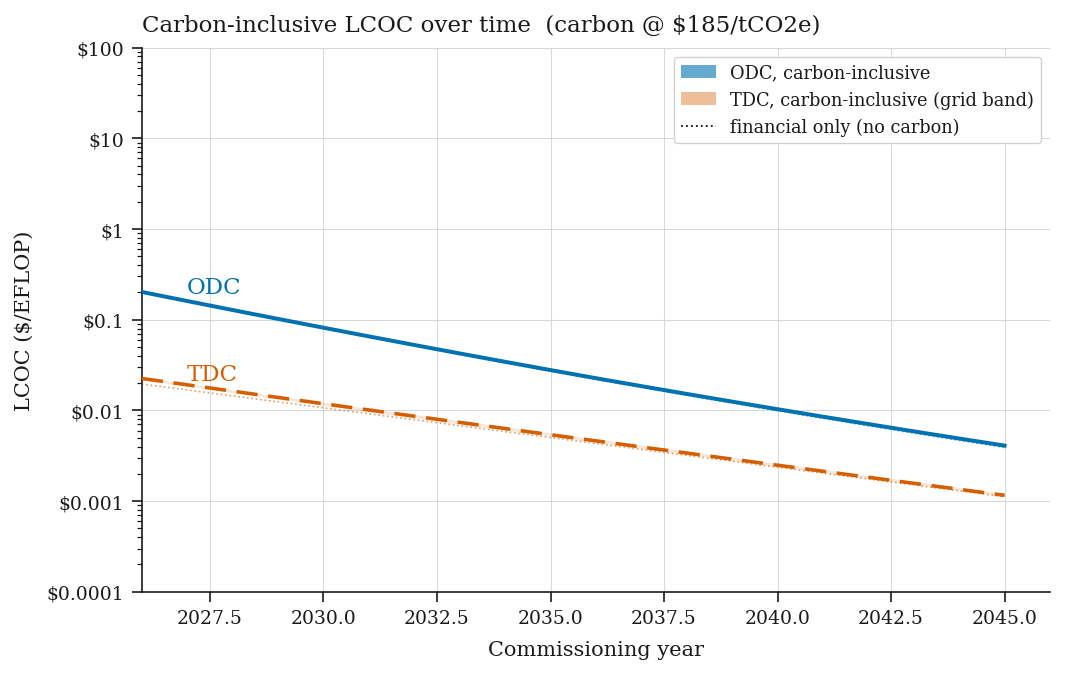

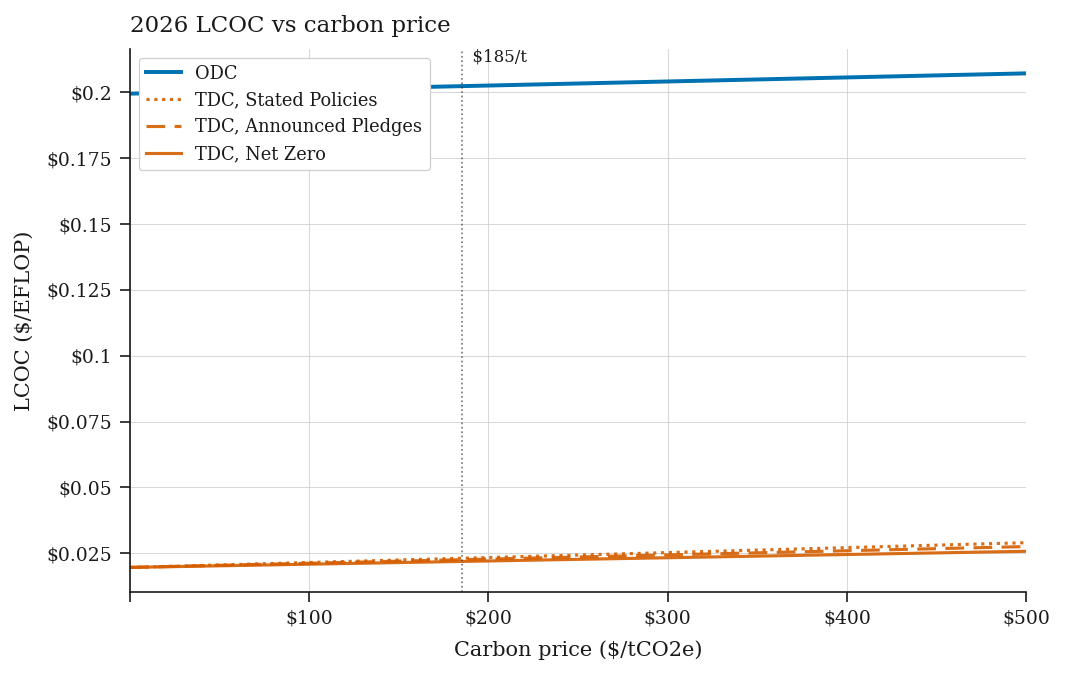

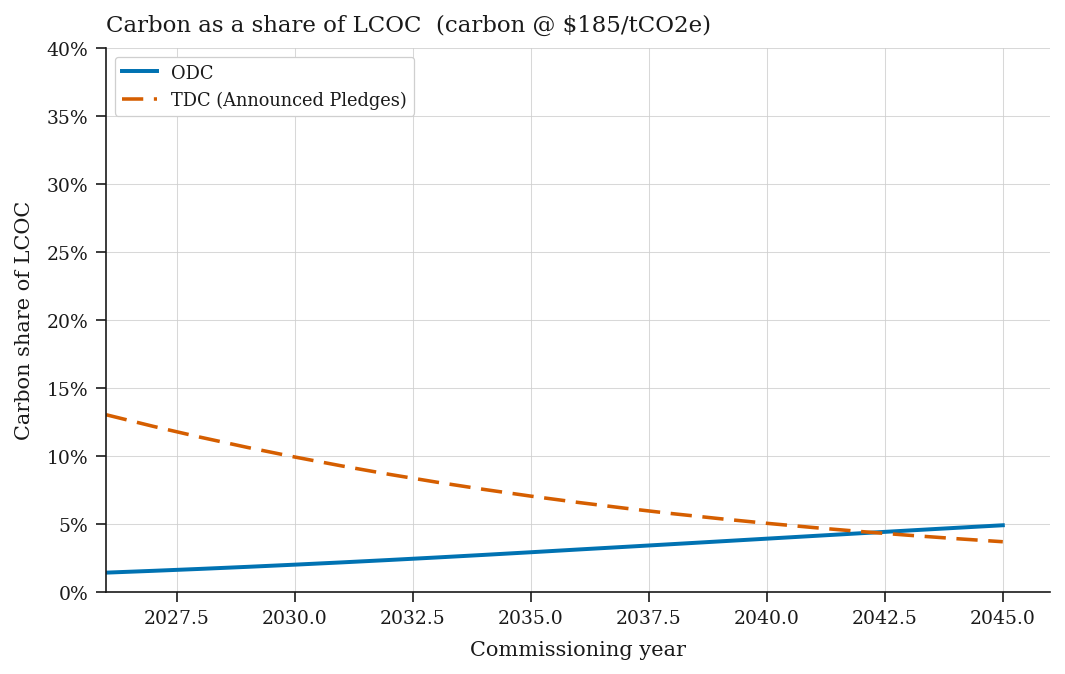

Carbon price $185/tCO2e | forcing mult 1

2026:
  ODC  fin $0.1996  +carbon $0.0028  = $0.2024  (carbon 1%)
  TDC  Stated Policies   $0.0196  +carbon $0.0035  = $0.0231  (carbon 15%)
  TDC  Announced Pledges $0.0196  +carbon $0.0029  = $0.0225  (carbon 13%)
  TDC  Net Zero          $0.0196  +carbon $0.0023  = $0.0218  (carbon 10%)

2045:
  ODC  fin $0.0039  +carbon $0.0002  = $0.0041  (carbon 5%)
  TDC  Stated Policies   $0.0011  +carbon $0.0001  = $0.0012  (carbon 8%)
  TDC  Announced Pledges $0.0011  +carbon $0.0000  = $0.0012  (carbon 4%)
  TDC  Net Zero          $0.0011  +carbon $0.0000  = $0.0011  (carbon 1%)



In [17]:
# ============================================================================
# Carbon-inclusive LCOC over time
# LCOC_total = LCOC_financial + (NPV carbon cost)/(NPV compute).
# Financial side held at BASELINE learning rates (reuses odc_nom / tdc_nom).
# New axes: grid decarbonization scenario (TDC only) and carbon price.
# ============================================================================

# ---- assumptions (edit here) ------------------------------------------------
GRID_2026          = 0.446    # tCO2e/MWh, IEA WEO 2025 global avg (446 gCO2/kWh)
BASE_CARBON_PRICE  = 185.0    # $/tCO2e (EPA 2023 social cost of carbon, central)
CARBON_PRICE_GROWTH = 0.0     # real %/yr (0 = flat real price)
ODC_FORCING_MULT   = 1.0      # >1 tests high-altitude underestimate (Dominguez 2024)

# IEA WEO 2025 scenarios as annual grid-intensity decline rates, fitted to the
# 2024->2040 endpoints in the figure. Affects TDC only (ODC is grid-independent).
GRID_SCENARIOS = {
    'Stated Policies':   0.05,   # slow decarb  (keeps TDC dirty -> favours ODC)
    'Announced Pledges': 0.09,   # central
    'Net Zero':          0.16,   # fast decarb  (hardest on ODC's relative case)
}

def carbon_price(cal_year):
    return BASE_CARBON_PRICE * (1 + CARBON_PRICE_GROWTH) ** (cal_year - START_YEAR)

# ---- shared discounting / compute -------------------------------------------
R    = BASELINE.discount_rate
disc = 1.0 / (1 + R) ** np.arange(LIFETIME_YR)

# NPV of compute (EFLOP) for a system commissioned at each offset (gamma grows)
npv_compute = np.array([
    (annual_eflop(evolve_scenario(BASELINE, yo, LR_BASELINE)) * disc).sum()
    for yo in year_offsets
])

def _price_vec(Y):
    return np.array([carbon_price(Y + i) for i in range(LIFETIME_YR)])

# ---- ODC carbon adder (grid-independent; emissions fixed over calendar time)--
_op = odc_carbon_result['profile']
odc_annual_t = (np.array(_op['embodied_spike'])
                + ODC_FORCING_MULT * np.array(_op['launch_spike']))   # tCO2e/yr

odc_carbon_adder = np.array([
    (odc_annual_t * _price_vec(START_YEAR + yo) * disc).sum() / npv_compute[k]
    for k, yo in enumerate(year_offsets)
])

# ---- TDC carbon adder (per grid scenario) -----------------------------------
def _tdc_annual(yo, decarb):
    g0 = GRID_2026 * (1 - decarb) ** yo          # grid at commissioning
    tc = tdc_carbon(replace(carbon_scenario, grid_intensity=g0, grid_decarb=decarb))
    return np.array(tc['profile']['embodied_spike']) + np.array(tc['profile']['operational'])

tdc_carbon_adder = {}
for name, decarb in GRID_SCENARIOS.items():
    tdc_carbon_adder[name] = np.array([
        (_tdc_annual(yo, decarb) * _price_vec(START_YEAR + yo) * disc).sum() / npv_compute[k]
        for k, yo in enumerate(year_offsets)
    ])

# ---- carbon-inclusive LCOC --------------------------------------------------
odc_ci = odc_nom + odc_carbon_adder
tdc_ci = {name: tdc_nom + add for name, add in tdc_carbon_adder.items()}


# ============================== FIGURE 1 =====================================
# Carbon-inclusive LCOC over time; TDC band spans grid scenarios.
fig, ax = plt.subplots(figsize=(7.2, 4.6))

ax.fill_between(years_calendar, tdc_ci['Net Zero'], tdc_ci['Stated Policies'],
                color=TDC_COLOR, alpha=0.15, zorder=2, linewidth=0)
ax.plot(years_calendar, tdc_ci['Announced Pledges'], color=TDC_COLOR,
        lw=1.7, ls=(0, (6, 3)), zorder=4)
ax.plot(years_calendar, odc_ci, color=ODC_COLOR, lw=1.9, zorder=5)

# financial-only references (no carbon)
ax.plot(years_calendar, tdc_nom, color=TDC_COLOR, lw=0.8, ls=':', alpha=0.6, zorder=3)
ax.plot(years_calendar, odc_nom, color=ODC_COLOR, lw=0.8, ls=':', alpha=0.6, zorder=3)

ax.text(2027, odc_ci[0]*1.12, 'ODC', color=ODC_COLOR, fontfamily=FONT, fontsize=11, va='center')
ax.text(2027, tdc_ci['Announced Pledges'][0]*1.12, 'TDC', color=TDC_COLOR,
        fontfamily=FONT, fontsize=11, va='center')

handles = [
    mpatches.Patch(facecolor=ODC_COLOR, alpha=0.6, label='ODC, carbon-inclusive'),
    mpatches.Patch(facecolor=TDC_COLOR, alpha=0.4, label='TDC, carbon-inclusive (grid band)'),
    plt.Line2D([0],[0], color=INK, ls=':', lw=0.9, label='financial only (no carbon)'),
]
leg = ax.legend(handles=handles, loc='upper right', frameon=True, framealpha=1.0,
                edgecolor=GRID, facecolor='white', fontsize=8.5,
                prop={'family': FONT, 'size': 8.5})
leg.get_frame().set_linewidth(0.6)
for t in leg.get_texts(): t.set_color(INK)

style_axes(ax, fig, title=f'Carbon-inclusive LCOC over time  (carbon @ ${BASE_CARBON_PRICE:.0f}/tCO2e)',
           xlabel='Commissioning year', ylabel='LCOC ($/EFLOP)',
           xlim=(2026, 2046), ylim=(0.0001, 100))
plt.tight_layout()
fig.savefig('lcoc_carbon_over_time.pdf'); fig.savefig('lcoc_carbon_over_time.png')
plt.show()


# ============================== FIGURE 2 =====================================
# 2026 snapshot: how carbon price moves LCOC (linear in price).
prices = np.linspace(0, 500, 200)
odc_coeff = (odc_annual_t * disc).sum() / npv_compute[0]
odc_sweep = odc_nom[0] + prices * odc_coeff

fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.plot(prices, odc_sweep, color=ODC_COLOR, lw=1.9, label='ODC')

tdc_styles = {'Stated Policies': (0,(1,1.5)), 'Announced Pledges': (0,(6,3)), 'Net Zero': 'solid'}
for name, decarb in GRID_SCENARIOS.items():
    coeff = (_tdc_annual(0, decarb) * disc).sum() / npv_compute[0]
    ax.plot(prices, tdc_nom[0] + prices*coeff, color=TDC_COLOR, lw=1.5,
            ls=tdc_styles[name], alpha=0.9, label=f'TDC, {name}')

ax.axvline(BASE_CARBON_PRICE, color=INK, lw=0.8, ls=':', alpha=0.6)
ax.text(BASE_CARBON_PRICE, ax.get_ylim()[1], f'  ${BASE_CARBON_PRICE:.0f}/t',
        color=INK, fontfamily=FONT, fontsize=8, va='top')

leg = ax.legend(loc='upper left', frameon=True, framealpha=1.0, edgecolor=GRID,
                facecolor='white', fontsize=8.5, prop={'family': FONT, 'size': 8.5})
leg.get_frame().set_linewidth(0.6)
for t in leg.get_texts(): t.set_color(INK)

style_axes(ax, fig, title='2026 LCOC vs carbon price',
           xlabel='Carbon price ($/tCO2e)', ylabel='LCOC ($/EFLOP)',
           y_log=False, x_dollar=True, xlim=(0, 500))
plt.tight_layout()
fig.savefig('lcoc_vs_carbon_price_2026.pdf'); fig.savefig('lcoc_vs_carbon_price_2026.png')
plt.show()


# ============================== FIGURE 3 =====================================
# Carbon as a share of total LCOC over time.
fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.plot(years_calendar, 100*odc_carbon_adder/odc_ci, color=ODC_COLOR, lw=1.9, label='ODC')
ax.plot(years_calendar, 100*tdc_carbon_adder['Announced Pledges']/tdc_ci['Announced Pledges'],
        color=TDC_COLOR, lw=1.7, ls=(0,(6,3)), label='TDC (Announced Pledges)')

leg = ax.legend(loc='upper left', frameon=True, framealpha=1.0, edgecolor=GRID,
                facecolor='white', fontsize=8.5, prop={'family': FONT, 'size': 8.5})
leg.get_frame().set_linewidth(0.6)
for t in leg.get_texts(): t.set_color(INK)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0f}%'))
style_axes(ax, fig, title=f'Carbon as a share of LCOC  (carbon @ ${BASE_CARBON_PRICE:.0f}/tCO2e)',
           xlabel='Commissioning year', ylabel='Carbon share of LCOC',
           y_log=False, y_dollar=False, xlim=(2026, 2046))
ax.set_ylim(0, max(40, 1.15*100*np.max(tdc_carbon_adder['Stated Policies']/tdc_ci['Stated Policies'])))
plt.tight_layout()
fig.savefig('carbon_share_over_time.pdf'); fig.savefig('carbon_share_over_time.png')
plt.show()


# ---- quick numeric readout --------------------------------------------------
print(f"Carbon price ${BASE_CARBON_PRICE:.0f}/tCO2e | forcing mult {ODC_FORCING_MULT:g}\n")
for label, k in [('2026', 0), ('2045', 19)]:
    print(f"{label}:")
    print(f"  ODC  fin ${odc_nom[k]:.4f}  +carbon ${odc_carbon_adder[k]:.4f}"
          f"  = ${odc_ci[k]:.4f}  (carbon {100*odc_carbon_adder[k]/odc_ci[k]:.0f}%)")
    for name in GRID_SCENARIOS:
        print(f"  TDC  {name:<17} ${tdc_nom[k]:.4f}  +carbon ${tdc_carbon_adder[name][k]:.4f}"
              f"  = ${tdc_ci[name][k]:.4f}  (carbon {100*tdc_carbon_adder[name][k]/tdc_ci[name][k]:.0f}%)")
    print()